# Desarrollo de modelos de Machine Learning  

El objetivo de esta sección es profundizar en el desarrollo de modelos de Machine Learning, incorporando técnicas avanzadas de optimización de hiperparámetros y validación estadística.  

El objetivo de esta sección es optimizar el desempeño de los modelos de aprendizaje utilizando técnicas avanzadas de búsqueda eficiente en espacios de alta dimensión, los métodos utilizados serán:

- Grid-Search

- Random Search

- Optimización Bayesiana con Optuna

- Algoritmos Géneticos con DEAP

Cada paso se le probarán 4 técnicas de balanceo de clases:  

- Sin balanceo.  

- SMOTE.  

- ADASYN.  

- class_weight=’balanced’.  

Esto para los siguientes modelos de Machine Learning: KKN estandar, KNN Ball Trees, Ridge/Lasso estandar, Ridge/Lasso solver Saga, Naive Bayes estandar, Naive Bayes partial_fit, XGBoost estandar, XGboost hist+early stopping, SVM estandar, SVM versión LinearSVC, Random Forest y Decision Tree.  

Inicialmente se realiza la importación de los paquetes utilizados para esta sección y el pre-procesamiento:

In [17]:
# Este bloque es para correr SVM en un contenedor de Linux, usando notebook lap.
import subprocess
subprocess.run([
    'pip', 'install', 
    'seaborn',
    'imbalanced-learn', 
    'optuna', 
    'deap', 
    'xgboost', 
    'openpyxl',
    'scikit-learn',
    'matplotlib',
    'scipy'
], check=True)
print("Dependencias instaladas")

Dependencias instaladas


In [2]:
#Carga de datos limpios de la sección anterior
import pandas as pd
df_limpio=pd.read_csv('df_limpio.csv')

#Importado de bibliotecas 

import warnings
warnings.filterwarnings('ignore')

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

#Bibliotecas varias
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
from scipy.stats import loguniform, uniform, randint

#Scikit-learn (incluye Grid y Random Search)
from sklearn.model_selection import cross_validate
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    classification_report, f1_score, balanced_accuracy_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb

#Optimización Bayesiana con Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

#Algoritmos Genéticos con DEAP
from deap import base, creator, tools, algorithms
import operator

#Elementos para reproducibilidad global IMPORTANTE
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Entorno configurado correctamente")
print(f"   NumPy:      {np.__version__}")
print(f"   Pandas:     {pd.__version__}")
print(f"   Scikit-learn: importado")
print(f"   XGBoost:    {xgb.__version__}")
print(f"   Optuna:     {optuna.__version__}")
print(f"   RANDOM_STATE = {RANDOM_STATE}")

Entorno configurado correctamente
   NumPy:      1.26.4
   Pandas:     2.3.3
   Scikit-learn: importado
   XGBoost:    2.1.4
   Optuna:     4.8.0
   RANDOM_STATE = 42


In [19]:
df_limpio["Estado"].value_counts()

Estado
Leve         406341
Fallecido     12682
Moderado         35
Grave             3
Name: count, dtype: int64

Observese que nuestra variable objetivo, que viene siendo la predicción del estado del paciente, hay muy pocos casos registrados de las categorías 'Moderado' y 'Grave', como se mencionó anteriormente en la prueba con regresión Lógistica, se trabajará únicamente con los estados 'Leve' y 'Fallecido', manejando Estado como una variable binaria categórica. En la siguiente celda se toma las etiquetas mencionadas, y se renombran algunas variables para facilitar su manipulación:

In [3]:
#Se toman las entradas que correspondan a alguna de las 2 categorías y se guardan en la copia que será empleada
#para trabajar el resto de la etapa
df_final = df_limpio[df_limpio["Estado"].isin(["Leve", "Fallecido"])]


#Se guarda dentro de este diccionario todos los cambios de nombre
column_rename = {
    'fecha reporte web'           : 'fecha_reporte',
    'Fecha de notificación'       : 'fecha_notificacion',
    'Código DIVIPOLA municipio'   : 'municipio_cod',
    'Edad'                        : 'edad',
    'Unidad de medida de edad'    : 'unidad_edad',
    'Sexo'                        : 'sexo',
    'Tipo de contagio'            : 'tipo_contagio',
    'Ubicación del caso'          : 'ubicacion',
    'Estado'                      : 'estado',
    'Recuperado'                  : 'recuperado',
    'Fecha de inicio de síntomas' : 'fecha_sintomas',
    'Fecha de diagnóstico'        : 'fecha_diagnostico',
    'Fecha de recuperación'       : 'fecha_recuperacion',
    'Tipo de recuperación'        : 'tipo_recuperacion',
    'Pertenencia étnica'          : 'etnia'
}

#Se realizan los renombramientos y se dimensiona inmediatamente el dataset
df_final = df_final.rename(columns=column_rename)
print(f"Dataset cargado: {df_final.shape[0]:,} filas × {df_final.shape[1]} columnas")

df_final.head()

Dataset cargado: 419,023 filas × 15 columnas


,fecha_reporte,fecha_notificacion,municipio_cod,edad,unidad_edad,sexo,tipo_contagio,ubicacion,estado,recuperado,fecha_sintomas,fecha_diagnostico,fecha_recuperacion,tipo_recuperacion,etnia
0,2021-01-13,2020-12-27,8758,75,1,M,Comunitaria,Casa,Leve,Recuperado,2020-12-25,2021-01-07,2021-01-14,Tiempo,6.0
1,2020-07-18,2020-06-30,8758,52,1,F,Comunitaria,Casa,Leve,Recuperado,2020-06-28,2020-07-11,2020-07-27,Tiempo,6.0
2,2020-09-23,2020-09-11,8758,80,1,F,Comunitaria,Casa,Leve,Recuperado,2020-09-09,2020-09-22,2020-09-28,Tiempo,6.0
3,2020-07-18,2020-07-01,8634,21,1,F,Comunitaria,Casa,Leve,Recuperado,2020-06-29,2020-07-12,2020-07-26,Pcr,6.0
4,2020-07-18,2020-06-30,8758,15,1,F,Comunitaria,Casa,Leve,Recuperado,2020-06-28,2020-07-11,2020-07-27,Pcr,6.0


Se nota que solo 38 entradas fueron eliminadas. Luego de esto se procede a establecer el pre-procesamiento completo, empezando con Feature Engineering, un proceso que consiste en transformar variables básicas o crudas en representaciones más informativas para el modelo. Para evitar data leakage temporal proveniente de información futura, se utilizarán las variables que contengan información al momento del diagnóstico:

In [ ]:
#Paso 1: Feature Engineering

#Convertir fechas utilizando pandas para facilitar la manipulación
for col in ['fecha_notificacion', 'fecha_sintomas', 'fecha_diagnostico']:
    df_final[col] = pd.to_datetime(df_final[col], errors='coerce')
    

#Se establece una nueva variable que nos diga los Días entre inicio de síntomas y diagnóstico (lag diagnóstico)
df_final['dias_hasta_diagnostico'] = (df_final['fecha_diagnostico'] - df_final['fecha_sintomas']).dt.days.clip(0, 60) #Intervalo en 60 días para datos Atípicos 


#Establecer la edad en años (la columna unidad_edad puede indicar meses o días)
def normalizar_edad(row):
    if row['unidad_edad'] == 2:   #meses
        return row['edad'] / 12
    elif row['unidad_edad'] == 3: #días
        return row['edad'] / 365
    return row['edad']

df_final['edad_años'] = df_final.apply(normalizar_edad, axis=1).clip(0, 120)

#Para mejor percepción del modelo se crea una variable que contenga Grupos de edad
bins = [0, 18, 40, 60, 75, 120]
labels_age = ['0-18', '19-40', '41-60', '61-75', '75+']
df_final['grupo_edad'] = pd.cut(df_final['edad_años'], bins=bins, labels=labels_age, right=True)

#Se guarda el mes del año para tener en cuenta estacionalidad pandémica
df_final['mes_notificacion'] = df_final['fecha_notificacion'].dt.month

#Se transformaa en str los codigos de cada municipio para aplicar OneHotEncoding
df_final['municipio_cod'] = df_final['municipio_cod'].astype(str)

#Eliminar las etnias con menor número de apariciones en el dataset
grupos_minoritarios = df_final['etnia'].value_counts()
grupos_minoritarios = grupos_minoritarios[grupos_minoritarios < 500].index

#Luego Agrupas
df_final = df_final[~df_final['etnia'].isin(grupos_minoritarios)]
df_final['etnia'] = df_final['etnia'].astype(str)
df_final = df_final.reset_index(drop=True)

print("Features construidas:")
print("dias_hasta_diagnostico, edad_años, grupo_edad, mes_notificacion")
print("")
print("Features modificadads:")
print("municipio cod, etnia")


Features construidas:
dias_hasta_diagnostico, edad_años, grupo_edad, mes_notificacion

Features modificadads:
municipio cod, etnia


Una vez construido y modificado cada componente, pasemos a seleccionar las que serán utilizadas durante el modelado. Se exlcluyen variables de fecha ya que en la sección anterior se extrajo su información de valor, se excluyen 'ubicación' y 'recuperado' ya que son variables que mencionan directamente si el paciente se recuperó o no, y por último se excluye la fecha de recuperación porque contiene información posterior al evento:

In [5]:
#PASO 2: SELECCIÓN de variables para el modelado

FEATURES_NUM = [
    'edad_años',
    'dias_hasta_diagnostico',
    'mes_notificacion'
    
]

FEATURES_CAT = [
    'sexo',
    'tipo_contagio',
    'grupo_edad',
    'etnia',
    'municipio_cod'
]

#Se codifica la variable objetivo 'estado', donde los casos leves se representan con 0, y los fatales con 1
df_final['estado_bin'] = (df_final['estado'].str.upper() == 'FALLECIDO').astype(int)
TARGET = 'estado_bin'

FEATURES_ALL = FEATURES_NUM + FEATURES_CAT

#Se crea una copia limpia que contenga unicamente la información de las variables que seleccionamos
datos = df_final[FEATURES_ALL + [TARGET]].copy()
datos = datos.dropna(subset=[TARGET])

#Se dividen para el entrenamiento
X = datos[FEATURES_ALL]
y = datos[TARGET].astype(int)

print(f"Dimensiones: {X.shape}")
datos.head()

Dimensiones: (419016, 8)


,edad_años,dias_hasta_diagnostico,mes_notificacion,sexo,tipo_contagio,grupo_edad,etnia,municipio_cod,estado_bin
0,75.0,13.0,12,M,Comunitaria,61-75,6.0,8758,0
1,52.0,13.0,6,F,Comunitaria,41-60,6.0,8758,0
2,80.0,13.0,9,F,Comunitaria,75+,6.0,8758,0
3,21.0,13.0,7,F,Comunitaria,19-40,6.0,8634,0
4,15.0,13.0,6,F,Comunitaria,0-18,6.0,8758,0


Luego de esto se procede a la codificación de variables categóricas utilizando ColumnTransformer, todo dentro del mismo objeto sklearn para garantizar que no haya fuga de datos. En el pipeline de las variables númericas se usa StandarScaler() y SimpleImputer con la mediana por si hay valores faltantes, para el pipeline de las categóricas se utiliza SimpleImputer con la moda por si hay valores NaN y OneHotEncoding para evitar multicolinealidad, además como no hay tantas categorías, no genera una alta cardinalidad.

In [6]:
#Paso 3: Pre-procesamiento con ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,  FEATURES_NUM),
        ('cat', categorical_transformer, FEATURES_CAT)
    ],
    remainder='drop'
)

print("Preprocesador definido (ColumnTransformer)")
print("Numérico:    Imputer(mediana) → StandardScaler")
print("Categórico:  Imputer(moda)   → OneHotEncoder")

Preprocesador definido (ColumnTransformer)
Numérico:    Imputer(mediana) → StandardScaler
Categórico:  Imputer(moda)   → OneHotEncoder


Antes de utilizar el modelo se debe hacer correctamente la división del grupo de entrenamiento y el grupo de prueba, debido a las clases desbalanceadas se utilizará split estratificado, garantizando que cada partición mantiene la proporción original de clases, sino se hace esto, las particiones podrían no contener representación de clases minoritarias.

In [7]:
#Paso 4: Train/Test Split estratificado

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y          #estratificado
)

print(f"Split estratificado: 80% Entrenamiento (Train) y 20% Prueba (Test)")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

#Se verifica que se mantenga la proporción:
print("\nDistribución en train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nDistribución en test:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Split estratificado: 80% Entrenamiento (Train) y 20% Prueba (Test)
Train: 335,212 | Test: 83,804

Distribución en train:
estado_bin
0    0.97
1    0.03
Name: proportion, dtype: float64

Distribución en test:
estado_bin
0    0.97
1    0.03
Name: proportion, dtype: float64


 Antes de continuar, para evitar la fuga de datos, es de vital importancia saber que no se debe mezclar la información del conjunto de prueba con el de entrenamiento, por tanto el fit() debe ser aplicado únicamente en el conjunto de entrenamiento. La solución a esto es usar pipelines el fit() del pipeline llama al fit_transform() de cada paso sólo sobre training data, y el transform() final usa los parámetros aprendidos. Por último, se debe realizar la validación cruzada, se utilizará el método StratifiedKFold debido a que en este caso se tiene clases desbalanceadas, y se define la métrica de optimización. 
 Dado el contexto del problema se escogerá recall como métrica de entrenamiento porque se desea disminuir lo mayor posible los casos de falsos negativos, es decir, personas que pueden fallecer pero se hice que tendrán estado leve. 
 

In [8]:
#Paso 5: Validación cruzada

from sklearn.metrics import fbeta_score, make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'recall' #Acá está la métrica recall para el entrenamiento
SCORING_MULTIPLE = {
    'pr_auc'  : 'average_precision',
    'roc_auc' : 'roc_auc',
    'f1'      : 'f1',
    'recall'  : 'recall',
    'precision': 'precision',
    'balanced_accuracy': 'balanced_accuracy'
}

print(f"Validación: StratifiedKFold (k=5, shuffle=True, seed={RANDOM_STATE})")
print(f"Métrica de optimización: {SCORING}")

Validación: StratifiedKFold (k=5, shuffle=True, seed=42)
Métrica de optimización: recall


Se implementa la función central optimizar_modelo(), que automatiza el entrenamiento y comparación sistemática de cualquier modelo de Machine Learning bajo cuatro métodos de balanceo de clases y cuatro estrategias de optimización de hiperparámetros.  

**Métodos de Balanceo**  
- Sin balanceo: entrenamiento con la distribución original del dataset (clases desbalanceadas).
- SMOTE: sobremuestreo sintético de la clase minoritaria (Fallecido) mediante interpolación entre vecinos cercanos.
- ADASYN: sobremuestreo adaptativo, genera más muestras sintéticas en zonas de mayor dificultad de clasificación.
- Class Weight: penalización proporcional al desbalance de clases directamente en la función de pérdida del modelo, sin modificar los datos.

**Métodos de Optimización de Hiperparámetros**  
- Grid Search: búsqueda exhaustiva sobre una cuadrícula predefinida de combinaciones de hiperparámetros.
- Random Search: muestreo aleatorio sobre distribuciones de hiperparámetros, más eficiente que Grid Search en espacios de alta dimensión.
- Optuna (TPE): optimización bayesiana con el algoritmo Tree-structured Parzen Estimator, que aprende de iteraciones anteriores para dirigir la búsqueda hacia regiones prometedoras.
- DEAP (Algoritmo Genético): metaheurística evolutiva que codifica los hiperparámetros como cromosomas y aplica operadores de selección, cruce y mutación para explorar el espacio de búsqueda.  

**Métricas Registradas**  
Para cada combinación (modelo × balanceo × método de optimización) se registran tanto en validación cruzada (CV) como en el conjunto de test:
Recall, Precision, F1, Balanced Accuracy, PR-AUC y ROC-AUC.  

La métrica principal de optimización es el Recall de la clase positiva (Fallecido), dado que en el contexto clínico de COVID-19 es prioritario minimizar los falsos negativos, es decir, no clasificar como Leve a un paciente que fallecerá.

**Estructura de Resultados**  
Los resultados se acumulan en REPO_RESULTADOS y se persisten automáticamente en resultados_ml_covid.csv tras cada modelo, permitiendo recuperar el progreso ante interrupciones. Adicionalmente, los mejores estimadores se serializan como archivos .pkl en la carpeta modelos_pkl/.

In [128]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN


# ─────────────────────────────────────────────
# PIPELINE DE OPTIMIZACIÓN CON BALANCEO
# ─────────────────────────────────────────────

BALANCEADORES = {
    'sin_balanceo': None,
    'smote'       : SMOTE(random_state=RANDOM_STATE),
    'adasyn'      : ADASYN(random_state=RANDOM_STATE),
    'weights'     : 'weights'
}


def optimizar_modelo(
    nombre_modelo,
    make_pipeline_fn,
    param_grid,
    param_dist,
    objective_fn_factory,
    gene_bounds,
    decode_fn,
    param_grid_weights = None,
    param_dist_weights = None,
    X_train_override   = None,
    y_train_override   = None,
    gene_bounds_weights= None,
    decode_fn_weights  = None,
):
    X_tr = X_train_override if X_train_override is not None else X_train
    y_tr = y_train_override if y_train_override is not None else y_train

    resultados = {'modelo': nombre_modelo}

    for metodo in [ 'grid_search', 'random_search', 'optuna', 'deap']:
        resultados[metodo] = {}

    print(f"\n{'='*60}")
    print(f"  OPTIMIZANDO: {nombre_modelo}")
    print(f"{'='*60}")

    for nombre_bal, balancer in BALANCEADORES.items():

        print(f"\n{'─'*60}")
        print(f"  BALANCEO: {nombre_bal.upper()}")
        print(f"{'─'*60}")

        pg  = param_grid_weights   if (nombre_bal == 'weights' and param_grid_weights)   else param_grid
        pd  = param_dist_weights   if (nombre_bal == 'weights' and param_dist_weights)   else param_dist
        gb  = gene_bounds_weights  if (nombre_bal == 'weights' and gene_bounds_weights)  else gene_bounds
        dfn = decode_fn_weights    if (nombre_bal == 'weights' and decode_fn_weights)    else decode_fn

        make_pipe = lambda params=None, b=balancer: make_pipeline_fn(params=params, balancer=b)


        # ── 2. GRID SEARCH ───────────────────────────────────
        print(f"\n  [2/5] Grid Search...")
        start = time.time()
        gs = GridSearchCV(
            estimator  = make_pipe(),
            param_grid = pg,
            cv         = CV,
            scoring    = SCORING_MULTIPLE,
            n_jobs     = -1,
            refit      = 'recall',
            verbose    = 0
        )
        gs.fit(X_tr, y_tr)

        cv_results = gs.cv_results_

        resultados['grid_search'][nombre_bal] = {
            'score_cv' : gs.best_score_,
            'std_cv'   : cv_results['std_test_recall'][gs.best_index_],
            'tiempo'   : time.time() - start,
            'params'   : gs.best_params_,
            'estimator': gs.best_estimator_,
            'metrics_cv': {
                'pr_auc'            : cv_results['mean_test_pr_auc'][gs.best_index_],
                'roc_auc'           : cv_results['mean_test_roc_auc'][gs.best_index_],
                'recall'            : cv_results['mean_test_recall'][gs.best_index_],
                'precision'         : cv_results['mean_test_precision'][gs.best_index_],
                'f1'                : cv_results['mean_test_f1'][gs.best_index_],
                'balanced_accuracy' : cv_results['mean_test_balanced_accuracy'][gs.best_index_],
            }
        }

        print(f"      RECALL CV: {gs.best_score_:.4f} ± {cv_results['std_test_recall'][gs.best_index_]:.4f} | {resultados['grid_search'][nombre_bal]['tiempo']:.1f}s")
        print(" | ".join([f"{k}: {v:.4f}" for k, v in resultados['grid_search'][nombre_bal]['metrics_cv'].items()]))

        # ── 3. RANDOM SEARCH ─────────────────────────────────
        print(f"\n  [3/5] Random Search...")
        start = time.time()
        rs = RandomizedSearchCV(
            estimator           = make_pipe(),
            param_distributions = pd,
            n_iter              = 20,
            cv                  = CV,
            scoring             = SCORING_MULTIPLE,
            n_jobs              = -1,
            refit               = 'recall',
            random_state        = RANDOM_STATE,
            verbose             = 0
        )
        rs.fit(X_tr, y_tr)

        cv_results = rs.cv_results_

        resultados['random_search'][nombre_bal] = {
            'score_cv' : rs.best_score_,
            'std_cv'   : cv_results['std_test_recall'][rs.best_index_],
            'tiempo'   : time.time() - start,
            'params'   : rs.best_params_,
            'estimator': rs.best_estimator_,
            'metrics_cv': {
                'pr_auc'            : cv_results['mean_test_pr_auc'][rs.best_index_],
                'roc_auc'           : cv_results['mean_test_roc_auc'][rs.best_index_],
                'recall'            : cv_results['mean_test_recall'][rs.best_index_],
                'precision'         : cv_results['mean_test_precision'][rs.best_index_],
                'f1'                : cv_results['mean_test_f1'][rs.best_index_],
                'balanced_accuracy' : cv_results['mean_test_balanced_accuracy'][rs.best_index_],
            }
        }

        print(f"      RECALL CV: {rs.best_score_:.4f} ± {cv_results['std_test_recall'][rs.best_index_]:.4f} | {resultados['random_search'][nombre_bal]['tiempo']:.1f}s")
        print(" | ".join([f"{k}: {v:.4f}" for k, v in resultados['random_search'][nombre_bal]['metrics_cv'].items()]))

        # ── 4. OPTUNA ────────────────────────────────────────
        print(f"\n  [4/5] Optuna (TPE)...")
        objective_fn = objective_fn_factory(balancer)
        start = time.time()
        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
        study   = optuna.create_study(
            direction  = 'maximize',
            sampler    = sampler,
            study_name = f'{nombre_modelo}_{nombre_bal}'
        )
        study.optimize(objective_fn, n_trials=20, show_progress_bar=False)

        best_opt_pipe = make_pipe(study.best_params)
        best_opt_pipe.fit(X_tr, y_tr)

        best_trial_metrics = study.best_trial.user_attrs

        resultados['optuna'][nombre_bal] = {
            'score_cv'  : study.best_value,
            'std_cv'    : best_trial_metrics.get('recall_std', np.nan),
            'tiempo'    : time.time() - start,
            'params'    : study.best_params,
            'estimator' : best_opt_pipe,
            'study'     : study,
            'metrics_cv': best_trial_metrics
        }

        print(f"      RECALL CV: {study.best_value:.4f} ± {resultados['optuna'][nombre_bal]['std_cv'] if not np.isnan(resultados['optuna'][nombre_bal]['std_cv']) else 'N/A'} | {resultados['optuna'][nombre_bal]['tiempo']:.1f}s")
        print(" | ".join([f"{k}: {v:.4f}" for k, v in best_trial_metrics.items()]))

        # ── 5. DEAP ──────────────────────────────────────────
        print(f"\n  [5/5] Algoritmo Genético (DEAP)...")

        POP_SIZE = 10
        N_GEN    = 5
        CXPB     = 0.7
        MUTPB    = 0.3

        for attr in ['FitnessMax', 'Individual']:
            if attr in creator.__dict__:
                delattr(creator, attr)

        creator.create('FitnessMax', base.Fitness, weights=(1.0,))
        creator.create('Individual', list, fitness=creator.FitnessMax)

        toolbox = base.Toolbox()
        toolbox.register(
            'individual',
            tools.initCycle,
            creator.Individual,
            [lambda b=b: random.uniform(*b) for b in gb],
            n=1
        )
        toolbox.register('population', tools.initRepeat, list, toolbox.individual)

        def evaluar(individual, b=balancer):
            params = dfn(individual)
            pipe   = make_pipeline_fn(params=params, balancer=b)
            try:
                scores = cross_val_score(
                    pipe, X_tr, y_tr,
                    cv=CV, scoring=SCORING, n_jobs=-1
                )
                return (scores.mean(),)
            except Exception:
                return (0.0,)

        toolbox.register('evaluate', evaluar)
        toolbox.register('mate',     tools.cxBlend, alpha=0.5)
        toolbox.register('mutate',   tools.mutGaussian,
                         mu=0,
                         sigma=[0.1 * (b[1] - b[0]) for b in gb],
                         indpb=0.3)
        toolbox.register('select',   tools.selTournament, tournsize=3)

        stats = tools.Statistics(lambda ind: ind.fitness.values)
        stats.register('max',  np.max)
        stats.register('mean', np.mean)
        stats.register('std',  np.std)
        hof = tools.HallOfFame(1)

        random.seed(RANDOM_STATE)
        np.random.seed(RANDOM_STATE)

        population = toolbox.population(n=POP_SIZE)
        ga_history = {'gen': [], 'max': [], 'mean': [], 'std': []}

        fitnesses = list(map(toolbox.evaluate, population))
        for ind, fit in zip(population, fitnesses):
            ind.fitness.values = fit
        hof.update(population)

        start = time.time()

        for gen in range(N_GEN):
            offspring = toolbox.select(population, len(population))
            offspring = list(map(toolbox.clone, offspring))

            for child1, child2 in zip(offspring[::2], offspring[1::2]):
                if random.random() < CXPB:
                    toolbox.mate(child1, child2)
                    del child1.fitness.values
                    del child2.fitness.values

            for mutant in offspring:
                if random.random() < MUTPB:
                    toolbox.mutate(mutant)
                    for i, (lo, hi) in enumerate(gb):
                        mutant[i] = np.clip(mutant[i], lo, hi)
                    del mutant.fitness.values

            invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
            fitnesses   = list(map(toolbox.evaluate, invalid_ind))
            for ind, fit in zip(invalid_ind, fitnesses):
                ind.fitness.values = fit

            population[:] = offspring
            hof.update(population)

            record = stats.compile(population)
            ga_history['gen'].append(gen + 1)
            ga_history['max'].append(record['max'])
            ga_history['mean'].append(record['mean'])
            ga_history['std'].append(record['std'])

            print(f"      Gen {gen+1:2d}/{N_GEN} | Max: {record['max']:.4f} | "
                  f"Mean: {record['mean']:.4f} ± {record['std']:.4f}")

        ga_best_params = dfn(hof[0])
        ga_best_pipe   = make_pipeline_fn(params=ga_best_params, balancer=balancer)
        ga_best_pipe.fit(X_tr, y_tr)

        ga_best_scores = cross_validate(
            make_pipeline_fn(params=ga_best_params, balancer=balancer),
            X_tr, y_tr,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )

        ga_metrics_cv = {
            k.replace('test_', ''): float(np.mean(v))
            for k, v in ga_best_scores.items()
            if k.startswith('test_')
        }

        resultados['deap'][nombre_bal] = {
            'score_cv'  : hof[0].fitness.values[0],
            'std_cv'    : float(np.std(ga_best_scores['test_recall'])),
            'tiempo'    : time.time() - start,
            'params'    : ga_best_params,
            'estimator' : ga_best_pipe,
            'history'   : ga_history,
            'metrics_cv': ga_metrics_cv
        }

        print(f"      RECALL CV: {hof[0].fitness.values[0]:.4f} ± {resultados['deap'][nombre_bal]['std_cv']:.4f} | {resultados['deap'][nombre_bal]['tiempo']:.1f}s")
        print(" | ".join([f"{k}: {v:.4f}" for k, v in ga_metrics_cv.items()]))

        # ── EVALUACIÓN EN TEST ────────────────────────────────
        print(f"\n  {'─'*40}")
        print(f"  TEST SET — {nombre_bal.upper()}")
        print(f"  {'─'*40}")


        for metodo in ['grid_search', 'random_search', 'optuna', 'deap']:
            est    = resultados[metodo][nombre_bal]['estimator']
            y_prob = est.predict_proba(X_test)[:, 1]
            y_pred = est.predict(X_test)

            report = classification_report(
                y_test, y_pred,
                target_names=['Leve', 'Fallecido'],
                output_dict=True
            )
            report['balanced_accuracy'] = balanced_accuracy_score(y_test, y_pred)

            resultados[metodo][nombre_bal]['pr_auc_test']  = average_precision_score(y_test, y_prob)
            resultados[metodo][nombre_bal]['roc_auc_test'] = roc_auc_score(y_test, y_prob)
            resultados[metodo][nombre_bal]['report']       = report

            print(f"  {metodo:<15} PR-AUC test: {resultados[metodo][nombre_bal]['pr_auc_test']:.4f} "
                  f"| Recall test: {report['Fallecido']['recall']:.4f}")

    return resultados

In [129]:
# ─────────────────────────────────────────────
# SISTEMA DE GUARDADO DE RESULTADOS
# ─────────────────────────────────────────────

REPO_RESULTADOS = {}

def guardar_resultados_modelo(resultados, repo, path='resultados_ml_covid.csv'):
    nombre_modelo = resultados.get('modelo', 'desconocido')
    METODOS = [ 'grid_search', 'random_search', 'optuna', 'deap']
    BALANCEADORES_ORDEN = ['sin_balanceo', 'smote', 'adasyn', 'weights']
    filas = []

    for metodo in METODOS:
        bloque_metodo = resultados.get(metodo, {})
        for bal in BALANCEADORES_ORDEN:
            bloque = bloque_metodo.get(bal)
            if bloque is None:
                continue

            metrics_cv = bloque.get('metrics_cv', {})
            report     = bloque.get('report', None)

            fila = {
                'modelo'   : nombre_modelo,
                'metodo'   : metodo,
                'balanceo' : bal,
                'tiempo_s' : round(bloque.get('tiempo', np.nan), 2),
                'params'   : str(bloque.get('params', {})),
                # CV
                'recall_cv'            : metrics_cv.get('recall',            np.nan),
                'recall_cv_std'        : bloque.get('std_cv',                np.nan),
                'precision_cv'         : metrics_cv.get('precision',         np.nan),
                'f1_cv'                : metrics_cv.get('f1',                np.nan),
                'balanced_accuracy_cv' : metrics_cv.get('balanced_accuracy', np.nan),
                'pr_auc_cv'            : metrics_cv.get('pr_auc',            np.nan),
                'roc_auc_cv'           : metrics_cv.get('roc_auc',           np.nan),
                # Test
                'recall_test'            : report['Fallecido']['recall']    if report else np.nan,
                'precision_test'         : report['Fallecido']['precision'] if report else np.nan,
                'f1_test'                : report['Fallecido']['f1-score']  if report else np.nan,
                'balanced_accuracy_test' : report.get('balanced_accuracy',  np.nan) if report else np.nan,
                'pr_auc_test'            : bloque.get('pr_auc_test',        np.nan),
                'roc_auc_test'           : bloque.get('roc_auc_test',       np.nan),
            }
            filas.append(fila)

    col_order = [
        'modelo', 'metodo', 'balanceo',
        'recall_cv', 'recall_cv_std', 'precision_cv', 'f1_cv',
        'balanced_accuracy_cv', 'pr_auc_cv', 'roc_auc_cv',
        'recall_test', 'precision_test', 'f1_test',
        'balanced_accuracy_test', 'pr_auc_test', 'roc_auc_test',
        'tiempo_s', 'params'
    ]

    df = pd.DataFrame(filas, columns=col_order)
    repo[nombre_modelo] = df

    # ── Guardar/actualizar CSV acumulado ──────────────────────
    from pathlib import Path
    if Path(path).exists():
        df_existente = pd.read_csv(path)
        # Eliminar filas previas de este modelo si se reentrenó
        df_existente = df_existente[df_existente['modelo'] != nombre_modelo]
        df_final_csv = pd.concat([df_existente, df], ignore_index=True)
    else:
        df_final_csv = df

    df_final_csv.to_csv(path, index=False)

    print(f"\n{'═'*60}")
    print(f"  ✓ Guardado: '{nombre_modelo}' — {len(df)} combinaciones")
    print(f"  ✓ CSV actualizado → {path}")
    print(f"{'═'*60}")
    top = (df[df['recall_cv'].notna()]
           .sort_values('recall_cv', ascending=False)
           .head(5)[['metodo', 'balanceo', 'recall_cv', 'pr_auc_cv', 'recall_test', 'pr_auc_test']])
    print("\n  TOP 5 por Recall CV:")
    print(top.to_string(index=False))
    return df


def resumen_general(repo):
    df_all  = pd.concat(repo.values(), ignore_index=True)
    idx     = df_all.groupby('modelo')['recall_cv'].idxmax()
    df_best = df_all.loc[idx, [
        'modelo', 'metodo', 'balanceo',
        'recall_cv', 'pr_auc_cv', 'roc_auc_cv',
        'recall_test', 'pr_auc_test', 'roc_auc_test'
    ]].sort_values('recall_cv', ascending=False)
    print("MEJOR combinación por modelo:")
    display(df_best)
    return df_all


def exportar_excel(repo, path='resultados_ml_covid.xlsx'):
    df_all  = pd.concat(repo.values(), ignore_index=True)
    idx     = df_all.groupby('modelo')['recall_cv'].idxmax()
    df_top  = df_all.loc[idx].sort_values('recall_cv', ascending=False)
    with pd.ExcelWriter(path, engine='openpyxl') as writer:
        df_all.to_excel(writer, sheet_name='Resumen_General', index=False)
        df_top.to_excel(writer, sheet_name='Top_Por_Modelo',  index=False)
        for nombre, df_m in repo.items():
            df_m.to_excel(writer, sheet_name=nombre[:31], index=False)
    print(f"✓ Excel exportado → {path}")

print("Sistema de guardado listo.")

Sistema de guardado listo.


In [ ]:
import pickle
import os

def guardar_mejores_pkl(resultados, repo, carpeta='modelos_pkl'):
    os.makedirs(carpeta, exist_ok=True)
    nombre_modelo = resultados.get('modelo', 'desconocido')
    
    df_modelo = repo.get(nombre_modelo)
    if df_modelo is None:
        print(f"  ✗ No se encontró '{nombre_modelo}' en el repo.")
        return

    df_valido = df_modelo[df_modelo['recall_cv'].notna()]
    if df_valido.empty:
        print(f"  ✗ No hay métricas válidas para '{nombre_modelo}'.")
        return

    mejor_fila   = df_valido.loc[df_valido['recall_cv'].idxmax()]
    mejor_metodo = mejor_fila['metodo']
    mejor_bal    = mejor_fila['balanceo']

    estimator = resultados.get(mejor_metodo, {}).get(mejor_bal, {}).get('estimator')
    if estimator is None:
        print(f"  ✗ No hay estimator para {mejor_metodo} / {mejor_bal}.")
        return

    nombre_archivo = f"{nombre_modelo}_{mejor_metodo}_{mejor_bal}.pkl"
    ruta           = os.path.join(carpeta, nombre_archivo)

    with open(ruta, 'wb') as f:
        pickle.dump(estimator, f)

    print(f"  ✓ {nombre_archivo}")
    print(f"    Mejor: {mejor_metodo} | {mejor_bal} | Recall CV: {mejor_fila['recall_cv']:.4f}")




### XGBoost hist + early stopping.  

Implementación de XGBoost usando tree_method='hist' con aceleración en GPU (device='cuda'), que construye árboles mediante histogramas de gradientes en lugar del método exacto, reduciendo significativamente el tiempo de entrenamiento en datasets grandes.  

**Hiperparámetros fijos:** colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, eval_metric='logloss'.  

**Hiperparámetros optimizados:**  

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| n_estimators | {100, 200} | Entero uniforme [50, 200] | Entero [50, 200] |
| max_depth | {3, 4, 6} | Entero uniforme [3, 6] | Entero [3, 6] |
| learning_rate | {0.05, 0.1, 0.2} | Log-uniforme [0.05, 0.20] | Log-uniforme [0.05, 0.20] |
| subsample | {0.7, 0.9} | Uniforme [0.7, 0.9] | Uniforme [0.7, 0.9] |
| scale_pos_weight* | {8, 16, 32} | Uniforme [4, scale×1.5] | Uniforme [4, scale×1.5] |

Solo para balanceo por pesos. El valor base de scale_pos_weight se calcula como la razón entre muestras de clase mayoritaria y minoritaria en el conjunto de entrenamiento.

In [11]:

#XGBOOST aqui se arma el modelo y la función objetivo de optuna

#Cálculo del peso para el balanceo por peso
n_leve      = (y_train == 0).sum()
n_fallecido = (y_train == 1).sum()  
scale_weight = n_leve / n_fallecido 

#Modelo
def make_xgb_pipeline(params=None, balancer=None):
    

    
        #Determinar scale_pos_weight según método de balanceo
    if balancer == 'weights':
        spw = scale_weight  #valor base, puede ser sobreescrito por params
    else:
        spw = 1
    
    #Hiperparametros
    default_params = dict(
        n_estimators     = 100,
        max_depth        = 4,
        learning_rate    = 0.1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        scale_pos_weight = spw,
        tree_method      = 'hist',
        device= 'cuda',
        eval_metric      = 'logloss',
        random_state     = RANDOM_STATE,
        n_jobs           = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    
    #Validación para usar el método weights
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    
    steps.append(('classifier', xgb.XGBClassifier(**default_params)))
    
    return ImbPipeline(steps=steps)


#Función para Optuna
def objective_xgb_factory(balancer):
    def objective(trial):
        params = {
            'n_estimators' : trial.suggest_int('n_estimators', 50, 200),
            'max_depth'    : trial.suggest_int('max_depth', 3, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
            'subsample'    : trial.suggest_float('subsample', 0.7, 0.9),
        }
        
        if balancer == 'weights':
            params['scale_pos_weight'] = trial.suggest_float(
            'scale_pos_weight', 4, scale_weight * 1.5
        )
        
        pipe   = make_xgb_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train, cv=CV,
            scoring=SCORING_MULTIPLE, n_jobs=-1
        )
        #Guardar todas las métricas en el trial
        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))  # ← añadir esta línea

        return np.mean(scores['test_recall'])
    return objective

In [12]:
# ══════════════════════════════════════════════
# MODELO 1 — XGBoost (ya implementado)
# ══════════════════════════════════════════════

#Acá se manipulan los rangos, estos son los rangos para grid_search
param_grid_xgb_base = {
    'classifier__n_estimators' : [100, 200],
    'classifier__max_depth'    : [3, 4, 6],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__subsample'    : [0.7, 0.9],
}

#Para los pesos en el grid (si tarda demasiado quita los demás y deja solo 8)
param_grid_xgb_weights = {
    **param_grid_xgb_base,
    'classifier__scale_pos_weight': [8, 16, 32]  # solo para weights
}

#Random Search rangos
param_dist_xgb_base = {
    'classifier__n_estimators' : randint(50, 200),
    'classifier__max_depth'    : randint(3, 6),
    'classifier__learning_rate': loguniform(0.05, 0.15),
    'classifier__subsample'    : uniform(0.7, 0.9),
}

#Rango para cuando se use el método de optimización weight
param_dist_xgb_weights = {
    **param_dist_xgb_base,
    'classifier__scale_pos_weight': uniform(4, scale_weight * 1.5 - 4)  # ← solo para weights
}

#Genes para DEAP
GENE_BOUNDS_XGB = [
    (50,   200),   #n_estimators
    (3,    6  ),   #max_depth
    (np.log(0.05), np.log(0.2)),   #log(learning_rate)
    (0.7,  0.9),   #subsample
]


def decode_individual_xgb(ind):
    #Decodifica cromosoma → dict de hiperparámetros XGBoost, función necesaria para el deap
    return {
        'n_estimators'     : max(10, int(round(ind[0]))),
        'max_depth'        : int(np.clip(round(ind[1]), 2, 8)),
        'learning_rate'    : float(np.exp(ind[2])),
        'subsample'        : float(np.clip(ind[3], 0.5, 1.0)),
    }

# Ejecutar
resultados_xgb = optimizar_modelo(
    nombre_modelo        = 'XGBoost_hist',
    make_pipeline_fn     = make_xgb_pipeline,
    param_grid           = param_grid_xgb_base,      # ← base por defecto
    param_grid_weights   = param_grid_xgb_weights,   # ← con scale_pos_weight
    param_dist           = param_dist_xgb_base,
    param_dist_weights   = param_dist_xgb_weights,
    objective_fn_factory = objective_xgb_factory,
    gene_bounds          = GENE_BOUNDS_XGB,
    decode_fn            = decode_individual_xgb
)
guardar_resultados_modelo(resultados_xgb, REPO_RESULTADOS)


  OPTIMIZANDO: XGBoost_hist

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.0383 ± 0.0057 | 6.3s
pr_auc: 0.2682 | roc_auc: 0.8934 | f1: 0.0717 | recall: 0.0383 | precision: 0.5612 | balanced_accuracy: 0.5187
  baseline        PR-AUC test: 0.2725 | Recall test: 0.0402

  [2/5] Grid Search...
      RECALL CV: 0.0678 ± 0.0065 | 108.2s
pr_auc: 0.2605 | roc_auc: 0.8900 | recall: 0.0678 | precision: 0.5084 | f1: 0.1196 | balanced_accuracy: 0.5329

  [3/5] Random Search...
      RECALL CV: 0.0514 ± 0.0064 | 27.1s
pr_auc: 0.2701 | roc_auc: 0.8939 | recall: 0.0514 | precision: 0.5485 | f1: 0.0940 | balanced_accuracy: 0.5251

  [4/5] Optuna (TPE)...
      RECALL CV: 0.0651 ± 0.005344354677680538 | 102.7s
pr_auc: 0.2638 | pr_auc_std: 0.0073 | roc_auc: 0.8915 | roc_auc_std: 0.0027 | f1: 0.1156 | f1_std: 0.0092 | recall: 0.0651 | recall_std: 0.0053 | precision: 0.52

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,XGBoost_hist,baseline,sin_balanceo,0.038340,0.005658,0.561188,0.071730,0.518707,0.268207,0.893396,0.040221,0.582857,0.075249,0.519661,0.272491,0.894822,6.29,{}
1,XGBoost_hist,baseline,smote,0.776758,0.010387,0.131247,0.224547,0.808137,0.254252,0.888450,0.777997,0.130051,0.222850,0.807798,0.254729,0.890472,8.26,{}
2,XGBoost_hist,baseline,adasyn,0.789473,0.009193,0.123491,0.213568,0.807277,0.249174,0.887115,0.795741,0.121566,0.210911,0.808155,0.247418,0.888833,18.77,{}
3,XGBoost_hist,baseline,weights,0.835500,0.007702,0.114822,0.201896,0.817229,0.267668,0.893278,0.840694,0.116356,0.204420,0.820732,0.271407,0.894628,5.38,{}
4,XGBoost_hist,grid_search,sin_balanceo,0.067810,0.006499,0.508438,0.119555,0.532881,0.260531,0.890028,0.068218,0.492877,0.119848,0.533014,0.265175,0.891904,108.23,"{'classifier__learning_rate': 0.2, 'classifier..."
5,XGBoost_hist,grid_search,smote,0.818844,0.005023,0.114550,0.200982,0.810631,0.244940,0.887489,0.821372,0.116767,0.204466,0.813748,0.247854,0.888612,150.67,"{'classifier__learning_rate': 0.05, 'classifie..."
6,XGBoost_hist,grid_search,adasyn,0.837472,0.006924,0.107528,0.190583,0.810249,0.241955,0.886610,0.841483,0.108012,0.191450,0.812316,0.241671,0.887875,239.51,"{'classifier__learning_rate': 0.05, 'classifie..."
7,XGBoost_hist,grid_search,weights,0.836092,0.005385,0.112290,0.197989,0.814890,0.261379,0.891558,0.845032,0.113941,0.200806,0.819985,0.264815,0.892688,312.39,"{'classifier__learning_rate': 0.05, 'classifie..."
8,XGBoost_hist,random_search,sin_balanceo,0.051450,0.006405,0.548513,0.094014,0.525068,0.270052,0.893903,0.056388,0.560784,0.102472,0.527505,0.276413,0.895269,27.15,{'classifier__learning_rate': 0.09651675043146...
9,XGBoost_hist,random_search,smote,0.806031,0.008233,0.120309,0.209368,0.811039,0.252813,0.889218,0.814669,0.120805,0.210408,0.814826,0.254497,0.890683,36.37,{'classifier__learning_rate': 0.05329456604111...


### KNN con KD-Tree.  

El uso de K-Nearest Neighbors (KNN) se descartó como candidato principal debido a su ineficiencia estructural ante grandes volúmenes de datos y su alta sensibilidad al ruido en dimensiones elevadas. Al ser un algoritmo basado en memoria, KNN no genera un modelo predictivo compacto, sino que requiere comparar cada nuevo paciente contra la totalidad del set de entrenamiento; con 600,000 registros, el costo computacional en términos de memoria RAM y tiempo de respuesta es prohibitivo para un entorno clínico real. Por esta razón, se optó por entrenar con un subconjunto de 100,000 observaciones, una escala que permite evaluar la capacidad del algoritmo sin comprometer la estabilidad del sistema, confirmando que la 'maldición de la dimensionalidad' y el sesgo hacia la clase mayoritaria (pacientes leves) impedían alcanzar el Recall necesario para la detección crítica de fallecimientos, especialmente comparado con modelos de ensamble más robustos.  

En pocas palabras, para este algoritmo se usará un subconjunto para hacer el entrenamiento porque se deseó simplificar con este algoritmo, dado que, KNN por la naturaleza de los datos no tendrá los mejoras mejores métricas. Además, se usará la técnica de optimización KD-Tree para este algoritmo y no las demás por lo hablado anteriormente, no tiene sentido probar con todas (Ball Tress y FAISS) porque al final el algoritmo dará métricas pobres porque solo mejoran la rapidez y no el aprendizaje.  

In [13]:

from sklearn.model_selection import StratifiedShuffleSplit

#Submuestra estratificada — ejecutar UNA vez antes del pipeline KNN
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.7, random_state=RANDOM_STATE)
idx_knn, _ = next(sss.split(X_train, y_train))

X_train_muestra = X_train.iloc[idx_knn].reset_index(drop=True)
y_train_muestra = y_train.iloc[idx_knn].reset_index(drop=True)

#Si se quiere usar la muestra usar X_train_muestra y y_train_muestra en los parametros correspondientes
print(f"Train Muestra: {X_train_muestra.shape[0]:,} registros")
print(f"Distribución: {y_train_muestra.value_counts(normalize=True).round(3).to_dict()}")

Train Muestra: 100,563 registros
Distribución: {0: 0.97, 1: 0.03}


K-Nearest Neighbors con estructura de indexación KD-Tree (algorithm='kd_tree'), que organiza los puntos en un árbol binario de particiones del espacio, reduciendo la búsqueda de vecinos de O(n) a O(log n) en espacios de baja dimensión. Por el tamaño del dataset se entrenó sobre una submuestra estratificada del 30% del conjunto de entrenamiento.   

**Hiperparámetros fijos:** leaf_size=30.   

**Hiperparámetros optimizados:**   

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| n_neighbors | {3, 5, 7, 11, 15} | Entero uniforme [3, 30] | Entero [3, 30] |
| weights | {uniform, distance} | Categórico | Binario (umbral 0.5) |
| metric | {minkowski, manhattan} | Categórico | Binario (umbral 0.5) |
| algorithm | {kd_tree, ball_tree} | Categórico | Binario (umbral 0.5) |

En DEAP, los hiperparámetros categóricos se codifican como valores continuos en [0,1] y se decodifican mediante umbrales.

In [14]:
# ══════════════════════════════════════════════
# MODELO 2 — K-NN con KD-Tree
# ══════════════════════════════════════════════

#No Hay un Método Weights para el balanceo de clases en K-NN, solo puede usarse SMOTE o ADASYN

from sklearn.neighbors import KNeighborsClassifier

#Definición del modelo KNN
def make_knn_pipeline(params=None, balancer=None):
    
    default_params = dict(
        n_neighbors = 5,
        weights     = 'uniform',
        metric      = 'minkowski',
        algorithm   = 'kd_tree',    # ← más rápido según tu análisis
        leaf_size   = 30,
        n_jobs      = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]

    #KNN no tiene class_weight → weights balancer no aplica
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))

    steps.append(('classifier', KNeighborsClassifier(**default_params)))

    return ImbPipeline(steps=steps)

#Función objetivo para optunaS
def objective_knn_factory(balancer):
    def objective(trial):
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 30),
            'weights'    : trial.suggest_categorical('weights',
                                                      ['uniform', 'distance']),
            'metric'     : trial.suggest_categorical('metric',
                                                      ['minkowski', 'manhattan']),
            'algorithm'  : trial.suggest_categorical('algorithm',
                                                      ['kd_tree', 'ball_tree']),
        }
        #KNN no tiene scale_pos_weight — ignorar balancer=='weights'
        pipe   = make_knn_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train_muestra, y_train_muestra,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )

        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))  # ← añadir esta línea

        return np.mean(scores['test_recall'])
    return objective

In [15]:
#Rangos para KNN

param_grid_knn_base = {
    'classifier__n_neighbors': [3, 5, 7, 11, 15],
    'classifier__weights'    : ['uniform', 'distance'],
    'classifier__metric'     : ['minkowski', 'manhattan'],
    'classifier__algorithm'  : ['kd_tree', 'ball_tree'],
}

#KNN no tiene equivalente a scale_pos_weight
#param_grid_weights es igual al base para evitar conflictos
param_grid_knn_weights = param_grid_knn_base

param_dist_knn_base = {
    'classifier__n_neighbors': randint(3, 30),
    'classifier__weights'    : ['uniform', 'distance'],
    'classifier__metric'     : ['minkowski', 'manhattan'],
    'classifier__algorithm'  : ['kd_tree', 'ball_tree'],
}

param_dist_knn_weights = param_dist_knn_base

GENE_BOUNDS_KNN = [
    (3,   30),   # n_neighbors (entero)
    (0,    1),   # weights: <0.5=uniform, >=0.5=distance
    (0,    1),   # metric:  <0.5=minkowski, >=0.5=manhattan
    (0,    1),   # algorithm: <0.5=kd_tree, >=0.5=ball_tree
]

def decode_individual_knn(ind):
    return {
        'n_neighbors': int(np.clip(round(ind[0]), 3, 30)),
        'weights'    : 'uniform'   if ind[1] < 0.5 else 'distance',
        'metric'     : 'minkowski' if ind[2] < 0.5 else 'manhattan',
        'algorithm'  : 'kd_tree'   if ind[3] < 0.5 else 'ball_tree',
    }
    
    



#Como se usa la muestra añades X_train_override e y_train_override al pipeline y colocas la muestra respectiva:

resultados_knn = optimizar_modelo(
    nombre_modelo        = 'KNN',
    make_pipeline_fn     = make_knn_pipeline,
    param_grid           = param_grid_knn_base,
    param_grid_weights   = param_grid_knn_weights,
    param_dist           = param_dist_knn_base,
    param_dist_weights   = param_dist_knn_weights,
    objective_fn_factory = objective_knn_factory,
    gene_bounds          = GENE_BOUNDS_KNN,
    decode_fn            = decode_individual_knn,
    X_train_override     = X_train_muestra,    #muestra
    y_train_override     = y_train_muestra     #muestra
)
guardar_resultados_modelo(resultados_knn, REPO_RESULTADOS)


  OPTIMIZANDO: KNN

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.0940 ± 0.0054 | 7.2s
pr_auc: 0.1222 | roc_auc: 0.7091 | f1: 0.1483 | recall: 0.0940 | precision: 0.3523 | balanced_accuracy: 0.5443
  baseline        PR-AUC test: 0.1207 | Recall test: 0.0911

  [2/5] Grid Search...
      RECALL CV: 0.1294 ± 0.0093 | 612.4s
pr_auc: 0.0876 | roc_auc: 0.6467 | recall: 0.1294 | precision: 0.2342 | f1: 0.1667 | balanced_accuracy: 0.5581

  [3/5] Random Search...
      RECALL CV: 0.1252 ± 0.0115 | 346.2s
pr_auc: 0.0877 | roc_auc: 0.6480 | recall: 0.1252 | precision: 0.2308 | f1: 0.1623 | balanced_accuracy: 0.5561

  [4/5] Optuna (TPE)...
      RECALL CV: 0.1288 ± 0.010225939248267256 | 324.9s
pr_auc: 0.0875 | pr_auc_std: 0.0072 | roc_auc: 0.6465 | roc_auc_std: 0.0064 | f1: 0.1659 | f1_std: 0.0129 | recall: 0.1288 | recall_std: 0.0102 | precision: 0.2330 | pre

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,KNN,baseline,sin_balanceo,0.093954,0.005408,0.352259,0.148283,0.544275,0.122245,0.709149,0.091088,0.332853,0.143034,0.542696,0.120657,0.709759,7.23,{}
1,KNN,baseline,smote,0.449731,0.024824,0.148556,0.223327,0.684612,0.111547,0.744737,0.445189,0.151666,0.226253,0.683742,0.112779,0.743685,8.81,{}
2,KNN,baseline,adasyn,0.450061,0.026049,0.145210,0.219571,0.683685,0.109981,0.745588,0.448738,0.149638,0.224435,0.684581,0.110675,0.742770,9.23,{}
3,KNN,baseline,weights,0.093954,0.005408,0.352259,0.148283,0.544275,0.122245,0.709149,0.091088,0.332853,0.143034,0.542696,0.120657,0.709759,6.82,{}
4,KNN,grid_search,sin_balanceo,0.129432,0.009278,0.234184,0.166711,0.558107,0.087642,0.646737,0.135252,0.230201,0.170392,0.560569,0.089684,0.654655,612.44,"{'classifier__algorithm': 'kd_tree', 'classifi..."
5,KNN,grid_search,smote,0.625494,0.016232,0.126106,0.209890,0.745073,0.145273,0.811088,0.622240,0.129823,0.214825,0.746045,0.147976,0.817238,911.83,"{'classifier__algorithm': 'ball_tree', 'classi..."
6,KNN,grid_search,adasyn,0.630750,0.015361,0.122371,0.204968,0.744743,0.140288,0.809249,0.621057,0.124752,0.207770,0.742543,0.140746,0.814353,803.72,"{'classifier__algorithm': 'ball_tree', 'classi..."
7,KNN,grid_search,weights,0.129432,0.009278,0.234184,0.166711,0.558107,0.087642,0.646737,0.135252,0.230201,0.170392,0.560569,0.089684,0.654655,685.58,"{'classifier__algorithm': 'kd_tree', 'classifi..."
8,KNN,random_search,sin_balanceo,0.125159,0.011485,0.230788,0.162286,0.556073,0.087704,0.648041,0.137618,0.231432,0.172601,0.561678,0.089515,0.655988,346.17,"{'classifier__algorithm': 'ball_tree', 'classi..."
9,KNN,random_search,smote,0.718796,0.018129,0.115073,0.198384,0.773112,0.167543,0.838442,0.725158,0.120008,0.205935,0.779613,0.168426,0.844807,550.46,"{'classifier__algorithm': 'kd_tree', 'classifi..."


### Ridge/Lasso con Solver Saga  

Regresión logística con el solver SAGA (Stochastic Average Gradient Augmented), que soporta tanto regularización L1 (Lasso, produce sparsity) como L2 (Ridge, penaliza magnitud de coeficientes). SAGA es especialmente eficiente en datasets grandes y permite selección automática entre ambas regularizaciones durante la optimización.  

**Hiperparámetros fijos:** max_iter=2000, solver='saga'.    

**Hiperparámetros optimizados:**  

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| C (inverso regularización) | {0.001, 0.01, 0.1, 1.0, 10.0} | Log-uniforme [0.001, 10] | Log-uniforme [0.001, 10] |
| penalty | {l1, l2} | Categórico | Binario (umbral 0.5) |
| class_weight_ratio* | {{0:1, 1:8}, {0:1, 1:16}, {0:1, 1:32}} | Linspace [4, scale×1.5] | Continuo [4, scale×1.5] |

*Solo para balanceo por pesos.

In [16]:
#RIDGE LASSO 

from sklearn.linear_model import LogisticRegression

def make_ridge_lasso_pipeline(params=None, balancer=None):

    n_leve       = (y_train == 0).sum()
    n_fallecido  = (y_train == 1).sum()
    scale_weight = n_leve / n_fallecido

    #class_weight por defecto según balanceador
    if balancer == 'weights':
        cw = {0: 1, 1: scale_weight}  #sobreescribible por params
    else:
        cw = None  #SMOTE/ADASYN ya balancean los datos

    default_params = dict(
        C            = 1.0,
        penalty      = 'l2',       # Ridge por defecto
        solver       = 'saga',     # soporta L1, L2 y ElasticNet
        class_weight = cw,
        max_iter     = 2000,       # saga necesita más iteraciones
        random_state = RANDOM_STATE,
        n_jobs       = -1
    )

    if params:
        #class_weight viene como ratio → reconstruir el dict
        if 'class_weight_ratio' in params:
            ratio = params.pop('class_weight_ratio')
            default_params['class_weight'] = {0: 1, 1: ratio}
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]

    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))

    steps.append(('classifier', LogisticRegression(**default_params)))

    return ImbPipeline(steps=steps)


#Función Objetivo OPTUNA

def objective_rl_factory(balancer):
    def objective(trial):
        params = {
            'C'      : trial.suggest_float('C', 1e-3, 10.0, log=True),
            'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        }

        if balancer == 'weights':
            params['class_weight_ratio'] = trial.suggest_float(
                'class_weight_ratio', 4, scale_weight * 1.5
            )

        pipe   = make_ridge_lasso_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )

        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))

        return np.mean(scores['test_recall'])
    return objective

In [17]:
#RANGOS PARA RIDGE LASSO

param_grid_rl_base = {
    'classifier__C'      : [0.001, 0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l1', 'l2'],
}

param_grid_rl_weights = {
    **param_grid_rl_base,
    'classifier__class_weight': [
        {0: 1, 1: 8},
        {0: 1, 1: 16},
        {0: 1, 1: 32},
    ]
}

param_dist_rl_base = {
    'classifier__C'      : loguniform(1e-3, 10),
    'classifier__penalty': ['l1', 'l2'],
}

param_dist_rl_weights = {
    **param_dist_rl_base,
    'classifier__class_weight': [
        {0: 1, 1: w} for w in np.linspace(4, scale_weight * 1.5, 20)
    ]
}

GENE_BOUNDS_RL = [
    (np.log(1e-3), np.log(10)),  # log(C)
    (0, 1),                       # penalty: <0.5=l1, >=0.5=l2
]

GENE_BOUNDS_RL_WEIGHTS = [
    (np.log(1e-3), np.log(10)),   # log(C)
    (0, 1),                        # penalty: <0.5=l1, >=0.5=l2
    (4, scale_weight * 1.5),       # class_weight_ratio
]

def decode_individual_rl(ind):
    return {
        'C'      : float(np.exp(ind[0])),
        'penalty': 'l1' if ind[1] < 0.5 else 'l2',
    }

def decode_individual_rl_weights(ind):
    return {
        'C'                  : float(np.exp(ind[0])),
        'penalty'            : 'l1' if ind[1] < 0.5 else 'l2',
        'class_weight_ratio' : float(np.clip(ind[2], 4, scale_weight * 1.5)),
    }
    
    
    
# Wrapper que selecciona decode_fn según el balanceador activo
def decode_rl_auto(ind):
    # Esta función se sobreescribe dentro del pipeline según el balanceador
    # Ver nota en ejecución
    return decode_individual_rl(ind)

resultados_rl = optimizar_modelo(
    nombre_modelo        = 'Ridge_Lasso_SAGA',
    make_pipeline_fn     = make_ridge_lasso_pipeline,
    param_grid           = param_grid_rl_base,
    param_grid_weights   = param_grid_rl_weights,
    param_dist           = param_dist_rl_base,
    param_dist_weights   = param_dist_rl_weights,
    objective_fn_factory = objective_rl_factory,
    gene_bounds          = GENE_BOUNDS_RL,           # ← para sin_balanceo, smote, adasyn
    gene_bounds_weights  = GENE_BOUNDS_RL_WEIGHTS,   # ← para weights
    decode_fn            = decode_individual_rl,
    decode_fn_weights    = decode_individual_rl_weights,
)
guardar_resultados_modelo(resultados_rl,  REPO_RESULTADOS)


  OPTIMIZANDO: Ridge_Lasso_SAGA

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.0244 ± 0.0033 | 23.8s
pr_auc: 0.2356 | roc_auc: 0.8811 | f1: 0.0466 | recall: 0.0244 | precision: 0.4923 | balanced_accuracy: 0.5118
  baseline        PR-AUC test: 0.2382 | Recall test: 0.0264

  [2/5] Grid Search...
      RECALL CV: 0.0246 ± 0.0031 | 63.0s
pr_auc: 0.2356 | roc_auc: 0.8811 | recall: 0.0246 | precision: 0.4909 | f1: 0.0469 | balanced_accuracy: 0.5119

  [3/5] Random Search...
      RECALL CV: 0.0245 ± 0.0032 | 77.2s
pr_auc: 0.2356 | roc_auc: 0.8811 | recall: 0.0245 | precision: 0.4925 | f1: 0.0467 | balanced_accuracy: 0.5119

  [4/5] Optuna (TPE)...
      RECALL CV: 0.0245 ± 0.0032332588827092596 | 273.4s
pr_auc: 0.2357 | pr_auc_std: 0.0066 | roc_auc: 0.8811 | roc_auc_std: 0.0033 | f1: 0.0467 | f1_std: 0.0060 | recall: 0.0245 | recall_std: 0.0032 | precision:

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,Ridge_Lasso_SAGA,baseline,sin_balanceo,0.024444,0.003310,0.492341,0.046561,0.511831,0.235630,0.881136,0.026420,0.511450,0.050244,0.512816,0.238250,0.882926,23.76,{}
1,Ridge_Lasso_SAGA,baseline,smote,0.818154,0.008434,0.106566,0.188569,0.802031,0.232814,0.879751,0.826104,0.107668,0.190507,0.806226,0.231539,0.881648,24.53,{}
2,Ridge_Lasso_SAGA,baseline,adasyn,0.837767,0.008070,0.100453,0.179395,0.801806,0.231874,0.879717,0.845820,0.101318,0.180959,0.805853,0.230752,0.881590,32.85,{}
3,Ridge_Lasso_SAGA,baseline,weights,0.821604,0.006913,0.107240,0.189717,0.804059,0.234316,0.881087,0.825315,0.107814,0.190715,0.806097,0.235859,0.882974,9.72,{}
4,Ridge_Lasso_SAGA,grid_search,sin_balanceo,0.024641,0.003089,0.490851,0.046914,0.511924,0.235575,0.881122,0.026420,0.511450,0.050244,0.512816,0.238194,0.882921,63.04,"{'classifier__C': 10.0, 'classifier__penalty':..."
5,Ridge_Lasso_SAGA,grid_search,smote,0.819928,0.005838,0.106735,0.188881,0.802872,0.233067,0.880780,0.826104,0.107801,0.190715,0.806374,0.234007,0.881990,60.57,"{'classifier__C': 0.001, 'classifier__penalty'..."
6,Ridge_Lasso_SAGA,grid_search,adasyn,0.840330,0.006914,0.100642,0.179756,0.802974,0.233731,0.880715,0.845820,0.101664,0.181510,0.806296,0.233104,0.882287,91.70,"{'classifier__C': 0.01, 'classifier__penalty':..."
7,Ridge_Lasso_SAGA,grid_search,weights,0.822195,0.006289,0.106183,0.188077,0.803087,0.233555,0.880811,0.828076,0.106985,0.189488,0.806191,0.234965,0.882215,84.72,"{'classifier__C': 0.001, 'classifier__class_we..."
8,Ridge_Lasso_SAGA,random_search,sin_balanceo,0.024542,0.003233,0.492460,0.046742,0.511879,0.235604,0.881128,0.026420,0.511450,0.050244,0.512816,0.238225,0.882924,77.24,"{'classifier__C': 2.1368329072358767, 'classif..."
9,Ridge_Lasso_SAGA,random_search,smote,0.819337,0.008324,0.106790,0.188952,0.802719,0.233333,0.880105,0.827681,0.107829,0.190801,0.806991,0.232142,0.881845,87.51,"{'classifier__C': 0.05342937261279776, 'classi..."


### Naive Bayes (partial_fit)  

Clasificador probabilístico basado en el teorema de Bayes con independencia condicional entre features, asumiendo distribución gaussiana para variables continuas. Se implementa con partial_fit mediante un wrapper personalizado que entrena el modelo en lotes (*mini-batches* de 10,000 registros), permitiendo procesar el dataset completo sin cargarlo íntegramente en memoria.  

El mecanismo de balanceo por pesos se implementa ajustando los **priors** de clase en lugar de class_weight, ya que GaussianNB no soporta este parámetro directamente.  

**Hiperparámetros optimizados:**

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| var_smoothing | {1e-11, 1e-9, 1e-7, 1e-5, 1e-3} | Log-uniforme [1e-11, 1e-3] | Log-uniforme [1e-11, 1e-3] |
| prior_fallecido | {0.1, 0.3, 0.5} | Lista de 20 valores [0.1, 0.9] | Continuo [0.1, 0.9] |

*Solo para balanceo por pesos. El prior de la clase Leve se calcula como 1 - prior_fallecido.


In [18]:
#NAIVE BAYES

from sklearn.naive_bayes import GaussianNB

def make_nb_pipeline(params=None, balancer=None):

    n_leve       = (y_train == 0).sum()
    n_fallecido  = (y_train == 1).sum()
    total        = n_leve + n_fallecido

    # Priors según método de balanceo
    if balancer == 'weights':
        # Priors ajustados → más peso a fallecidos
        # valor base: 50/50, optimizable
        prior_fallecido = 0.5
        prior_leve      = 0.5
    else:
        # Priors empíricos del dataset
        prior_fallecido = n_fallecido / total
        prior_leve      = n_leve / total

    default_params = dict(
        var_smoothing = 1e-9,
        priors        = [prior_leve, prior_fallecido]
    )

    if params:
        # prior_fallecido viene como float → reconstruir lista
        if 'prior_fallecido' in params:
            pf = params.pop('prior_fallecido')
            pf = float(np.clip(pf, 0.1, 0.9))
            default_params['priors'] = [1 - pf, pf]
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]

    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))

    steps.append(('classifier', GaussianNB(**default_params)))

    return ImbPipeline(steps=steps)

#FUNCION OBJETIVO PARA OPTUNA
def objective_nb_factory(balancer):
    def objective(trial):
        params = {
            'var_smoothing': trial.suggest_float(
                'var_smoothing', 1e-11, 1e-3, log=True
            ),
        }

        if balancer == 'weights':
            params['prior_fallecido'] = trial.suggest_float(
                'prior_fallecido', 0.1, 0.9
            )

        pipe   = make_nb_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )

        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))  # ← añadir esta línea

        return np.mean(scores['test_recall'])
    return objective

In [19]:
#ESPACIOS DE BUSQUEDA

param_grid_nb_base = {
    'classifier__var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
}

param_grid_nb_weights = {
    'classifier__var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    'classifier__priors'       : [
        [0.9, 0.1],
        [0.7, 0.3],
        [0.5, 0.5],
    ]
}

param_dist_nb_base = {
    'classifier__var_smoothing': loguniform(1e-11, 1e-3),
}

param_dist_nb_weights = {
    'classifier__var_smoothing': loguniform(1e-11, 1e-3),
    'classifier__priors'       : [
        [1 - p, p] for p in np.linspace(0.1, 0.9, 20)
    ]
}

GENE_BOUNDS_NB = [
    (np.log(1e-11), np.log(1e-3)),  # log(var_smoothing)
]

GENE_BOUNDS_NB_WEIGHTS = [
    (np.log(1e-11), np.log(1e-3)),  # log(var_smoothing)
    (0.1, 0.9),                      # prior_fallecido
]

def decode_individual_nb(ind):
    return {
        'var_smoothing': float(np.exp(ind[0])),
    }

def decode_individual_nb_weights(ind):
    return {
        'var_smoothing'  : float(np.exp(ind[0])),
        'prior_fallecido': float(np.clip(ind[1], 0.1, 0.9)),
    }


resultados_nb = optimizar_modelo(
    nombre_modelo        = 'Naive_Bayes',
    make_pipeline_fn     = make_nb_pipeline,
    param_grid           = param_grid_nb_base,
    param_grid_weights   = param_grid_nb_weights,
    param_dist           = param_dist_nb_base,
    param_dist_weights   = param_dist_nb_weights,
    objective_fn_factory = objective_nb_factory,
    gene_bounds          = GENE_BOUNDS_NB,
    gene_bounds_weights  = GENE_BOUNDS_NB_WEIGHTS,
    decode_fn            = decode_individual_nb,
    decode_fn_weights    = decode_individual_nb_weights,
)
guardar_resultados_modelo(resultados_nb,  REPO_RESULTADOS)


  OPTIMIZANDO: Naive_Bayes

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.5103 ± 0.0362 | 3.0s
pr_auc: 0.1369 | roc_auc: 0.8482 | f1: 0.2504 | recall: 0.5103 | precision: 0.1662 | balanced_accuracy: 0.7151
  baseline        PR-AUC test: 0.1413 | Recall test: 0.5091

  [2/5] Grid Search...
      RECALL CV: 0.5267 ± 0.0194 | 7.7s
pr_auc: 0.1493 | roc_auc: 0.8533 | recall: 0.5267 | precision: 0.1705 | f1: 0.2576 | balanced_accuracy: 0.7234

  [3/5] Random Search...
      RECALL CV: 0.5187 ± 0.0216 | 26.3s
pr_auc: 0.1432 | roc_auc: 0.8511 | recall: 0.5187 | precision: 0.1679 | f1: 0.2536 | balanced_accuracy: 0.7192

  [4/5] Optuna (TPE)...
      RECALL CV: 0.5262 ± 0.01953490611702837 | 42.9s
pr_auc: 0.1487 | pr_auc_std: 0.0078 | roc_auc: 0.8531 | roc_auc_std: 0.0058 | f1: 0.2573 | f1_std: 0.0060 | recall: 0.5262 | recall_std: 0.0195 | precision: 0.1703 | 

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,Naive_Bayes,baseline,sin_balanceo,0.510343,0.036245,0.166157,0.250382,0.715107,0.136879,0.848197,0.509069,0.174295,0.259680,0.716906,0.141278,0.854462,2.98,{}
1,Naive_Bayes,baseline,smote,0.847527,0.003463,0.068028,0.125944,0.742477,0.208771,0.819752,0.841483,0.071900,0.132481,0.751265,0.205604,0.818426,3.95,{}
2,Naive_Bayes,baseline,adasyn,0.849399,0.002824,0.069660,0.128753,0.747508,0.207418,0.820835,0.836356,0.076979,0.140982,0.761708,0.202156,0.818954,15.62,{}
3,Naive_Bayes,baseline,weights,0.727478,0.006879,0.111364,0.193153,0.773122,0.136885,0.848196,0.735016,0.115062,0.198975,0.779306,0.141252,0.854460,3.08,{}
4,Naive_Bayes,grid_search,sin_balanceo,0.526708,0.019388,0.170520,0.257573,0.723357,0.149337,0.853306,0.539432,0.175115,0.264399,0.730069,0.154481,0.860683,7.71,{'classifier__var_smoothing': 0.001}
5,Naive_Bayes,grid_search,smote,0.847527,0.003463,0.068028,0.125944,0.742477,0.208771,0.819752,0.841483,0.071900,0.132481,0.751265,0.205604,0.818426,9.97,{'classifier__var_smoothing': 1e-11}
6,Naive_Bayes,grid_search,adasyn,0.849399,0.002824,0.069660,0.128753,0.747508,0.207418,0.820835,0.836356,0.076979,0.140982,0.761708,0.202156,0.818954,30.53,{'classifier__var_smoothing': 1e-11}
7,Naive_Bayes,grid_search,weights,0.730238,0.005746,0.112644,0.195175,0.775317,0.149055,0.853300,0.741719,0.116219,0.200951,0.782855,0.154326,0.860680,20.11,"{'classifier__priors': [0.5, 0.5], 'classifier..."
8,Naive_Bayes,random_search,sin_balanceo,0.518724,0.021606,0.167887,0.253612,0.719230,0.143162,0.851068,0.527603,0.173226,0.260819,0.724512,0.147936,0.858444,26.30,{'classifier__var_smoothing': 0.00057448516363...
9,Naive_Bayes,random_search,smote,0.847527,0.003463,0.068031,0.125949,0.742485,0.208771,0.819752,0.841483,0.071900,0.132481,0.751265,0.205604,0.818426,33.10,{'classifier__var_smoothing': 9.91564456663838...


### Linear SVC   

Máquina de Vectores de Soporte lineal (LinearSVC) envuelta en CalibratedClassifierCV con calibración sigmoid (Platt scaling) para obtener probabilidades calibradas, requeridas para calcular PR-AUC y ROC-AUC. Se usa dual=False por ser más eficiente cuando el número de muestras supera al número de features, y loss='squared_hinge' como función de pérdida.  

**Hiperparámetros fijos:** loss='squared_hinge', dual=False, max_iter=2000, calibración con 3 folds internos.  

**Hiperparámetros optimizados:**  

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| C | {0.001, 0.01, 0.1, 1.0, 10.0} | Log-uniforme [0.001, 10] | Log-uniforme [0.001, 10] |
| penalty | {l1, l2} | Categórico | Binario (umbral 0.5) |
| class_weight_ratio | {{0:1,1:8}, {0:1,1:16}, {0:1,1:32}} | Linspace [4, scale×1.5] | Continuo [4, scale×1.5] |

*Solo para balanceo por pesos. Los parámetros en Grid/Random Search usan el prefijo classifier__estimator_ por la envoltura de CalibratedClassifierCV.



In [20]:
#LINEAR-SVC

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def make_svc_pipeline(params=None, balancer=None):

    n_leve       = (y_train == 0).sum()
    n_fallecido  = (y_train == 1).sum()
    scale_weight = n_leve / n_fallecido

    if balancer == 'weights':
        cw = {0: 1, 1: scale_weight}  # sobreescribible por params
    else:
        cw = None

    default_params = dict(
        C            = 1.0,
        penalty      = 'l2',
        loss         = 'squared_hinge',
        dual         = False,          # dual=False cuando n_samples > n_features
        class_weight = cw,
        max_iter     = 2000,
        random_state = RANDOM_STATE
    )

    if params:
        if 'class_weight_ratio' in params:
            ratio = params.pop('class_weight_ratio')
            default_params['class_weight'] = {0: 1, 1: ratio}
        default_params.update(params)

    # CalibratedClassifierCV añade predict_proba via calibración Platt
    svc_base    = LinearSVC(**default_params)
    svc_calibrado = CalibratedClassifierCV(
        svc_base,
        cv     = 3,        # folds internos de calibración
        method = 'sigmoid' # calibración Platt — más rápida que isotónica
    )

    steps = [('preprocessor', preprocessor)]

    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))

    steps.append(('classifier', svc_calibrado))

    return ImbPipeline(steps=steps)

#Función OBJETIVO DE OPTUNA 

def objective_svc_factory(balancer):
    def objective(trial):
        params = {
            'C'      : trial.suggest_float('C', 1e-3, 10.0, log=True),
            'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        }

        if balancer == 'weights':
            params['class_weight_ratio'] = trial.suggest_float(
                'class_weight_ratio', 4, scale_weight * 1.5
            )

        pipe   = make_svc_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )

        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))  # ← añadir esta línea

        return np.mean(scores['test_recall'])
    return objective

In [21]:
#Espacios de Búsqueda

param_grid_svc_base = {
    'classifier__estimator__C'      : [0.001, 0.01, 0.1, 1.0, 10.0],
    'classifier__estimator__penalty': ['l1', 'l2'],
    'classifier__estimator__loss'   : ['squared_hinge'],
}

param_grid_svc_weights = {
    **param_grid_svc_base,
    'classifier__estimator__class_weight': [
        {0: 1, 1: 8},
        {0: 1, 1: 16},
        {0: 1, 1: 32},
    ]
}

param_dist_svc_base = {
    'classifier__estimator__C'      : loguniform(1e-3, 10),
    'classifier__estimator__penalty': ['l1', 'l2'],
    'classifier__estimator__loss'   : ['squared_hinge'],
}

param_dist_svc_weights = {
    **param_dist_svc_base,
    'classifier__estimator__class_weight': [
        {0: 1, 1: w} for w in np.linspace(4, scale_weight * 1.5, 20)
    ]
}

GENE_BOUNDS_SVC = [
    (np.log(1e-3), np.log(10)),  # log(C)
    (0, 1),                       # penalty: <0.5=l1, >=0.5=l2
]

GENE_BOUNDS_SVC_WEIGHTS = [
    (np.log(1e-3), np.log(10)),   # log(C)
    (0, 1),                        # penalty: <0.5=l1, >=0.5=l2
    (4, scale_weight * 1.5),       # class_weight_ratio
]

def decode_individual_svc(ind):
    return {
        'C'      : float(np.exp(ind[0])),
        'penalty': 'l1' if ind[1] < 0.5 else 'l2',
    }

def decode_individual_svc_weights(ind):
    return {
        'C'                  : float(np.exp(ind[0])),
        'penalty'            : 'l1' if ind[1] < 0.5 else 'l2',
        'class_weight_ratio' : float(np.clip(ind[2], 4, scale_weight * 1.5)),
    }
    


resultados_svc = optimizar_modelo(
    nombre_modelo        = 'LinearSVC',
    make_pipeline_fn     = make_svc_pipeline,
    param_grid           = param_grid_svc_base,
    param_grid_weights   = param_grid_svc_weights,
    param_dist           = param_dist_svc_base,
    param_dist_weights   = param_dist_svc_weights,
    objective_fn_factory = objective_svc_factory,
    gene_bounds          = GENE_BOUNDS_SVC,
    gene_bounds_weights  = GENE_BOUNDS_SVC_WEIGHTS,
    decode_fn            = decode_individual_svc,
    decode_fn_weights    = decode_individual_svc_weights,
)
guardar_resultados_modelo(resultados_svc, REPO_RESULTADOS)


  OPTIMIZANDO: LinearSVC

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.0335 ± 0.0023 | 6.5s
pr_auc: 0.2312 | roc_auc: 0.8763 | f1: 0.0626 | recall: 0.0335 | precision: 0.4765 | balanced_accuracy: 0.5162
  baseline        PR-AUC test: 0.2339 | Recall test: 0.0359

  [2/5] Grid Search...
      RECALL CV: 0.0336 ± 0.0023 | 96.9s
pr_auc: 0.2312 | roc_auc: 0.8763 | recall: 0.0336 | precision: 0.4772 | f1: 0.0628 | balanced_accuracy: 0.5162

  [3/5] Random Search...
      RECALL CV: 0.0336 ± 0.0023 | 169.2s
pr_auc: 0.2312 | roc_auc: 0.8763 | recall: 0.0336 | precision: 0.4772 | f1: 0.0628 | balanced_accuracy: 0.5162

  [4/5] Optuna (TPE)...
      RECALL CV: 0.0336 ± 0.0022579355964853247 | 267.6s
pr_auc: 0.2312 | pr_auc_std: 0.0074 | roc_auc: 0.8763 | roc_auc_std: 0.0037 | f1: 0.0628 | f1_std: 0.0040 | recall: 0.0336 | recall_std: 0.0023 | precision: 0.4772

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,LinearSVC,baseline,sin_balanceo,0.033511,0.002314,0.476481,0.062607,0.516182,0.231222,0.876322,0.035883,0.476440,0.066740,0.517326,0.233929,0.877840,6.54,{}
1,LinearSVC,baseline,smote,0.809973,0.006714,0.109546,0.192989,0.802229,0.231281,0.879085,0.815852,0.110784,0.195078,0.805752,0.230296,0.881670,13.13,{}
2,LinearSVC,baseline,adasyn,0.829390,0.008139,0.102618,0.182638,0.801506,0.229706,0.879018,0.838328,0.104083,0.185176,0.806574,0.228895,0.881544,25.27,{}
3,LinearSVC,baseline,weights,0.014292,0.002736,0.550697,0.027828,0.506961,0.232816,0.880146,0.012618,0.492308,0.024606,0.506106,0.234946,0.882752,8.12,{}
4,LinearSVC,grid_search,sin_balanceo,0.033609,0.002258,0.477243,0.062786,0.516231,0.231223,0.876322,0.035883,0.476440,0.066740,0.517326,0.233892,0.877838,96.90,"{'classifier__estimator__C': 10.0, 'classifier..."
5,LinearSVC,grid_search,smote,0.809973,0.006714,0.109585,0.193049,0.802269,0.231400,0.879160,0.818612,0.110232,0.194300,0.806209,0.230413,0.881706,104.35,"{'classifier__estimator__C': 0.1, 'classifier_..."
6,LinearSVC,grid_search,adasyn,0.830178,0.008645,0.103141,0.183484,0.802430,0.230816,0.879505,0.836751,0.104465,0.185741,0.806456,0.230454,0.881812,108.58,"{'classifier__estimator__C': 0.01, 'classifier..."
7,LinearSVC,grid_search,weights,0.026809,0.002936,0.493684,0.050848,0.512977,0.232776,0.879037,0.029968,0.520548,0.056674,0.514554,0.235416,0.881357,158.50,"{'classifier__estimator__C': 0.1, 'classifier_..."
8,LinearSVC,random_search,sin_balanceo,0.033609,0.002258,0.477243,0.062786,0.516231,0.231226,0.876321,0.035883,0.476440,0.066740,0.517326,0.233909,0.877836,169.25,{'classifier__estimator__C': 2.136832907235876...
9,LinearSVC,random_search,smote,0.810368,0.007708,0.109697,0.193234,0.802542,0.232369,0.879592,0.817429,0.110654,0.194922,0.806208,0.231854,0.882004,179.37,{'classifier__estimator__C': 0.001681304270604...


Luego del proceso hecho, se guardarán los resultados para los modelos de Machine Learning más rápidos.

### KNN base  

Variante de KNN con algorithm='brute' que calcula distancias a todos los puntos del conjunto de entrenamiento sin indexación, útil como línea base para comparar contra la optimización estructural del KD-Tree. Igualmente entrenado sobre submuestra estratificada del 30%.  

**Hiperparámetros optimizados:**  

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| n_neighbors | {3, 5, 7, 11, 15} | Entero uniforme [3, 30] | Entero [3, 30] |
| weights | {uniform, distance} | Categórico | Binario (umbral 0.5) |
| metric | {minkowski, manhattan, euclidean} | Categórico | Ternario (umbrales 0.33, 0.66) |



In [24]:
# ══════════════════════════════════════════════
# MODELO — KNN Estándar (Brute Force)
# ══════════════════════════════════════════════

from sklearn.neighbors import KNeighborsClassifier

def make_knn_std_pipeline(params=None, balancer=None):
    default_params = dict(
        n_neighbors = 5,
        weights     = 'uniform',
        metric      = 'minkowski',
        algorithm   = 'brute',
        n_jobs      = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', KNeighborsClassifier(**default_params)))
    return ImbPipeline(steps=steps)

def objective_knn_std_factory(balancer):
    def objective(trial):
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 30),
            'weights'    : trial.suggest_categorical('weights', ['uniform', 'distance']),
            'metric'     : trial.suggest_categorical('metric', ['minkowski', 'manhattan', 'euclidean']),
        }
        pipe   = make_knn_std_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train_muestra, y_train_muestra,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )
        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))
        return np.mean(scores['test_recall'])
    return objective

param_grid_knn_std_base = {
    'classifier__n_neighbors': [3, 5, 7, 11, 15],
    'classifier__weights'    : ['uniform', 'distance'],
    'classifier__metric'     : ['minkowski', 'manhattan', 'euclidean'],
}
param_grid_knn_std_weights = param_grid_knn_std_base

param_dist_knn_std_base = {
    'classifier__n_neighbors': randint(3, 30),
    'classifier__weights'    : ['uniform', 'distance'],
    'classifier__metric'     : ['minkowski', 'manhattan', 'euclidean'],
}
param_dist_knn_std_weights = param_dist_knn_std_base

GENE_BOUNDS_KNN_STD = [
    (3,  30),  # n_neighbors
    (0,   1),  # weights: <0.5=uniform, >=0.5=distance
    (0,   1),  # metric:  <0.33=minkowski, <0.66=manhattan, >=0.66=euclidean
]

def decode_individual_knn_std(ind):
    if ind[2] < 0.33:
        metric = 'minkowski'
    elif ind[2] < 0.66:
        metric = 'manhattan'
    else:
        metric = 'euclidean'
    return {
        'n_neighbors': int(np.clip(round(ind[0]), 3, 30)),
        'weights'    : 'uniform' if ind[1] < 0.5 else 'distance',
        'metric'     : metric,
    }

resultados_knn_std = optimizar_modelo(
    nombre_modelo        = 'KNN_Estandar',
    make_pipeline_fn     = make_knn_std_pipeline,
    param_grid           = param_grid_knn_std_base,
    param_grid_weights   = param_grid_knn_std_weights,
    param_dist           = param_dist_knn_std_base,
    param_dist_weights   = param_dist_knn_std_weights,
    objective_fn_factory = objective_knn_std_factory,
    gene_bounds          = GENE_BOUNDS_KNN_STD,
    decode_fn            = decode_individual_knn_std,
    X_train_override     = X_train_muestra,
    y_train_override     = y_train_muestra
)
guardar_resultados_modelo(resultados_knn_std, REPO_RESULTADOS)


  OPTIMIZANDO: KNN_Estandar

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.0956 ± 0.0054 | 25.0s
pr_auc: 0.1226 | roc_auc: 0.7097 | f1: 0.1504 | recall: 0.0956 | precision: 0.3532 | balanced_accuracy: 0.5451
  baseline        PR-AUC test: 0.1217 | Recall test: 0.0919

  [2/5] Grid Search...
      RECALL CV: 0.1294 ± 0.0097 | 398.2s
pr_auc: 0.0878 | roc_auc: 0.6469 | recall: 0.1294 | precision: 0.2357 | f1: 0.1671 | balanced_accuracy: 0.5582

  [3/5] Random Search...
      RECALL CV: 0.1271 ± 0.0076 | 249.7s
pr_auc: 0.0878 | roc_auc: 0.6502 | recall: 0.1271 | precision: 0.2320 | f1: 0.1642 | balanced_accuracy: 0.5570

  [4/5] Optuna (TPE)...
      RECALL CV: 0.1271 ± 0.00762910098674537 | 350.6s
pr_auc: 0.0878 | pr_auc_std: 0.0064 | roc_auc: 0.6502 | roc_auc_std: 0.0073 | f1: 0.1642 | f1_std: 0.0101 | recall: 0.1271 | recall_std: 0.0076 | precision: 0.2

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,KNN_Estandar,baseline,sin_balanceo,0.095595,0.005391,0.353159,0.150381,0.545055,0.122579,0.709659,0.091877,0.331909,0.143916,0.543053,0.121742,0.713811,25.04,{}
1,KNN_Estandar,baseline,smote,0.449075,0.025484,0.148456,0.223131,0.684309,0.111584,0.744258,0.444795,0.151491,0.226007,0.683526,0.112801,0.743794,36.01,{}
2,KNN_Estandar,baseline,adasyn,0.450061,0.026049,0.145249,0.219614,0.683695,0.110016,0.745222,0.447555,0.149421,0.224043,0.684026,0.110672,0.742633,36.96,{}
3,KNN_Estandar,baseline,weights,0.095595,0.005391,0.353159,0.150381,0.545055,0.122579,0.709659,0.091877,0.331909,0.143916,0.543053,0.121742,0.713811,18.93,{}
4,KNN_Estandar,grid_search,sin_balanceo,0.129432,0.009670,0.235711,0.167090,0.558163,0.087823,0.646920,0.135252,0.230976,0.170604,0.560600,0.090282,0.655818,398.18,"{'classifier__metric': 'manhattan', 'classifie..."
5,KNN_Estandar,grid_search,smote,0.624837,0.017370,0.125724,0.209325,0.744580,0.145454,0.810721,0.621845,0.129730,0.214675,0.745836,0.148072,0.817156,769.53,"{'classifier__metric': 'minkowski', 'classifie..."
6,KNN_Estandar,grid_search,adasyn,0.631079,0.015428,0.122377,0.204992,0.744871,0.140236,0.809180,0.621451,0.124911,0.208012,0.742796,0.140610,0.813708,773.58,"{'classifier__metric': 'minkowski', 'classifie..."
7,KNN_Estandar,grid_search,weights,0.129432,0.009670,0.235711,0.167090,0.558163,0.087823,0.646920,0.135252,0.230976,0.170604,0.560600,0.090282,0.655818,396.52,"{'classifier__metric': 'manhattan', 'classifie..."
8,KNN_Estandar,random_search,sin_balanceo,0.127132,0.007629,0.231954,0.164238,0.556993,0.087772,0.650229,0.134464,0.231658,0.170160,0.560273,0.090888,0.658343,249.75,"{'classifier__metric': 'minkowski', 'classifie..."
9,KNN_Estandar,random_search,smote,0.691202,0.018390,0.119805,0.204210,0.766329,0.161294,0.831085,0.698344,0.123673,0.210133,0.771964,0.163317,0.836196,481.19,"{'classifier__metric': 'minkowski', 'classifie..."


### Regresión Logística Estandar   


Regresión logística con el solver L-BFGS (*Limited-memory Broyden–Fletcher–Goldfarb–Shanno*), un método cuasi-newtoniano de segundo orden que converge más rápido que los métodos de gradiente en datasets de tamaño moderado. A diferencia de SAGA, lbfgs solo soporta regularización L2, lo que simplifica el espacio de búsqueda a un único hiperparámetro continuo.

**Hiperparámetros fijos:** penalty='l2', solver='lbfgs', max_iter=1000.

**Hiperparámetros optimizados:**

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| C | {0.001, 0.01, 0.1, 1.0, 10.0} | Log-uniforme [0.001, 10] | Log-uniforme [0.001, 10] |
| class_weight_ratio* | {{0:1,1:8}, {0:1,1:16}, {0:1,1:32}} | Linspace [4, scale×1.5] | Continuo [4, scale×1.5] |

In [25]:
# ══════════════════════════════════════════════
# MODELO — Regresión Logística Estándar (lbfgs)
# ══════════════════════════════════════════════

from sklearn.linear_model import LogisticRegression

def make_rl_std_pipeline(params=None, balancer=None):
    n_leve      = (y_train == 0).sum()
    n_fallecido = (y_train == 1).sum()
    scale_weight = n_leve / n_fallecido

    if balancer == 'weights':
        cw = {0: 1, 1: scale_weight}
    else:
        cw = None

    default_params = dict(
        C            = 1.0,
        penalty      = 'l2',       # lbfgs solo soporta l2
        solver       = 'lbfgs',
        class_weight = cw,
        max_iter     = 1000,
        random_state = RANDOM_STATE,
        n_jobs       = -1
    )
    if params:
        if 'class_weight_ratio' in params:
            ratio = params.pop('class_weight_ratio')
            default_params['class_weight'] = {0: 1, 1: ratio}
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', LogisticRegression(**default_params)))
    return ImbPipeline(steps=steps)

def objective_rl_std_factory(balancer):
    def objective(trial):
        params = {
            'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        }
        if balancer == 'weights':
            params['class_weight_ratio'] = trial.suggest_float(
                'class_weight_ratio', 4, scale_weight * 1.5
            )
        pipe   = make_rl_std_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )
        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))
        return np.mean(scores['test_recall'])
    return objective

param_grid_rl_std_base = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],
}
param_grid_rl_std_weights = {
    **param_grid_rl_std_base,
    'classifier__class_weight': [{0: 1, 1: 8}, {0: 1, 1: 16}, {0: 1, 1: 32}],
}
param_dist_rl_std_base = {
    'classifier__C': loguniform(1e-3, 10),
}
param_dist_rl_std_weights = {
    **param_dist_rl_std_base,
    'classifier__class_weight': [
        {0: 1, 1: w} for w in np.linspace(4, scale_weight * 1.5, 20)
    ],
}

GENE_BOUNDS_RL_STD         = [(np.log(1e-3), np.log(10))]
GENE_BOUNDS_RL_STD_WEIGHTS = [(np.log(1e-3), np.log(10)), (4, scale_weight * 1.5)]

def decode_individual_rl_std(ind):
    return {'C': float(np.exp(ind[0]))}

def decode_individual_rl_std_weights(ind):
    return {
        'C'                 : float(np.exp(ind[0])),
        'class_weight_ratio': float(np.clip(ind[1], 4, scale_weight * 1.5)),
    }

resultados_rl_std = optimizar_modelo(
    nombre_modelo        = 'RegLog_Estandar',
    make_pipeline_fn     = make_rl_std_pipeline,
    param_grid           = param_grid_rl_std_base,
    param_grid_weights   = param_grid_rl_std_weights,
    param_dist           = param_dist_rl_std_base,
    param_dist_weights   = param_dist_rl_std_weights,
    objective_fn_factory = objective_rl_std_factory,
    gene_bounds          = GENE_BOUNDS_RL_STD,
    gene_bounds_weights  = GENE_BOUNDS_RL_STD_WEIGHTS,
    decode_fn            = decode_individual_rl_std,
    decode_fn_weights    = decode_individual_rl_std_weights,
)
guardar_resultados_modelo(resultados_rl_std, REPO_RESULTADOS)


  OPTIMIZANDO: RegLog_Estandar

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.0244 ± 0.0033 | 7.9s
pr_auc: 0.2356 | roc_auc: 0.8811 | f1: 0.0466 | recall: 0.0244 | precision: 0.4923 | balanced_accuracy: 0.5118
  baseline        PR-AUC test: 0.2382 | Recall test: 0.0264

  [2/5] Grid Search...
      RECALL CV: 0.0246 ± 0.0031 | 19.2s
pr_auc: 0.2356 | roc_auc: 0.8811 | recall: 0.0246 | precision: 0.4909 | f1: 0.0469 | balanced_accuracy: 0.5119

  [3/5] Random Search...
      RECALL CV: 0.0246 ± 0.0032 | 56.7s
pr_auc: 0.2356 | roc_auc: 0.8811 | recall: 0.0246 | precision: 0.4907 | f1: 0.0469 | balanced_accuracy: 0.5119

  [4/5] Optuna (TPE)...
      RECALL CV: 0.0246 ± 0.003166517589807619 | 85.2s
pr_auc: 0.2356 | pr_auc_std: 0.0066 | roc_auc: 0.8811 | roc_auc_std: 0.0033 | f1: 0.0469 | f1_std: 0.0059 | recall: 0.0246 | recall_std: 0.0032 | precision: 0.4

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,RegLog_Estandar,baseline,sin_balanceo,0.024444,0.003310,0.492341,0.046561,0.511831,0.235644,0.881137,0.026420,0.515385,0.050263,0.512822,0.238239,0.882925,7.87,{}
1,RegLog_Estandar,baseline,smote,0.818154,0.008434,0.106604,0.188629,0.802074,0.232802,0.879748,0.826104,0.107668,0.190507,0.806226,0.231544,0.881649,18.76,{}
2,RegLog_Estandar,baseline,adasyn,0.837767,0.008070,0.100452,0.179393,0.801804,0.231874,0.879720,0.845820,0.101284,0.180906,0.805810,0.230749,0.881589,26.12,{}
3,RegLog_Estandar,baseline,weights,0.821604,0.006913,0.107244,0.189723,0.804064,0.234323,0.881087,0.825315,0.107814,0.190715,0.806097,0.235862,0.882974,9.95,{}
4,RegLog_Estandar,grid_search,sin_balanceo,0.024641,0.003089,0.490851,0.046914,0.511924,0.235581,0.881124,0.026420,0.511450,0.050244,0.512816,0.238217,0.882923,19.15,{'classifier__C': 10.0}
5,RegLog_Estandar,grid_search,smote,0.819041,0.008655,0.106940,0.189178,0.802778,0.233906,0.880457,0.827681,0.108107,0.191235,0.807298,0.233109,0.882136,40.93,{'classifier__C': 0.01}
6,RegLog_Estandar,grid_search,adasyn,0.839936,0.007049,0.100868,0.180106,0.803122,0.234166,0.880818,0.845032,0.101810,0.181726,0.806197,0.234249,0.882508,53.53,{'classifier__C': 0.001}
7,RegLog_Estandar,grid_search,weights,0.821604,0.006913,0.107313,0.189831,0.804140,0.234308,0.881082,0.825315,0.107881,0.190819,0.806171,0.235848,0.882971,56.18,"{'classifier__C': 10.0, 'classifier__class_wei..."
8,RegLog_Estandar,random_search,sin_balanceo,0.024641,0.003167,0.490724,0.046913,0.511924,0.235583,0.881124,0.026420,0.511450,0.050244,0.512816,0.238195,0.882924,56.66,{'classifier__C': 6.351221010640703}
9,RegLog_Estandar,random_search,smote,0.818942,0.008329,0.107052,0.189351,0.802865,0.234098,0.880556,0.827287,0.108133,0.191266,0.807181,0.233334,0.882230,139.24,{'classifier__C': 0.0070689749506246055}


### Decision Tree  

Implementación de un clasificador basado en un único árbol de decisión (DecisionTreeClassifier). Este modelo construye fronteras de decisión ortogonales mediante particiones recursivas del espacio de características basadas en criterios de pureza de nodos (Gini). Es altamente propenso al sobreajuste si no se restringe su crecimiento, por lo que la optimización se enfoca en parámetros de poda estructural y restricciones de subdivisión de muestras en los nodos.  

**Hiperparámetros fijos:** criterion='gini', random_state=RANDOM_STATE.  

**Hiperparámetros optimizados:**  

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| max_depth | {3, 5, 10, 15, None} | Entero uniforme [3, 20] | Entero [3, 20] |
| min_samples_split | {2, 5, 10} | Entero uniforme [2, 20] | Entero [2, 20] |
| min_samples_leaf | {1, 2, 5} | Entero uniforme [1, 10] | Entero [1, 10] |
| class_weight_ratio | {{0:1, 1:8}, {0:1, 1:16}, {0:1, 1:32}} | Lista de 20 valores [4, scale×1.5] | Continuo [4, scale×1.5] |
  
Solo para balanceo por pesos. El valor base de scale_weight se calcula automáticamente como la razón entre muestras de la clase mayoritaria y minoritaria en el conjunto de entrenamiento. En DEAP, los hiperparámetros numéricos se decodifican mediante funciones de redondeo (round) y truncamiento (np.clip).


In [26]:
# ══════════════════════════════════════════════
# MODELO — Decision Tree
# ══════════════════════════════════════════════

from sklearn.tree import DecisionTreeClassifier

def make_dt_pipeline(params=None, balancer=None):
    n_leve      = (y_train == 0).sum()
    n_fallecido = (y_train == 1).sum()
    scale_weight = n_leve / n_fallecido

    if balancer == 'weights':
        cw = {0: 1, 1: scale_weight}
    else:
        cw = None

    default_params = dict(
        max_depth        = None,
        min_samples_split= 2,
        min_samples_leaf = 1,
        class_weight     = cw,
        random_state     = RANDOM_STATE
    )
    if params:
        if 'class_weight_ratio' in params:
            ratio = params.pop('class_weight_ratio')
            default_params['class_weight'] = {0: 1, 1: ratio}
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', DecisionTreeClassifier(**default_params)))
    return ImbPipeline(steps=steps)

def objective_dt_factory(balancer):
    def objective(trial):
        params = {
            'max_depth'        : trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        }
        if balancer == 'weights':
            params['class_weight_ratio'] = trial.suggest_float(
                'class_weight_ratio', 4, scale_weight * 1.5
            )
        pipe   = make_dt_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )
        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))
        return np.mean(scores['test_recall'])
    return objective

param_grid_dt_base = {
    'classifier__max_depth'        : [3, 5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf' : [1, 2, 5],
}
param_grid_dt_weights = {
    **param_grid_dt_base,
    'classifier__class_weight': [{0: 1, 1: 8}, {0: 1, 1: 16}, {0: 1, 1: 32}],
}
param_dist_dt_base = {
    'classifier__max_depth'        : randint(3, 20),
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf' : randint(1, 10),
}
param_dist_dt_weights = {
    **param_dist_dt_base,
    'classifier__class_weight': [
        {0: 1, 1: w} for w in np.linspace(4, scale_weight * 1.5, 20)
    ],
}

GENE_BOUNDS_DT = [
    (3,  20),  # max_depth
    (2,  20),  # min_samples_split
    (1,  10),  # min_samples_leaf
]
GENE_BOUNDS_DT_WEIGHTS = [
    (3,  20),
    (2,  20),
    (1,  10),
    (4, scale_weight * 1.5),  # class_weight_ratio
]

def decode_individual_dt(ind):
    return {
        'max_depth'        : int(np.clip(round(ind[0]), 3, 20)),
        'min_samples_split': int(np.clip(round(ind[1]), 2, 20)),
        'min_samples_leaf' : int(np.clip(round(ind[2]), 1, 10)),
    }

def decode_individual_dt_weights(ind):
    return {
        **decode_individual_dt(ind),
        'class_weight_ratio': float(np.clip(ind[3], 4, scale_weight * 1.5)),
    }

resultados_dt = optimizar_modelo(
    nombre_modelo        = 'Decision_Tree',
    make_pipeline_fn     = make_dt_pipeline,
    param_grid           = param_grid_dt_base,
    param_grid_weights   = param_grid_dt_weights,
    param_dist           = param_dist_dt_base,
    param_dist_weights   = param_dist_dt_weights,
    objective_fn_factory = objective_dt_factory,
    gene_bounds          = GENE_BOUNDS_DT,
    gene_bounds_weights  = GENE_BOUNDS_DT_WEIGHTS,
    decode_fn            = decode_individual_dt,
    decode_fn_weights    = decode_individual_dt_weights,
)
guardar_resultados_modelo(resultados_dt, REPO_RESULTADOS)


  OPTIMIZANDO: Decision_Tree

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.1481 ± 0.0023 | 5.1s
pr_auc: 0.0862 | roc_auc: 0.6311 | f1: 0.1779 | recall: 0.1481 | precision: 0.2228 | balanced_accuracy: 0.5660
  baseline        PR-AUC test: 0.0950 | Recall test: 0.1538

  [2/5] Grid Search...
      RECALL CV: 0.1481 ± 0.0023 | 61.3s
pr_auc: 0.0862 | roc_auc: 0.6311 | recall: 0.1481 | precision: 0.2228 | f1: 0.1779 | balanced_accuracy: 0.5660

  [3/5] Random Search...
      RECALL CV: 0.0967 ± 0.0059 | 28.0s
pr_auc: 0.1638 | roc_auc: 0.7332 | recall: 0.0967 | precision: 0.3515 | f1: 0.1515 | balanced_accuracy: 0.5455

  [4/5] Optuna (TPE)...
      RECALL CV: 0.0953 ± 0.005909056698266142 | 48.8s
pr_auc: 0.1633 | pr_auc_std: 0.0050 | roc_auc: 0.7349 | roc_auc_std: 0.0078 | f1: 0.1487 | f1_std: 0.0085 | recall: 0.0953 | recall_std: 0.0059 | precision: 0.340

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,Decision_Tree,baseline,sin_balanceo,0.148137,0.002301,0.222789,0.177937,0.565998,0.086213,0.631120,0.153785,0.240148,0.187500,0.569301,0.095049,0.643278,5.14,{}
1,Decision_Tree,baseline,smote,0.201952,0.004910,0.163125,0.180418,0.584790,0.083407,0.632009,0.205047,0.155456,0.176841,0.585143,0.083690,0.632976,10.00,{}
2,Decision_Tree,baseline,adasyn,0.204415,0.005326,0.159841,0.179358,0.585431,0.083029,0.630476,0.206230,0.148537,0.172693,0.584670,0.079654,0.627083,17.96,{}
3,Decision_Tree,baseline,weights,0.317860,0.007803,0.099379,0.151417,0.613975,0.080519,0.618130,0.336356,0.100188,0.154389,0.621044,0.085619,0.623968,4.18,{}
4,Decision_Tree,grid_search,sin_balanceo,0.148137,0.002301,0.222789,0.177937,0.565998,0.086213,0.631120,0.153785,0.240148,0.187500,0.569301,0.095049,0.643278,61.30,"{'classifier__max_depth': None, 'classifier__m..."
5,Decision_Tree,grid_search,smote,0.835895,0.010622,0.098836,0.176750,0.798893,0.160432,0.865757,0.843060,0.096838,0.173722,0.798849,0.163244,0.866817,102.24,"{'classifier__max_depth': 3, 'classifier__min_..."
6,Decision_Tree,grid_search,adasyn,0.850779,0.006582,0.094313,0.169796,0.797840,0.159121,0.864843,0.852524,0.093812,0.169025,0.797773,0.162756,0.866287,240.64,"{'classifier__max_depth': 3, 'classifier__min_..."
7,Decision_Tree,grid_search,weights,0.834020,0.026831,0.102517,0.182467,0.802547,0.193378,0.877047,0.820584,0.109821,0.193717,0.806512,0.198191,0.877030,176.64,"{'classifier__class_weight': {0: 1, 1: 32}, 'c..."
8,Decision_Tree,random_search,sin_balanceo,0.096688,0.005853,0.351477,0.151521,0.545542,0.163810,0.733238,0.095426,0.339888,0.149015,0.544821,0.169436,0.741885,28.04,"{'classifier__max_depth': 19, 'classifier__min..."
9,Decision_Tree,random_search,smote,0.807610,0.015596,0.110298,0.194017,0.801864,0.189989,0.874317,0.804416,0.110924,0.194963,0.801609,0.190448,0.871299,47.54,"{'classifier__max_depth': 6, 'classifier__min_..."


### Random Forest   

Algoritmo de aprendizaje ensamble de tipo Bagging (RandomForestClassifier) que entrena una colección de árboles de decisión independientes sobre submuestras aleatorias del dataset (muestreo con reemplazo) y combina sus predicciones mediante promedios probabilísticos. Introduce aleatoriedad estructural al seleccionar un subconjunto aleatorio de características en cada división de nodo, reduciendo drásticamente la varianza y el sobreajuste en comparación con un árbol único.

**Hiperparámetros fijos:** random_state=RANDOM_STATE, n_jobs=-1.

**Hiperparámetros optimizados:**

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| n_estimators | {100, 200} | Entero uniforme [50, 300] | Entero [50, 300] |
| max_depth | {5, 10, None} | Entero uniforme [3, 20] | Entero [3, 20] |
| min_samples_split | {2, 5} | Entero uniforme [2, 20] | Entero [2, 20] |
| min_samples_leaf | *Fijo en 1 por malla* | Entero uniforme [1, 10] | Entero [1, 10] |
| max_features | {sqrt, log2} | Categórico | Binario (umbral 0.5) |
| class_weight_ratio | {{0:1, 1:8}, {0:1, 1:16}, {0:1, 1:32}} | Lista de 20 valores [4, scale×1.5] | Continuo [4, scale×1.5] |

Solo para balanceo por pesos. El comportamiento de DEAP para el hiperparámetro categórico (max_features) utiliza una codificación continua donde un valor del gen menor a 0.5 se decodifica como sqrt y mayor o igual a 0.5 se decodifica como log2.

In [27]:
# ══════════════════════════════════════════════
# MODELO — Random Forest
# ══════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier

def make_rf_pipeline(params=None, balancer=None):
    n_leve      = (y_train == 0).sum()
    n_fallecido = (y_train == 1).sum()
    scale_weight = n_leve / n_fallecido

    if balancer == 'weights':
        cw = {0: 1, 1: scale_weight}
    else:
        cw = None

    default_params = dict(
        n_estimators     = 100,
        max_depth        = None,
        min_samples_split= 2,
        min_samples_leaf = 1,
        max_features     = 'sqrt',
        class_weight     = cw,
        random_state     = RANDOM_STATE,
        n_jobs           = -1
    )
    if params:
        if 'class_weight_ratio' in params:
            ratio = params.pop('class_weight_ratio')
            default_params['class_weight'] = {0: 1, 1: ratio}
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', RandomForestClassifier(**default_params)))
    return ImbPipeline(steps=steps)

def objective_rf_factory(balancer):
    def objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 50, 300),
            'max_depth'        : trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        }
        if balancer == 'weights':
            params['class_weight_ratio'] = trial.suggest_float(
                'class_weight_ratio', 4, scale_weight * 1.5
            )
        pipe   = make_rf_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )
        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))
        return np.mean(scores['test_recall'])
    return objective

param_grid_rf_base = {
    'classifier__n_estimators'     : [100, 200],
    'classifier__max_depth'        : [5, 10, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__max_features'     : ['sqrt', 'log2'],
}
param_grid_rf_weights = {
    **param_grid_rf_base,
    'classifier__class_weight': [{0: 1, 1: 8}, {0: 1, 1: 16}, {0: 1, 1: 32}],
}
param_dist_rf_base = {
    'classifier__n_estimators'     : randint(50, 300),
    'classifier__max_depth'        : randint(3, 20),
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf' : randint(1, 10),
    'classifier__max_features'     : ['sqrt', 'log2'],
}
param_dist_rf_weights = {
    **param_dist_rf_base,
    'classifier__class_weight': [
        {0: 1, 1: w} for w in np.linspace(4, scale_weight * 1.5, 20)
    ],
}

GENE_BOUNDS_RF = [
    (50,  300),  # n_estimators
    (3,    20),  # max_depth
    (2,    20),  # min_samples_split
    (1,    10),  # min_samples_leaf
    (0,     1),  # max_features: <0.5=sqrt, >=0.5=log2
]
GENE_BOUNDS_RF_WEIGHTS = [*GENE_BOUNDS_RF, (4, scale_weight * 1.5)]

def decode_individual_rf(ind):
    return {
        'n_estimators'     : int(np.clip(round(ind[0]), 50, 300)),
        'max_depth'        : int(np.clip(round(ind[1]), 3, 20)),
        'min_samples_split': int(np.clip(round(ind[2]), 2, 20)),
        'min_samples_leaf' : int(np.clip(round(ind[3]), 1, 10)),
        'max_features'     : 'sqrt' if ind[4] < 0.5 else 'log2',
    }

def decode_individual_rf_weights(ind):
    return {
        **decode_individual_rf(ind),
        'class_weight_ratio': float(np.clip(ind[5], 4, scale_weight * 1.5)),
    }

resultados_rf = optimizar_modelo(
    nombre_modelo        = 'Random_Forest',
    make_pipeline_fn     = make_rf_pipeline,
    param_grid           = param_grid_rf_base,
    param_grid_weights   = param_grid_rf_weights,
    param_dist           = param_dist_rf_base,
    param_dist_weights   = param_dist_rf_weights,
    objective_fn_factory = objective_rf_factory,
    gene_bounds          = GENE_BOUNDS_RF,
    gene_bounds_weights  = GENE_BOUNDS_RF_WEIGHTS,
    decode_fn            = decode_individual_rf,
    decode_fn_weights    = decode_individual_rf_weights,
)
guardar_resultados_modelo(resultados_rf, REPO_RESULTADOS)


  OPTIMIZANDO: Random_Forest

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.1083 ± 0.0033 | 20.7s
pr_auc: 0.1641 | roc_auc: 0.8003 | f1: 0.1578 | recall: 0.1083 | precision: 0.2911 | balanced_accuracy: 0.5500
  baseline        PR-AUC test: 0.1654 | Recall test: 0.1104

  [2/5] Grid Search...
      RECALL CV: 0.1083 ± 0.0033 | 304.3s
pr_auc: 0.1641 | roc_auc: 0.8003 | recall: 0.1083 | precision: 0.2911 | f1: 0.1578 | balanced_accuracy: 0.5500

  [3/5] Random Search...
      RECALL CV: 0.0265 ± 0.0043 | 220.5s
pr_auc: 0.2509 | roc_auc: 0.8867 | recall: 0.0265 | precision: 0.5613 | f1: 0.0506 | balanced_accuracy: 0.5129

  [4/5] Optuna (TPE)...
      RECALL CV: 0.0248 ± 0.0037224003730155 | 282.5s
pr_auc: 0.2544 | pr_auc_std: 0.0055 | roc_auc: 0.8872 | roc_auc_std: 0.0036 | f1: 0.0475 | f1_std: 0.0069 | recall: 0.0248 | recall_std: 0.0037 | precision: 0.5

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,Random_Forest,baseline,sin_balanceo,0.108319,0.003294,0.291123,0.157841,0.550039,0.164137,0.800319,0.110410,0.302050,0.161710,0.551224,0.165436,0.805051,20.75,{}
1,Random_Forest,baseline,smote,0.243051,0.003949,0.189113,0.212691,0.605257,0.145604,0.806098,0.256309,0.175249,0.208167,0.609334,0.142001,0.807324,49.05,{}
2,Random_Forest,baseline,adasyn,0.245219,0.004934,0.182074,0.208929,0.605407,0.142448,0.803807,0.260647,0.172001,0.207243,0.610746,0.139050,0.806632,55.28,{}
3,Random_Forest,baseline,weights,0.242954,0.004901,0.118979,0.159730,0.593398,0.107189,0.776371,0.275631,0.120268,0.167465,0.606358,0.105750,0.780525,14.21,{}
4,Random_Forest,grid_search,sin_balanceo,0.108319,0.003294,0.291123,0.157841,0.550039,0.164140,0.800319,0.110410,0.302050,0.161710,0.551224,0.165436,0.805051,304.27,"{'classifier__max_depth': None, 'classifier__m..."
5,Random_Forest,grid_search,smote,0.823576,0.003244,0.106060,0.187912,0.803416,0.231349,0.875980,0.836356,0.103671,0.184475,0.805354,0.229909,0.879022,899.55,"{'classifier__max_depth': 5, 'classifier__max_..."
6,Random_Forest,grid_search,adasyn,0.849497,0.004034,0.098972,0.177288,0.804036,0.231157,0.876406,0.846609,0.099256,0.177680,0.803429,0.230606,0.879830,899.11,"{'classifier__max_depth': 5, 'classifier__max_..."
7,Random_Forest,grid_search,weights,0.806918,0.006378,0.116994,0.204356,0.808412,0.241460,0.884671,0.815063,0.117912,0.206020,0.812396,0.244046,0.887180,860.09,"{'classifier__class_weight': {0: 1, 1: 32}, 'c..."
8,Random_Forest,random_search,sin_balanceo,0.026513,0.004269,0.561297,0.050610,0.512935,0.250915,0.886710,0.024448,0.534483,0.046757,0.511892,0.257898,0.889373,220.47,"{'classifier__max_depth': 17, 'classifier__max..."
9,Random_Forest,random_search,smote,0.833727,0.004860,0.100941,0.180073,0.800941,0.226642,0.872941,0.843849,0.100493,0.179598,0.804073,0.222704,0.877204,611.95,"{'classifier__max_depth': 3, 'classifier__max_..."


### XGBoost estandar  

Implementación del clasificador XGBoost utilizando el método de construcción de árboles exacto (tree_method='exact'). A diferencia de la variante basada en histogramas, este enfoque evalúa de manera exhaustiva todos los puntos de división posibles para cada característica continua. Si bien garantiza una precisión matemática estricta al calcular las divisiones óptimas del gradiente, presenta una mayor carga computacional en comparación con los métodos basados en aproximaciones de bins.   

**Hiperparámetros fijos:** colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, tree_method='exact', eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1.  

**Hiperparámetros optimizados:**  

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| n_estimators | {100, 200} | Entero uniforme [50, 200] | Entero [50, 200] |
| max_depth | {3, 4, 6} | Entero uniforme [3, 6] | Entero [3, 6] |
| learning_rate | {0.05, 0.1, 0.2} | Log-uniforme [0.05, 0.15] | Log-uniforme [0.05, 0.20] |
| subsample | {0.7, 0.9} | Uniforme [0.7, 1.6] | Uniforme [0.7, 0.9] |
| scale_pos_weight* | {8, 16, 32} | Uniforme [4, scale×1.5] | Uniforme [4, scale×1.5] |

Solo para balanceo por pesos. El valor base de scale_pos_weight se calcula como la razón entre muestras de la clase mayoritaria y minoritaria en el conjunto de entrenamiento. En DEAP, el hiperparámetro de tasa de aprendizaje se decodifica en un espacio logarítmico exponencial, mientras que las restricciones del espacio de búsqueda se controlan mediante truncamiento con límites lógicos adaptativos en los decodificadores.

In [29]:
# ══════════════════════════════════════════════
# MODELO — XGBoost Estándar
# ══════════════════════════════════════════════

def make_xgb_std_pipeline(params=None, balancer=None):
    if balancer == 'weights':
        spw = scale_weight
    else:
        spw = 1

    default_params = dict(
        n_estimators     = 100,
        max_depth        = 4,
        learning_rate    = 0.1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        scale_pos_weight = spw,
        tree_method      = 'exact',   # ← estándar, sin hist
        eval_metric      = 'logloss',
        random_state     = RANDOM_STATE,
        n_jobs           = -1
    )
    if params:
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', xgb.XGBClassifier(**default_params)))
    return ImbPipeline(steps=steps)

def objective_xgb_std_factory(balancer):
    def objective(trial):
        params = {
            'n_estimators' : trial.suggest_int('n_estimators', 50, 200),
            'max_depth'    : trial.suggest_int('max_depth', 3, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
            'subsample'    : trial.suggest_float('subsample', 0.7, 0.9),
        }
        if balancer == 'weights':
            params['scale_pos_weight'] = trial.suggest_float(
                'scale_pos_weight', 4, scale_weight * 1.5
            )
        pipe   = make_xgb_std_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )
        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))
        return np.mean(scores['test_recall'])
    return objective

param_grid_xgb_std_base = {
    'classifier__n_estimators' : [100, 200],
    'classifier__max_depth'    : [3, 4, 6],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__subsample'    : [0.7, 0.9],
}
param_grid_xgb_std_weights = {
    **param_grid_xgb_std_base,
    'classifier__scale_pos_weight': [8, 16, 32],
}
param_dist_xgb_std_base = {
    'classifier__n_estimators' : randint(50, 200),
    'classifier__max_depth'    : randint(3, 6),
    'classifier__learning_rate': loguniform(0.05, 0.15),
    'classifier__subsample'    : uniform(0.7, 0.9),
}
param_dist_xgb_std_weights = {
    **param_dist_xgb_std_base,
    'classifier__scale_pos_weight': uniform(4, scale_weight * 1.5 - 4),
}

GENE_BOUNDS_XGB_STD = [
    (50,  200),
    (3,     6),
    (np.log(0.05), np.log(0.2)),
    (0.7,   0.9),
]
GENE_BOUNDS_XGB_STD_WEIGHTS = [*GENE_BOUNDS_XGB_STD, (4, scale_weight * 1.5)]

def decode_individual_xgb_std(ind):
    return {
        'n_estimators' : max(10, int(round(ind[0]))),
        'max_depth'    : int(np.clip(round(ind[1]), 2, 8)),
        'learning_rate': float(np.exp(ind[2])),
        'subsample'    : float(np.clip(ind[3], 0.5, 1.0)),
    }

def decode_individual_xgb_std_weights(ind):
    return {
        **decode_individual_xgb_std(ind),
        'scale_pos_weight': float(np.clip(ind[4], 4, scale_weight * 1.5)),
    }

resultados_xgb_std = optimizar_modelo(
    nombre_modelo        = 'XGBoost_Estandar',
    make_pipeline_fn     = make_xgb_std_pipeline,
    param_grid           = param_grid_xgb_std_base,
    param_grid_weights   = param_grid_xgb_std_weights,
    param_dist           = param_dist_xgb_std_base,
    param_dist_weights   = param_dist_xgb_std_weights,
    objective_fn_factory = objective_xgb_std_factory,
    gene_bounds          = GENE_BOUNDS_XGB_STD,
    gene_bounds_weights  = GENE_BOUNDS_XGB_STD_WEIGHTS,
    decode_fn            = decode_individual_xgb_std,
    decode_fn_weights    = decode_individual_xgb_std_weights,
)
guardar_resultados_modelo(resultados_xgb_std, REPO_RESULTADOS)


  OPTIMIZANDO: XGBoost_Estandar

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [1/5] Baseline...
RECALL CV: 0.0378 ± 0.0041 | 20.1s
pr_auc: 0.2685 | roc_auc: 0.8935 | f1: 0.0710 | recall: 0.0378 | precision: 0.5709 | balanced_accuracy: 0.5185
  baseline        PR-AUC test: 0.2722 | Recall test: 0.0430

  [2/5] Grid Search...
      RECALL CV: 0.0663 ± 0.0058 | 432.0s
pr_auc: 0.2588 | roc_auc: 0.8900 | recall: 0.0663 | precision: 0.5022 | f1: 0.1171 | balanced_accuracy: 0.5321

  [3/5] Random Search...
      RECALL CV: 0.0508 ± 0.0062 | 66.4s
pr_auc: 0.2710 | roc_auc: 0.8940 | recall: 0.0508 | precision: 0.5617 | f1: 0.0931 | balanced_accuracy: 0.5248

  [4/5] Optuna (TPE)...
      RECALL CV: 0.0635 ± 0.007419643297515179 | 531.0s
pr_auc: 0.2629 | pr_auc_std: 0.0088 | roc_auc: 0.8912 | roc_auc_std: 0.0030 | f1: 0.1132 | f1_std: 0.0124 | recall: 0.0635 | recall_std: 0.0074 | precision:

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,XGBoost_Estandar,baseline,sin_balanceo,0.037848,0.004105,0.570860,0.070971,0.518482,0.268469,0.893460,0.042981,0.602210,0.080236,0.521048,0.272203,0.895092,20.12,{}
1,XGBoost_Estandar,baseline,smote,0.745613,0.010366,0.139659,0.235246,0.801110,0.249406,0.887659,0.755915,0.137301,0.232392,0.803851,0.251704,0.890236,38.56,{}
2,XGBoost_Estandar,baseline,adasyn,0.764537,0.010157,0.132091,0.225258,0.803872,0.242714,0.886851,0.775631,0.127133,0.218458,0.804726,0.246976,0.889042,57.03,{}
3,XGBoost_Estandar,baseline,weights,0.833924,0.006140,0.114696,0.201655,0.816502,0.266814,0.893266,0.841483,0.116593,0.204808,0.821262,0.270582,0.895141,19.92,{}
4,XGBoost_Estandar,grid_search,sin_balanceo,0.066332,0.005809,0.502166,0.117121,0.532140,0.258787,0.889950,0.070189,0.505682,0.123269,0.534024,0.267170,0.892270,431.97,"{'classifier__learning_rate': 0.2, 'classifier..."
5,XGBoost_Estandar,grid_search,smote,0.815985,0.007133,0.116279,0.203551,0.811209,0.244816,0.887224,0.826104,0.116221,0.203774,0.815037,0.248681,0.888153,889.27,"{'classifier__learning_rate': 0.05, 'classifie..."
6,XGBoost_Estandar,grid_search,adasyn,0.831164,0.007936,0.110066,0.194390,0.810703,0.240220,0.886701,0.839511,0.110157,0.194758,0.813945,0.242120,0.887200,1011.96,"{'classifier__learning_rate': 0.05, 'classifie..."
7,XGBoost_Estandar,grid_search,weights,0.836979,0.007006,0.113068,0.199221,0.816026,0.265797,0.892924,0.847397,0.114315,0.201453,0.821260,0.267276,0.893965,1265.50,"{'classifier__learning_rate': 0.05, 'classifie..."
8,XGBoost_Estandar,random_search,sin_balanceo,0.050760,0.006185,0.561702,0.093062,0.524766,0.271009,0.893976,0.052050,0.552301,0.095135,0.525367,0.277175,0.895495,66.40,{'classifier__learning_rate': 0.09651675043146...
9,XGBoost_Estandar,random_search,smote,0.801004,0.006956,0.122463,0.212445,0.810925,0.251536,0.888712,0.806782,0.121280,0.210863,0.812187,0.254613,0.890169,130.57,{'classifier__learning_rate': 0.05329456604111...


In [141]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
import time
import random
import numpy as np

# ──────────────────────────────────────────────────────────────────────
# 1. CONFIGURACIÓN DE BALANCEADORES ESPECÍFICOS (Evitamos colisiones)
# ──────────────────────────────────────────────────────────────────────
BALANCEADORES_SVM = {
    'sin_balanceo': None,
    'smote'       : SMOTE(random_state=RANDOM_STATE, k_neighbors=1), 
    'adasyn'      : ADASYN(random_state=RANDOM_STATE, n_neighbors=1),
    'weights'     : 'weights'
}

# ──────────────────────────────────────────────────────────────────────
# 2. FUNCIÓN DE OPTIMIZACIÓN EXCLUSIVA PARA SVM / GPU
# ──────────────────────────────────────────────────────────────────────
def optimizar_modelo_svm(
    nombre_modelo,
    make_pipeline_fn,
    param_grid,
    param_dist,
    objective_fn_factory,
    gene_bounds,
    decode_fn,
    dict_balanceadores,             # <-- Pasado explícitamente para evitar fallos de scope
    param_grid_weights = None,
    param_dist_weights = None,
    X_train_override   = None,
    y_train_override   = None,
    gene_bounds_weights= None,
    decode_fn_weights  = None,
):
    # Forzamos el uso de los datos preprocesados con PCA pasados por override
    X_tr = X_train_override if X_train_override is not None else X_train
    y_tr = y_train_override if y_train_override is not None else y_train

    resultados = {'modelo': nombre_modelo}

    for metodo in ['grid_search', 'random_search', 'optuna', 'deap']:
        resultados[metodo] = {}

    print(f"\n{'='*60}")
    print(f"  OPTIMIZANDO: {nombre_modelo}")
    print(f"{'='*60}")

    # Iteramos directamente sobre el diccionario seguro inyectado a la función
    for nombre_bal, balancer in dict_balanceadores.items():

        print(f"\n{'─'*60}")
        print(f"  BALANCEO: {nombre_bal.upper()}")
        print(f"{'─'*60}")

        pg  = param_grid_weights   if (nombre_bal == 'weights' and param_grid_weights)   else param_grid
        pd  = param_dist_weights   if (nombre_bal == 'weights' and param_dist_weights)   else param_dist
        gb  = gene_bounds_weights  if (nombre_bal == 'weights' and gene_bounds_weights)  else gene_bounds
        dfn = decode_fn_weights    if (nombre_bal == 'weights' and decode_fn_weights)    else decode_fn

        make_pipe = lambda params=None, b=balancer: make_pipeline_fn(params=params, balancer=b)

        # ── [2/5] GRID SEARCH ───────────────────────────────────
        print(f"\n  [2/5] Grid Search...")
        start = time.time()
        gs = GridSearchCV(
            estimator  = make_pipe(),
            param_grid = pg,
            cv         = CV,
            scoring    = SCORING_MULTIPLE,
            n_jobs     = 1,
            refit      = 'recall',
            verbose    = 0
        )
        gs.fit(X_tr, y_tr)

        cv_results = gs.cv_results_

        resultados['grid_search'][nombre_bal] = {
            'score_cv' : gs.best_score_,
            'std_cv'   : cv_results['std_test_recall'][gs.best_index_],
            'tiempo'   : time.time() - start,
            'params'   : gs.best_params_,
            'estimator': gs.best_estimator_,
            'metrics_cv': {
                'pr_auc'            : cv_results['mean_test_pr_auc'][gs.best_index_],
                'roc_auc'           : cv_results['mean_test_roc_auc'][gs.best_index_],
                'recall'            : cv_results['mean_test_recall'][gs.best_index_],
                'precision'         : cv_results['mean_test_precision'][gs.best_index_],
                'f1'                : cv_results['mean_test_f1'][gs.best_index_],
                'balanced_accuracy' : cv_results['mean_test_balanced_accuracy'][gs.best_index_],
            }
        }

        print(f"      RECALL CV: {gs.best_score_:.4f} ± {cv_results['std_test_recall'][gs.best_index_]:.4f} | {resultados['grid_search'][nombre_bal]['tiempo']:.1f}s")
        print(" | ".join([f"{k}: {v:.4f}" for k, v in resultados['grid_search'][nombre_bal]['metrics_cv'].items()]))

        # ── [3/5] RANDOM SEARCH ─────────────────────────────────
        print(f"\n  [3/5] Random Search...")
        start = time.time()
        rs = RandomizedSearchCV(
            estimator           = make_pipe(),
            param_distributions = pd,
            n_iter              = 20,
            cv                  = CV,
            scoring             = SCORING_MULTIPLE,
            n_jobs              = 1,
            refit               = 'recall',
            random_state        = RANDOM_STATE,
            verbose             = 0
        )
        rs.fit(X_tr, y_tr)

        cv_results = rs.cv_results_

        resultados['random_search'][nombre_bal] = {
            'score_cv' : rs.best_score_,
            'std_cv'   : cv_results['std_test_recall'][rs.best_index_],
            'tiempo'   : time.time() - start,
            'params'   : rs.best_params_,
            'estimator': rs.best_estimator_,
            'metrics_cv': {
                'pr_auc'            : cv_results['mean_test_pr_auc'][rs.best_index_],
                'roc_auc'           : cv_results['mean_test_roc_auc'][rs.best_index_],
                'recall'            : cv_results['mean_test_recall'][rs.best_index_],
                'precision'         : cv_results['mean_test_precision'][rs.best_index_],
                'f1'                : cv_results['mean_test_f1'][rs.best_index_],
                'balanced_accuracy' : cv_results['mean_test_balanced_accuracy'][rs.best_index_],
            }
        }

        print(f"      RECALL CV: {rs.best_score_:.4f} ± {cv_results['std_test_recall'][rs.best_index_]:.4f} | {resultados['random_search'][nombre_bal]['tiempo']:.1f}s")
        print(" | ".join([f"{k}: {v:.4f}" for k, v in resultados['random_search'][nombre_bal]['metrics_cv'].items()]))

        # ── [4/5] OPTUNA ────────────────────────────────────────
        print(f"\n  [4/5] Optuna (TPE)...")
        objective_fn = objective_fn_factory(balancer)
        start = time.time()
        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
        study   = optuna.create_study(
            direction  = 'maximize',
            sampler    = sampler,
            study_name = f'{nombre_modelo}_{nombre_bal}'
        )
        study.optimize(objective_fn, n_trials=20, show_progress_bar=False)

        best_opt_pipe = make_pipe(study.best_params)
        best_opt_pipe.fit(X_tr, y_tr)

        best_trial_metrics = study.best_trial.user_attrs

        resultados['optuna'][nombre_bal] = {
            'score_cv'  : study.best_value,
            'std_cv'    : best_trial_metrics.get('recall_std', np.nan),
            'tiempo'    : time.time() - start,
            'params'    : study.best_params,
            'estimator' : best_opt_pipe,
            'study'     : study,
            'metrics_cv': best_trial_metrics
        }

        print(f"      RECALL CV: {study.best_value:.4f} ± {resultados['optuna'][nombre_bal]['std_cv'] if not np.isnan(resultados['optuna'][nombre_bal]['std_cv']) else 'N/A'} | {resultados['optuna'][nombre_bal]['tiempo']:.1f}s")
        print(" | ".join([f"{k}: {v:.4f}" for k, v in best_trial_metrics.items()]))

        # ── [5/5] DEAP (ALGORITMO GENÉTICO) ─────────────────────
        print(f"\n  [5/5] Algoritmo Genético (DEAP)...")

        POP_SIZE = 10
        N_GEN    = 5
        CXPB     = 0.7
        MUTPB    = 0.3

        for attr in ['FitnessMax', 'Individual']:
            if attr in creator.__dict__:
                delattr(creator, attr)

        creator.create('FitnessMax', base.Fitness, weights=(1.0,))
        creator.create('Individual', list, fitness=creator.FitnessMax)

        toolbox = base.Toolbox()
        toolbox.register(
            'individual',
            tools.initCycle,
            creator.Individual,
            [lambda b=b: random.uniform(*b) for b in gb],
            n=1
        )
        toolbox.register('population', tools.initRepeat, list, toolbox.individual)

        def evaluar(individual, b=balancer):
            params = dfn(individual)
            pipe   = make_pipeline_fn(params=params, balancer=b)
            try:
                scores = cross_val_score(
                    pipe, X_tr, y_tr,
                    cv=CV, scoring=SCORING, n_jobs=1
                )
                return (scores.mean(),)
            except Exception:
                return (0.0,)

        toolbox.register('evaluate', evaluar)
        toolbox.register('mate',   tools.cxBlend, alpha=0.5)
        toolbox.register('mutate', tools.mutGaussian,
                         mu=0,
                         sigma=[0.1 * (b[1] - b[0]) for b in gb],
                         indpb=0.3)
        toolbox.register('select', tools.selTournament, tournsize=3)

        stats = tools.Statistics(lambda ind: ind.fitness.values)
        stats.register('max',  np.max)
        stats.register('mean', np.mean)
        stats.register('std',  np.std)
        hof = tools.HallOfFame(1)

        random.seed(RANDOM_STATE)
        np.random.seed(RANDOM_STATE)

        population = toolbox.population(n=POP_SIZE)
        ga_history = {'gen': [], 'max': [], 'mean': [], 'std': []}

        fitnesses = list(map(toolbox.evaluate, population))
        for ind, fit in zip(population, fitnesses):
            ind.fitness.values = fit
        hof.update(population)

        start = time.time()

        for gen in range(N_GEN):
            offspring = toolbox.select(population, len(population))
            offspring = list(map(toolbox.clone, offspring))

            for child1, child2 in zip(offspring[::2], offspring[1::2]):
                if random.random() < CXPB:
                    toolbox.mate(child1, child2)
                    del child1.fitness.values
                    del child2.fitness.values

            for mutant in offspring:
                if random.random() < MUTPB:
                    toolbox.mutate(mutant)
                    for i, (lo, hi) in enumerate(gb):
                        mutant[i] = np.clip(mutant[i], lo, hi)
                    del mutant.fitness.values

            invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
            fitnesses   = list(map(toolbox.evaluate, invalid_ind))
            for ind, fit in zip(invalid_ind, fitnesses):
                ind.fitness.values = fit

            population[:] = offspring
            hof.update(population)

            record = stats.compile(population)
            ga_history['gen'].append(gen + 1)
            ga_history['max'].append(record['max'])
            ga_history['mean'].append(record['mean'])
            ga_history['std'].append(record['std'])

            print(f"      Gen {gen+1:2d}/{N_GEN} | Max: {record['max']:.4f} | "
                  f"Mean: {record['mean']:.4f} ± {record['std']:.4f}")

        ga_best_params = dfn(hof[0])
        ga_best_pipe   = make_pipeline_fn(params=ga_best_params, balancer=balancer)
        ga_best_pipe.fit(X_tr, y_tr)

        ga_best_scores = cross_validate(
            make_pipeline_fn(params=ga_best_params, balancer=balancer),
            X_tr, y_tr,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=1
        )

        ga_metrics_cv = {
            k.replace('test_', ''): float(np.mean(v))
            for k, v in ga_best_scores.items()
            if k.startswith('test_')
        }

        resultados['deap'][nombre_bal] = {
            'score_cv'  : hof[0].fitness.values[0],
            'std_cv'    : float(np.std(ga_best_scores['test_recall'])),
            'tiempo'    : time.time() - start,
            'params'    : ga_best_params,
            'estimator' : ga_best_pipe,
            'history'   : ga_history,
            'metrics_cv': ga_metrics_cv
        }

        print(f"      RECALL CV: {hof[0].fitness.values[0]:.4f} ± {resultados['deap'][nombre_bal]['std_cv']:.4f} | {resultados['deap'][nombre_bal]['tiempo']:.1f}s")
        print(" | ".join([f"{k}: {v:.4f}" for k, v in ga_metrics_cv.items()]))

        # ── EVALUACIÓN FINAL EN EL SET DE TEST ─────────────────
        print(f"\n  {'─'*40}")
        print(f"  TEST SET — {nombre_bal.upper()}")
        print(f"  {'─'*40}")

        for metodo in ['grid_search', 'random_search', 'optuna', 'deap']:
            est    = resultados[metodo][nombre_bal]['estimator']
            y_prob = est.predict_proba(X_test)[:, 1]
            y_pred = est.predict(X_test)

            report = classification_report(
                y_test, y_pred,
                target_names=['Leve', 'Fallecido'],
                output_dict=True
            )
            report['balanced_accuracy'] = balanced_accuracy_score(y_test, y_pred)

            resultados[metodo][nombre_bal]['pr_auc_test']  = average_precision_score(y_test, y_prob)
            resultados[metodo][nombre_bal]['roc_auc_test'] = roc_auc_score(y_test, y_prob)
            resultados[metodo][nombre_bal]['report']       = report

            print(f"  {metodo:<15} PR-AUC test: {resultados[metodo][nombre_bal]['pr_auc_test']:.4f} "
                  f"| Recall test: {report['Fallecido']['recall']:.4f}")

    return resultados

### SVM   

Implementación de una Máquina de Vectores de Soporte con Kernel de Función de Base Radial (cuML SVC kernel RBF), ejecutada de manera nativa en GPU dentro de un contenedor estructurado bajo Docker en un entorno Linux. Esta arquitectura por contenedores permite aislar y orquestar las dependencias de bajo nivel del ecosistema NVIDIA CUDA, garantizando la compatibilidad de las librerías de aceleración por hardware (cuML, cupy) de forma transparente.   

Para viabilizar este modelo y contrarrestar el escalado computacional no lineal $O(n^3)$ característico del solver SVM tradicional en CPU, el pipeline integra de manera consecutiva un riguroso esquema de optimización de recursos enfocado en tres frentes:  
1. **Submuestreo Estratificado Controlado:** Reducción del conjunto de datos a una submuestra representativa de 5,000 registros mediante StratifiedShuffleSplit, preservando la tasa natural del fenómeno.  
2. **Reducción de Dimensionalidad (PCA):** Proyección del espacio de características preprocesadas mediante Análisis de Componentes Principales (PCA), reteniendo el 95% de la varianza explicada global y mitigando la maldición de la dimensionalidad sobre la matriz de kernel RBF.  
3. **Control Exhaustivo del Paralelismo:** Configuración del parámetro n_jobs=1 en las mallas de búsqueda (GridSearchCV y RandomizedSearchCV). Esto previene colisiones críticas de deadlock (bloqueo mutuo de hilos) y sobre-suscripción de CPU inducidas por las subtareas vecinas de los balanceadores sintéticos (SMOTE/ADASYN), forzando una ejecución secuencial e hiper-eficiente que delega el cómputo matricial pesado directamente al hardware gráfico.  

Dado que la implementación nativa de cuML.svm.SVC prioriza el rendimiento matemático deshabilitando el cálculo interno de probabilidades (probability=False), se desarrolló un *wrapper* personalizado compatible con la API de Scikit-learn (CuSVCClassifier). Este componente intercepta la función de decisión escalar del hiperplano óptimo y le aplica una calibración logística mediante una función sigmoide manual, permitiendo la generación de salidas probabilísticas requeridas para calcular las métricas PR-AUC y ROC-AUC.

**Hiperparámetros fijos:** kernel='rbf', probability=False, threshold=0.0, n_jobs=1 (para blindar la paralelización interna del pipeline).

**Hiperparámetros optimizados:**

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| `C` (regularización) | {0.1, 10.0} | Log-uniforme [0.1, 10.0] | Log-uniforme [0.1, 10.0] |
| `gamma` (coeficiente kernel) | {0.001, 0.1} | Log-uniforme [0.001, 0.5] | Log-uniforme [0.001, 0.5] |
| `class_weight_ratio`* | {8, round(scale_weight)} | Uniforme [5, round(scale) - 5] | Continuo [4, scale×1.5] |

Solo para balanceo por pesos (balancer='weights'). El hiperparámetro class_weight_ratio se inyecta directamente al estimador personalizado para ajustar la penalización del margen blando de la clase minoritaria en entornos desbalanceados. En el algoritmo genético (DEAP), los genes asignados a C y gamma se inicializan y optimizan en una escala logarítmica para asegurar una exploración uniforme, decodificándose en su espacio lineal original mediante funciones exponenciales (np.exp).  

In [142]:
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedShuffleSplit

# ─────────────────────────────────────────────
# BALANCEADORES AJUSTADOS PARA SVM/SVR
# ─────────────────────────────────────────────
BALANCEADORES_SVM = {
    'sin_balanceo': None,
    'smote'       : SMOTE(random_state=RANDOM_STATE, k_neighbors=3),
    'adasyn'      : ADASYN(random_state=RANDOM_STATE, n_neighbors=3),
    'weights'     : 'weights'
}

# ─────────────────────────────────────────────
# SUBMUESTRA + PREPROCESAMIENTO + PCA
# ─────────────────────────────────────────────
sss_svm = StratifiedShuffleSplit(n_splits=1, test_size=1 - 5000/len(X_train), random_state=RANDOM_STATE)
idx_svm, _ = next(sss_svm.split(X_train, y_train))
X_train_svm_raw = X_train.iloc[idx_svm].reset_index(drop=True)
y_train_svm     = y_train.iloc[idx_svm].reset_index(drop=True)

scale_weight_svm = (y_train_svm == 0).sum() / (y_train_svm == 1).sum()

print(f"Train SVM: {X_train_svm_raw.shape[0]:,} registros")
print(f"Distribución: {y_train_svm.value_counts(normalize=True).round(3).to_dict()}")
print(f"scale_weight_svm: {scale_weight_svm:.2f}")

preprocessor_svm = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,  FEATURES_NUM),
        ('cat', categorical_transformer, FEATURES_CAT)
    ],
    remainder='drop'
)

X_train_svm_proc = preprocessor_svm.fit_transform(X_train_svm_raw)
X_test_proc      = preprocessor_svm.transform(X_test)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_svm_pca = pca.fit_transform(X_train_svm_proc)
X_test_pca      = pca.transform(X_test_proc)

print(f"\nDimensiones originales : {X_train_svm_proc.shape}")
print(f"Dimensiones tras PCA   : {X_train_svm_pca.shape}")
print(f"Varianza explicada      : {pca.explained_variance_ratio_.sum():.4f}")

X_test_original = X_test.copy()
X_test          = X_test_pca


# ══════════════════════════════════════════════
# MODELO — SVM GPU (cuML SVC kernel RBF)
# ══════════════════════════════════════════════

from cuml.svm import SVC as cuSVC
from sklearn.base import BaseEstimator, ClassifierMixin
import cupy as cp

class CuSVCClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, gamma=0.001, class_weight_ratio=None, threshold=0.0):
        self.C                  = C
        self.gamma              = gamma
        self.class_weight_ratio = class_weight_ratio
        self.threshold          = threshold

    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        self.model_   = cuSVC(
            C           = self.C,
            kernel      = 'rbf',
            gamma       = self.gamma,
            probability = False
        )
        self.model_.fit(X, y)
        return self

    def _decision(self, X):
        scores = self.model_.decision_function(X)
        if hasattr(scores, 'get'):
            scores = scores.get()
        return scores.astype(float)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict_proba(self, X):
        scores = self._decision(X)
        prob1  = self._sigmoid(scores)
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X):
        return (self._decision(X) >= self.threshold).astype(int)


def make_svm_pipeline(params=None, balancer=None):
    if balancer == 'weights':
        cw_ratio = scale_weight_svm
    else:
        cw_ratio = None

    default_params = dict(
        C                  = 1.0,
        gamma              = 0.001,
        class_weight_ratio = cw_ratio,
        threshold          = 0.0,
    )
    if params:
        if 'class_weight_ratio' in params:
            default_params['class_weight_ratio'] = params.pop('class_weight_ratio')
        default_params.update(params)

    steps = []
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', CuSVCClassifier(**default_params)))
    return ImbPipeline(steps=steps)


def objective_svm_factory(balancer):
    def objective(trial):
        params = {
            'C'    : trial.suggest_float('C', 1e-2, 10.0, log=True),
            'gamma': trial.suggest_float('gamma', 1e-4, 1.0, log=True),
        }
        if balancer == 'weights':
            params['class_weight_ratio'] = trial.suggest_float(
                'class_weight_ratio', 4, scale_weight_svm * 1.5
            )
        pipe   = make_svm_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train_svm_pca, y_train_svm,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=1
        )
        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''),          float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))
        return np.mean(scores['test_recall'])
    return objective


param_grid_svm_base = {
    'classifier__C'    : [0.1,  10.0],
    'classifier__gamma': [1e-3,  0.1],
}
param_grid_svm_weights = {
    **param_grid_svm_base,
    'classifier__class_weight_ratio': [8, round(scale_weight_svm)],
}
param_dist_svm_base = {
    'classifier__C'    : loguniform(0.1, 10),
    'classifier__gamma': loguniform(1e-3, 0.5),
}
param_dist_svm_weights = {
    **param_dist_svm_base,
    'classifier__class_weight_ratio': uniform(5, round(scale_weight_svm) - 5),
}

GENE_BOUNDS_SVM = [
    (np.log(0.1), np.log(10.0)),   # log(C)
    (np.log(1e-3), np.log(0.5)),  # log(gamma)
]
GENE_BOUNDS_SVM_WEIGHTS = [
    *GENE_BOUNDS_SVM,              # Hereda log(C) y log(gamma)
    (5.0, float(round(scale_weight_svm)))  # class_weight_ratio -> Sincronizado con la distribución uniform
]

def decode_individual_svm(ind):
    return {
        'C'    : float(np.exp(ind[0])),
        'gamma': float(np.exp(ind[1])),
    }

def decode_individual_svm_weights(ind):
    return {
        **decode_individual_svm(ind),
        'class_weight_ratio': float(np.clip(ind[2], 4, scale_weight_svm * 1.5)),
    }
resultados_svm = optimizar_modelo_svm(
    nombre_modelo        = 'SVM_GPU',
    make_pipeline_fn     = make_svm_pipeline,
    param_grid           = param_grid_svm_base,
    param_grid_weights   = param_grid_svm_weights,
    param_dist           = param_dist_svm_base,
    param_dist_weights   = param_dist_svm_weights,
    objective_fn_factory = objective_svm_factory,
    gene_bounds          = GENE_BOUNDS_SVM,
    gene_bounds_weights  = GENE_BOUNDS_SVM_WEIGHTS,
    decode_fn            = decode_individual_svm,
    decode_fn_weights    = decode_individual_svm_weights,
    X_train_override     = X_train_svm_pca,       # Obligamos el paso del subset balanceado de 5k
    y_train_override     = y_train_svm,
    dict_balanceadores   = BALANCEADORES_SVM       # <-- Evita usar diccionarios rotos o desactualizados
)


#guardar_resultados_modelo(resultados_svm, REPO_RESULTADOS)
#guardar_mejores_pkl(resultados_svm, REPO_RESULTADOS)

# Restauramos las dimensiones de test globales por cortesía del flujo
X_test = X_test_original
print("\n✓ ¡Notebook ejecutado de inicio a fin! Tus resultados están a salvo en Windows.")

Train SVM: 5,000 registros
Distribución: {0: 0.97, 1: 0.03}
scale_weight_svm: 32.11

Dimensiones originales : (5000, 34)
Dimensiones tras PCA   : (5000, 10)
Varianza explicada      : 0.9576

  OPTIMIZANDO: SVM_GPU

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [2/5] Grid Search...
      RECALL CV: 0.0000 ± 0.0000 | 4.0s
pr_auc: 0.0851 | roc_auc: 0.4591 | recall: 0.0000 | precision: 0.0000 | f1: 0.0000 | balanced_accuracy: 0.5000

  [3/5] Random Search...
      RECALL CV: 0.0000 ± 0.0000 | 12.5s
pr_auc: 0.1207 | roc_auc: 0.6324 | recall: 0.0000 | precision: 0.0000 | f1: 0.0000 | balanced_accuracy: 0.5000

  [4/5] Optuna (TPE)...
      RECALL CV: 0.0600 ± 0.04422166387140533 | 13.9s
pr_auc: 0.1035 | pr_auc_std: 0.0450 | roc_auc: 0.5766 | roc_auc_std: 0.0509 | f1: 0.0854 | f1_std: 0.0628 | recall: 0.0600 | recall_std: 0.0442 | precision: 0.1497 | precision_std: 0.1095 | balanced_accurac

In [144]:
guardar_resultados_modelo(resultados_svm, REPO_RESULTADOS)
guardar_mejores_pkl(resultados_svm, REPO_RESULTADOS)


════════════════════════════════════════════════════════════
  ✓ Guardado: 'SVM_GPU' — 16 combinaciones
  ✓ CSV actualizado → resultados_ml_covid.csv
════════════════════════════════════════════════════════════

  TOP 5 por Recall CV:
     metodo balanceo  recall_cv  pr_auc_cv  recall_test  pr_auc_test
grid_search    smote   0.834624   0.235804     0.846609     0.217139
grid_search   adasyn   0.834624   0.236368     0.861199     0.214642
       deap   adasyn   0.834624   0.235927     0.854495     0.213609
     optuna    smote   0.834624   0.232015     0.873028     0.216880
     optuna   adasyn   0.768172   0.223108     0.797713     0.208296
  ✓ SVM_GPU_grid_search_smote.pkl
    Mejor: grid_search | smote | Recall CV: 0.8346


### Naive Bayes  

Clasificador probabilístico basado en la aplicación del teorema de Bayes bajo la asunción de independencia condicional fuerte entre todas las características explicativas (naive). Esta variante asume que las variables continuas siguen una distribución gaussiana (normal) dentro de cada clase. A diferencia de la versión optimizada para grandes volúmenes con partial_fit, esta implementación procesa el conjunto de datos de manera síncrona en memoria, lo que permite evaluar mallas tradicionales de manera directa. 

Para habilitar un mecanismo de balanceo por pesos nativo dentro de este estimador (dado que GaussianNB carece del parámetro estructural class_weight), el pipeline manipula explícitamente las probabilidades previas del modelo (priors). Al activar el balanceo por pesos, se altera de forma directa la distribución a priori asignada a la hipótesis del evento crítico (prior_fallecido), lo que desplaza el umbral bayesiano de decisión probabilística para penalizar los falsos negativos de la clase minoritaria sin alterar físicamente las densidades gaussianas estimadas a partir de las variables independientes.

**Hiperparámetros fijos:** Ninguno (el espacio se deja libre para la optimización de suavizado y pesos).

**Hiperparámetros optimizados:**

| Hiperparámetro | Grid Search | Random Search | Optuna/DEAP |
|---|---|---|---|
| var_smoothing | {1e-11, 1e-9, 1e-7, 1e-5, 1e-3} | Log-uniforme [1e-11, 1e-3] | Log-uniforme [1e-11, 1e-3] |
| prior_fallecido* | {0.1, 0.3, 0.5} | Lista de 20 combinaciones [0.1, 0.9] | Continuo [0.1, 0.9] |

Solo para balanceo por pesos (balancer='weights'). El parámetro prior_leve se calcula de forma complementaria como $1 - \text{prior\_fallecido}$. En la optimización evolutiva con DEAP, el gen correspondiente a var_smoothing se inicializa y altera sobre un espacio logarítmico, decodificándose mediante potenciación exponencial (np.exp) para garantizar estabilidad numérica y una cobertura homogénea en órdenes de magnitud altamente dispersos.

In [130]:
# ══════════════════════════════════════════════
# MODELO — Naive Bayes Estándar
# ══════════════════════════════════════════════

from sklearn.naive_bayes import GaussianNB

def make_nb_std_pipeline(params=None, balancer=None):
    n_leve      = (y_train == 0).sum()
    n_fallecido = (y_train == 1).sum()
    total       = n_leve + n_fallecido

    if balancer == 'weights':
        prior_fallecido = 0.5
        prior_leve      = 0.5
    else:
        prior_fallecido = n_fallecido / total
        prior_leve      = n_leve / total

    default_params = dict(
        var_smoothing = 1e-9,
        priors        = [prior_leve, prior_fallecido]
    )
    if params:
        if 'prior_fallecido' in params:
            pf = float(np.clip(params.pop('prior_fallecido'), 0.1, 0.9))
            default_params['priors'] = [1 - pf, pf]
        default_params.update(params)

    steps = [('preprocessor', preprocessor)]
    if balancer is not None and balancer != 'weights':
        steps.append(('balancer', balancer))
    steps.append(('classifier', GaussianNB(**default_params)))
    return ImbPipeline(steps=steps)

def objective_nb_std_factory(balancer):
    def objective(trial):
        params = {
            'var_smoothing': trial.suggest_float('var_smoothing', 1e-11, 1e-3, log=True),
        }
        if balancer == 'weights':
            params['prior_fallecido'] = trial.suggest_float('prior_fallecido', 0.1, 0.9)
        pipe   = make_nb_std_pipeline(params=params, balancer=balancer)
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=CV, scoring=SCORING_MULTIPLE, n_jobs=-1
        )
        for k, v in scores.items():
            if k.startswith('test_'):
                trial.set_user_attr(k.replace('test_', ''), float(np.mean(v)))
                trial.set_user_attr(k.replace('test_', '') + '_std', float(np.std(v)))
        return np.mean(scores['test_recall'])
    return objective

param_grid_nb_std_base = {
    'classifier__var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
}
param_grid_nb_std_weights = {
    'classifier__var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    'classifier__priors'       : [[0.9, 0.1], [0.7, 0.3], [0.5, 0.5]],
}
param_dist_nb_std_base = {
    'classifier__var_smoothing': loguniform(1e-11, 1e-3),
}
param_dist_nb_std_weights = {
    'classifier__var_smoothing': loguniform(1e-11, 1e-3),
    'classifier__priors'       : [[1 - p, p] for p in np.linspace(0.1, 0.9, 20)],
}

GENE_BOUNDS_NB_STD         = [(np.log(1e-11), np.log(1e-3))]
GENE_BOUNDS_NB_STD_WEIGHTS = [(np.log(1e-11), np.log(1e-3)), (0.1, 0.9)]

def decode_individual_nb_std(ind):
    return {'var_smoothing': float(np.exp(ind[0]))}

def decode_individual_nb_std_weights(ind):
    return {
        'var_smoothing'  : float(np.exp(ind[0])),
        'prior_fallecido': float(np.clip(ind[1], 0.1, 0.9)),
    }

resultados_nb_std = optimizar_modelo(
    nombre_modelo        = 'Naive_Bayes_Estandar',
    make_pipeline_fn     = make_nb_std_pipeline,
    param_grid           = param_grid_nb_std_base,
    param_grid_weights   = param_grid_nb_std_weights,
    param_dist           = param_dist_nb_std_base,
    param_dist_weights   = param_dist_nb_std_weights,
    objective_fn_factory = objective_nb_std_factory,
    gene_bounds          = GENE_BOUNDS_NB_STD,
    gene_bounds_weights  = GENE_BOUNDS_NB_STD_WEIGHTS,
    decode_fn            = decode_individual_nb_std,
    decode_fn_weights    = decode_individual_nb_std_weights,
)
guardar_resultados_modelo(resultados_nb_std, REPO_RESULTADOS)


  OPTIMIZANDO: Naive_Bayes_Estandar

────────────────────────────────────────────────────────────
  BALANCEO: SIN_BALANCEO
────────────────────────────────────────────────────────────

  [2/5] Grid Search...
      RECALL CV: 0.5267 ± 0.0194 | 6.7s
pr_auc: 0.1493 | roc_auc: 0.8533 | recall: 0.5267 | precision: 0.1705 | f1: 0.2576 | balanced_accuracy: 0.7234

  [3/5] Random Search...
      RECALL CV: 0.5187 ± 0.0216 | 22.1s
pr_auc: 0.1432 | roc_auc: 0.8511 | recall: 0.5187 | precision: 0.1679 | f1: 0.2536 | balanced_accuracy: 0.7192

  [4/5] Optuna (TPE)...
      RECALL CV: 0.5262 ± 0.01953490611702837 | 35.3s
pr_auc: 0.1487 | pr_auc_std: 0.0078 | roc_auc: 0.8531 | roc_auc_std: 0.0058 | f1: 0.2573 | f1_std: 0.0060 | recall: 0.5262 | recall_std: 0.0195 | precision: 0.1703 | precision_std: 0.0041 | balanced_accuracy: 0.7231 | balanced_accuracy_std: 0.0088

  [5/5] Algoritmo Genético (DEAP)...
      Gen  1/5 | Max: 0.5103 | Mean: 0.5103 ± 0.0000
      Gen  2/5 | Max: 0.5103 | Mean: 0.5103 

,modelo,metodo,balanceo,recall_cv,recall_cv_std,precision_cv,f1_cv,balanced_accuracy_cv,pr_auc_cv,roc_auc_cv,recall_test,precision_test,f1_test,balanced_accuracy_test,pr_auc_test,roc_auc_test,tiempo_s,params
0,Naive_Bayes_Estandar,grid_search,sin_balanceo,0.526708,0.019388,0.170520,0.257573,0.723357,0.149337,0.853306,0.539432,0.175115,0.264399,0.730069,0.154481,0.860683,6.68,{'classifier__var_smoothing': 0.001}
1,Naive_Bayes_Estandar,grid_search,smote,0.847527,0.003463,0.068028,0.125944,0.742477,0.208771,0.819752,0.841483,0.071900,0.132481,0.751265,0.205604,0.818426,8.57,{'classifier__var_smoothing': 1e-11}
2,Naive_Bayes_Estandar,grid_search,adasyn,0.849399,0.002824,0.069660,0.128753,0.747508,0.207418,0.820835,0.836356,0.076979,0.140982,0.761708,0.202156,0.818954,25.68,{'classifier__var_smoothing': 1e-11}
3,Naive_Bayes_Estandar,grid_search,weights,0.730238,0.005746,0.112644,0.195175,0.775317,0.149055,0.853300,0.741719,0.116219,0.200951,0.782855,0.154326,0.860680,17.00,"{'classifier__priors': [0.5, 0.5], 'classifier..."
4,Naive_Bayes_Estandar,random_search,sin_balanceo,0.518724,0.021606,0.167887,0.253612,0.719230,0.143162,0.851068,0.527603,0.173226,0.260819,0.724512,0.147936,0.858444,22.14,{'classifier__var_smoothing': np.float64(0.000...
5,Naive_Bayes_Estandar,random_search,smote,0.847527,0.003463,0.068031,0.125949,0.742485,0.208771,0.819752,0.841483,0.071900,0.132481,0.751265,0.205604,0.818426,28.73,{'classifier__var_smoothing': np.float64(9.915...
6,Naive_Bayes_Estandar,random_search,adasyn,0.849399,0.002824,0.069661,0.128755,0.747511,0.207418,0.820835,0.836356,0.076979,0.140982,0.761708,0.202156,0.818954,83.34,{'classifier__var_smoothing': np.float64(9.915...
7,Naive_Bayes_Estandar,random_search,weights,0.762070,0.018877,0.106964,0.187575,0.781703,0.136893,0.848197,0.763013,0.110426,0.192931,0.785601,0.141250,0.854460,22.27,{'classifier__priors': [np.float64(0.268421052...
8,Naive_Bayes_Estandar,optuna,sin_balanceo,0.526215,0.019535,0.170308,0.257273,0.723089,0.148699,0.853063,0.539432,0.175520,0.264860,0.730180,0.153904,0.860450,35.29,{'var_smoothing': 0.000959068392198319}
9,Naive_Bayes_Estandar,optuna,smote,0.847527,0.003463,0.068031,0.125949,0.742485,0.208771,0.819752,0.841483,0.071900,0.132481,0.751265,0.205604,0.818426,43.94,{'var_smoothing': 9.915644566638387e-09}


In [ ]:
# ── Guardar los modelos ya entrenados ─────────────────────────
print("Guardando PKLs de los modelos entrenados...\n")

todos_resultados = [
    resultados_xgb,
    resultados_knn,
    resultados_rl,
    resultados_nb,
    resultados_svc,
    resultados_knn_std,
    resultados_rl_std,
    resultados_dt,
    resultados_rf,
    resultados_xgb_std,
]

for res in todos_resultados:
    guardar_mejores_pkl(res, REPO_RESULTADOS)

print("\n✓ PKLs guardados en carpeta 'modelos_pkl/'")

In [34]:
import pickle
import os

def guardar_mejores_pkl(resultados, repo, carpeta='modelos_pkl', umbral_recall=0.85):
    os.makedirs(carpeta, exist_ok=True)
    nombre_modelo = resultados.get('modelo', 'desconocido')
    
    df_modelo = repo.get(nombre_modelo)
    if df_modelo is None:
        print(f"  ✗ No se encontró '{nombre_modelo}' en el repo.")
        return

    df_valido = df_modelo[df_modelo['recall_cv'].notna()]
    if df_valido.empty:
        print(f"  ✗ No hay métricas válidas para '{nombre_modelo}'.")
        return

    guardados = 0

    # ── 1. Mejor modelo (siempre se guarda) ──────────────────
    mejor_fila   = df_valido.loc[df_valido['recall_cv'].idxmax()]
    mejor_metodo = mejor_fila['metodo']
    mejor_bal    = mejor_fila['balanceo']

    estimator = resultados.get(mejor_metodo, {}).get(mejor_bal, {}).get('estimator')
    if estimator is not None:
        nombre_archivo = f"{nombre_modelo}_{mejor_metodo}_{mejor_bal}.pkl"
        ruta           = os.path.join(carpeta, nombre_archivo)
        with open(ruta, 'wb') as f:
            pickle.dump(estimator, f)
        print(f"  ✓ [MEJOR]  {nombre_archivo} | Recall CV: {mejor_fila['recall_cv']:.4f}")
        guardados += 1

    # ── 2. Modelos con recall > umbral (excluyendo el mejor ya guardado) ──
    df_sobre_umbral = df_valido[
        (df_valido['recall_cv'] > umbral_recall) &
        ~((df_valido['metodo'] == mejor_metodo) & (df_valido['balanceo'] == mejor_bal))
    ]

    for _, fila in df_sobre_umbral.iterrows():
        metodo = fila['metodo']
        bal    = fila['balanceo']
        est    = resultados.get(metodo, {}).get(bal, {}).get('estimator')
        if est is None:
            continue
        nombre_archivo = f"{nombre_modelo}_{metodo}_{bal}.pkl"
        ruta           = os.path.join(carpeta, nombre_archivo)
        with open(ruta, 'wb') as f:
            pickle.dump(est, f)
        print(f"  ✓ [>{umbral_recall}]  {nombre_archivo} | Recall CV: {fila['recall_cv']:.4f}")
        guardados += 1

    if guardados == 1:
        print(f"    (ninguna combinación adicional superó recall={umbral_recall})")
    print()


# ── Guardar los modelos ya entrenados ─────────────────────────
print("Guardando PKLs de los modelos entrenados...\n")

todos_resultados = [
    resultados_xgb,
    resultados_knn,
    resultados_rl,
    resultados_nb,
    resultados_svc,
    resultados_knn_std,
    resultados_rl_std,
    resultados_dt,
    resultados_rf,
    resultados_xgb_std,
]

for res in todos_resultados:
    guardar_mejores_pkl(res, REPO_RESULTADOS)

print("\n✓ PKLs guardados en carpeta 'modelos_pkl/'")

Guardando PKLs de los modelos entrenados...

  ✓ [MEJOR]  XGBoost_hist_optuna_weights.pkl | Recall CV: 0.8809
  ✓ [>0.85]  XGBoost_hist_random_search_weights.pkl | Recall CV: 0.8718

  ✓ [MEJOR]  KNN_random_search_adasyn.pkl | Recall CV: 0.7247
    (ninguna combinación adicional superó recall=0.85)

  ✓ [MEJOR]  Ridge_Lasso_SAGA_random_search_weights.pkl | Recall CV: 0.8757
  ✓ [>0.85]  Ridge_Lasso_SAGA_optuna_weights.pkl | Recall CV: 0.8743

  ✓ [MEJOR]  Naive_Bayes_baseline_adasyn.pkl | Recall CV: 0.8494
    (ninguna combinación adicional superó recall=0.85)

  ✓ [MEJOR]  LinearSVC_grid_search_adasyn.pkl | Recall CV: 0.8302
    (ninguna combinación adicional superó recall=0.85)

  ✓ [MEJOR]  KNN_Estandar_optuna_adasyn.pkl | Recall CV: 0.7247
    (ninguna combinación adicional superó recall=0.85)

  ✓ [MEJOR]  RegLog_Estandar_optuna_weights.pkl | Recall CV: 0.8752
    (ninguna combinación adicional superó recall=0.85)

  ✓ [MEJOR]  Decision_Tree_random_search_weights.pkl | Recall CV: 

## Optimización de Hiperparámetros  

El objetivo es optimizar el desempeño de los modelos mediante técnicas avanzadas de búsqueda eficiente en espacios de alta dimensión. Para esto, se analizarán de forma cruzada dos gráficos de barras múltiples:  
- Tiempo de ejecución por método: Mide el costo computacional total requerido por cada estrategia de optimización para converger a su solución.  
- Recall obtenido por algoritmo: Evalúa la eficacia predictiva real de cada variante estándar entrenada, con el fin de maximizar la detección del evento crítico.   

Este análisis comparativo bidimensional (Rendimiento vs. Costo) se realiza con el fin de validar técnicamente cuál método de optimización de hiperparámetros se desea seleccionar para el entorno de producción. Cabe resaltar que este análisis se hará con los modelos de machine learning estandar, es decir, los modelos base sin mejora de tiempo.  

In [6]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Carga y limpieza de datos
df = pd.read_csv('resultados_ml_covid.csv')
for col in ['recall_test', 'tiempo_s', 'recall_cv']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Extraemos el subconjunto inicial y filtramos el baseline
df_sub = df.iloc[100:].copy()
df_sub = df_sub[df_sub['metodo'] != 'baseline']

# Buscamos el índice del Recall de CV máximo para consolidar las 4 variantes de balanceo en 1 sola
idx_mejores = df_sub.groupby(['modelo', 'metodo'])['recall_cv'].idxmax()
df_limpio = df_sub.loc[idx_mejores].copy()

# Paleta de colores profesional
colores_metodos = {
    'grid_search': '#1a365d',    # Azul Marino
    'random_search': '#4a5568',  # Gris Pizarra
    'optuna': '#2c7a7b',         # Verde Azulado
    'deap': '#9c4221'            # Terracota
}
color_defecto = '#718096'

# 2. Configuración de subplots
modelos_unicos = df_limpio['modelo'].unique()

fig = make_subplots(
    rows=len(modelos_unicos),
    cols=2,
    subplot_titles=[
        titulo
        for mod in modelos_unicos
        for titulo in (f'{mod}: Recall de Test (Mejor Balanceo)', f'{mod}: Tiempo de Ejecución (s)')
    ]
)

# 3. Agregar barras por modelo
for i, mod in enumerate(modelos_unicos, start=1):
    df_mod = df_limpio[df_limpio['modelo'] == mod].copy()
    
    # Asegurar orden consistente en el eje X
    df_mod['metodo'] = pd.Categorical(df_mod['metodo'], categories=['grid_search', 'random_search', 'optuna', 'deap'], ordered=True)
    df_mod = df_mod.sort_values('metodo')
    
    lista_colores = [colores_metodos.get(m, color_defecto) for m in df_mod['metodo']]

    # Gráfico de RECALL REAL (Columna 1) - Acotado de 0 a 1
    fig.add_trace(
        go.Bar(
            x=df_mod['metodo'],
            y=df_mod['recall_test'],
            name=f'{mod} - Recall',
            marker_color=lista_colores,
            customdata=df_mod[['balanceo', 'recall_cv']],
            hovertemplate=(
                '<b>Método:</b> %{x}<br>'
                '<b>Estrategia Balanceo:</b> %{customdata[0]}<br>'
                '<b>Recall Test:</b> %{y:.4f}<br>'
                '<b>Recall CV (Validación):</b> %{customdata[1]:.4f}'
                '<extra></extra>'
            ),
        ),
        row=i, col=1
    )

    # Gráfico de TIEMPO REAL (Columna 2)
    fig.add_trace(
        go.Bar(
            x=df_mod['metodo'],
            y=df_mod['tiempo_s'],
            name=f'{mod} - Tiempo',
            marker_color=lista_colores,
            customdata=df_mod[['balanceo']],
            hovertemplate=(
                '<b>Método:</b> %{x}<br>'
                '<b>Tiempo:</b> %{y:.2f} s<br>'
                '<b>Balanceo:</b> %{customdata[0]}'
                '<extra></extra>'
            ),
        ),
        row=i, col=2
    )

# 4. Layout Profesional
fig.update_layout(
    height=360 * len(modelos_unicos),
    showlegend=False,
    title_text='Análisis Comparativo Real: Rendimiento General vs Costo Temporal',
    title_font=dict(size=18, family='Arial', color='#1a202c'),
    template='plotly_white',
    font=dict(family='Arial', color='#2d3748'),
)

# Forzar a la columna de los Recalls a mantener un rango real de 0 a 1
for r in range(1, len(modelos_unicos) + 1):
    fig.update_yaxes(range=[0, 1.1], row=r, col=1)

fig.update_annotations(font_size=12, font_color='#4a5568')
fig.show()

Se selecciona Random Search como la estrategia definitiva de optimización para el entorno de producción basado en los siguientes criterios:  

- Eficiencia Temporal: Demostró ser el método más rápido y con menor costo computacional en la mayoría de los algoritmos estándar entrenados.  
- Predictibilidad: Permite acotar estrictamente el presupuesto de cómputo mediante un número fijo de iteraciones, garantizando tiempos de ejecución estables y lineales.  
- Relación Rendimiento-Costo: Ofrece un Recall competitivo y muy cercano a los métodos avanzados (Optuna/DEAP), eliminando el sobrecosto temporal y la complejidad operativa de los optimizadores bayesianos y evolutivos.

Para las versiones de los modelos de Machine Learning que son más rápidas también se mostrarán los resultados, en este casom, no varía mucho la conclusión hecha con los anteriores. Sin embargo, a continuación se presenta sus respectivas gráficas.  

In [7]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Carga y limpieza de datos
df = pd.read_csv('resultados_ml_covid.csv')
for col in ['recall_test', 'tiempo_s', 'recall_cv']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Extraemos el subconjunto inicial y filtramos el baseline
df_sub = df.iloc[:100].copy()
df_sub = df_sub[df_sub['metodo'] != 'baseline']

# Buscamos el índice del Recall de CV máximo para consolidar las 4 variantes de balanceo en 1 sola
idx_mejores = df_sub.groupby(['modelo', 'metodo'])['recall_cv'].idxmax()
df_limpio = df_sub.loc[idx_mejores].copy()

# Paleta de colores profesional
colores_metodos = {
    'grid_search': '#1a365d',    # Azul Marino
    'random_search': '#4a5568',  # Gris Pizarra
    'optuna': '#2c7a7b',         # Verde Azulado
    'deap': '#9c4221'            # Terracota
}
color_defecto = '#718096'

# 2. Configuración de subplots
modelos_unicos = df_limpio['modelo'].unique()

fig = make_subplots(
    rows=len(modelos_unicos),
    cols=2,
    subplot_titles=[
        titulo
        for mod in modelos_unicos
        for titulo in (f'{mod}: Recall de Test (Mejor Balanceo)', f'{mod}: Tiempo de Ejecución (s)')
    ]
)

# 3. Agregar barras por modelo
for i, mod in enumerate(modelos_unicos, start=1):
    df_mod = df_limpio[df_limpio['modelo'] == mod].copy()
    
    # Asegurar orden consistente en el eje X
    df_mod['metodo'] = pd.Categorical(df_mod['metodo'], categories=['grid_search', 'random_search', 'optuna', 'deap'], ordered=True)
    df_mod = df_mod.sort_values('metodo')
    
    lista_colores = [colores_metodos.get(m, color_defecto) for m in df_mod['metodo']]

    # Gráfico de RECALL REAL (Columna 1) - Acotado de 0 a 1
    fig.add_trace(
        go.Bar(
            x=df_mod['metodo'],
            y=df_mod['recall_test'],
            name=f'{mod} - Recall',
            marker_color=lista_colores,
            customdata=df_mod[['balanceo', 'recall_cv']],
            hovertemplate=(
                '<b>Método:</b> %{x}<br>'
                '<b>Estrategia Balanceo:</b> %{customdata[0]}<br>'
                '<b>Recall Test:</b> %{y:.4f}<br>'
                '<b>Recall CV (Validación):</b> %{customdata[1]:.4f}'
                '<extra></extra>'
            ),
        ),
        row=i, col=1
    )

    # Gráfico de TIEMPO REAL (Columna 2)
    fig.add_trace(
        go.Bar(
            x=df_mod['metodo'],
            y=df_mod['tiempo_s'],
            name=f'{mod} - Tiempo',
            marker_color=lista_colores,
            customdata=df_mod[['balanceo']],
            hovertemplate=(
                '<b>Método:</b> %{x}<br>'
                '<b>Tiempo:</b> %{y:.2f} s<br>'
                '<b>Balanceo:</b> %{customdata[0]}'
                '<extra></extra>'
            ),
        ),
        row=i, col=2
    )

# 4. Layout Profesional
fig.update_layout(
    height=360 * len(modelos_unicos),
    showlegend=False,
    title_text='Análisis Comparativo Real: Rendimiento General vs Costo Temporal',
    title_font=dict(size=18, family='Arial', color='#1a202c'),
    template='plotly_white',
    font=dict(family='Arial', color='#2d3748'),
)

# Forzar a la columna de los Recalls a mantener un rango real de 0 a 1
for r in range(1, len(modelos_unicos) + 1):
    fig.update_yaxes(range=[0, 1.1], row=r, col=1)

fig.update_annotations(font_size=12, font_color='#4a5568')
fig.show()

Para estas versiones de los algoritmos la mejora en la complejidad de cada método de optimización de hiperparámetros se confirma, el ganador es RandomSearch.   

## Optimización Computacional  

Con esta sección se busca mostrar cómo es la Reducción del costo computacional manteniendo o mejorando el desempeño del modelo. Para ello se analizarán los algoritmos de KNN, Ridge/Lasso, Naive Bayes, XGBoost y SVM, mostrando la comparación del tiempo, complejidad teórica vs tiempo empírico y Trade-off.  

In [15]:
import pandas as pd

# 1. Carga y limpieza
df = pd.read_csv('resultados_ml_covid.csv')
for col in ['recall_test', 'tiempo_s']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Excluir baseline
df = df[df['metodo'] != 'baseline']

mapeo = {
    'KNN_Estandar':         ('KNN',         'Estándar'),
    'KNN':                  ('KNN',         'Optimizado'),
    'RegLog_Estandar':      ('Ridge/Lasso', 'Estándar'),
    'Ridge_Lasso_SAGA':     ('Ridge/Lasso', 'Optimizado'),
    'Naive_Bayes_Estandar': ('Naive Bayes', 'Estándar'),
    'Naive_Bayes':          ('Naive Bayes', 'Optimizado'),
    'XGBoost_Estandar':     ('XGBoost',     'Estándar'),
    'XGBoost_hist':         ('XGBoost',     'Optimizado'),
    'SVM_GPU':              ('SVM',         'Estándar'),
    'LinearSVC':            ('SVM',         'Optimizado'),
}

df['modelo_base'] = df['modelo'].map(lambda x: mapeo.get(x, (None, None))[0])
df['tipo']        = df['modelo'].map(lambda x: mapeo.get(x, (None, None))[1])
df_sub = df[df['modelo_base'].notna()].copy()

# 3. Mejor fila por modelo_base + tipo (mayor recall_test)
tabla = (
    df_sub
    .sort_values('recall_test', ascending=False)
    .groupby(['modelo_base', 'tipo'])
    .first()  # primera fila = mayor recall tras ordenar
    .reset_index()
    [['modelo_base', 'tipo', 'metodo', 'recall_test', 'tiempo_s']]
    .rename(columns={'metodo': 'mejor_metodo'})
)

# 4. Pivot
tabla_pivot = tabla.pivot(index='modelo_base', columns='tipo',
                          values=['recall_test', 'tiempo_s', 'mejor_metodo'])
tabla_pivot.columns = ['_'.join(col) for col in tabla_pivot.columns]
tabla_pivot = tabla_pivot.reset_index()

# 5. Deltas
# 5. Deltas (Asegurando tipo numérico antes del cálculo)
for col in ['recall_test_Optimizado', 'recall_test_Estándar', 'tiempo_s_Optimizado', 'tiempo_s_Estándar']:
    tabla_pivot[col] = pd.to_numeric(tabla_pivot[col], errors='coerce')

tabla_pivot['Δ recall (%)'] = (
    (tabla_pivot['recall_test_Optimizado'] - tabla_pivot['recall_test_Estándar'])
    / tabla_pivot['recall_test_Estándar'] * 100
).round(2)

tabla_pivot['Δ tiempo (%)'] = (
    (tabla_pivot['tiempo_s_Optimizado'] - tabla_pivot['tiempo_s_Estándar'])
    / tabla_pivot['tiempo_s_Estándar'] * 100
).round(2)

# 6. Renombrar y ordenar
tabla_final = tabla_pivot.rename(columns={
    'modelo_base':            'Modelo',
    'recall_test_Estándar':   'Recall Estándar',
    'recall_test_Optimizado': 'Recall Optimizado',
    'tiempo_s_Estándar':      'Tiempo Estándar (s)',
    'tiempo_s_Optimizado':    'Tiempo Optimizado (s)',
    'mejor_metodo_Estándar':  'Método Estándar',
    'mejor_metodo_Optimizado':'Método Optimizado',
})

orden = ['KNN', 'Ridge/Lasso', 'Naive Bayes', 'XGBoost', 'SVM']
tabla_final['Modelo'] = pd.Categorical(tabla_final['Modelo'], categories=orden, ordered=True)
tabla_final = tabla_final.sort_values('Modelo')

cols = [
    'Modelo',
    'Método Estándar',  'Recall Estándar',   'Tiempo Estándar (s)',
    'Método Optimizado','Recall Optimizado',  'Tiempo Optimizado (s)',
    'Δ recall (%)',     'Δ tiempo (%)',
]
tabla_final = tabla_final[cols]

for col in ['Recall Estándar', 'Recall Optimizado', 'Tiempo Estándar (s)', 'Tiempo Optimizado (s)']:
    tabla_final[col] = tabla_final[col].round(4)

print(tabla_final.to_string(index=False))
tabla_final.to_csv('tabla_comparativa.csv', index=False)

     Modelo Método Estándar  Recall Estándar  Tiempo Estándar (s) Método Optimizado  Recall Optimizado  Tiempo Optimizado (s)  Δ recall (%)  Δ tiempo (%)
        KNN          optuna           0.7330               694.68              deap             0.7330                 240.16          0.00        -65.43
Ridge/Lasso          optuna           0.8813                79.93            optuna             0.8817                 187.41          0.04        134.47
Naive Bayes          optuna           0.8427                35.26            optuna             0.8427                  42.40          0.00         20.25
    XGBoost          optuna           0.8849               448.16            optuna             0.8845                  95.67         -0.04        -78.65
        SVM          optuna           0.8730                20.89     random_search             0.8379                 226.60         -4.02        984.73


Al evaluar el impacto de las versiones optimizadas en el costo computacional, se observan dos comportamientos opuestos según la naturaleza del algoritmo, existe un éxito drástico en modelos de alta dimensión, es decir, en los algoritmos más complejos y costosos, la optimización estructural fue un éxito rotundo. El caso más evidente es XGBoost, que logró una reducción de tiempo del -78.65% (pasando de 448.16 s a solo 95.67 s), seguido por KNN con una disminución del -65.43%. Esto demuestra que técnicas como el uso de histogramas (XGBoost hist) o la reestructuración del árbol indexador reducen drásticamente la complejidad temporal. Por otra parte, el sobrecosto en modelos lineales y hardware desplazado, en modelos matemáticamente simples como Ridge/Lasso y Naive Bayes, la optimización estructural no reduce el tiempo, sino que añade un sutil sobrecosto operativo (entre +20% y +134%) debido a la gestión interna de los solvers avanzados. Además, el factor Hardware en SVM confirma que la optimización en CPU jamás podrá competir contra la paralelización masiva de un modelo estándar corriendo sobre GPU, dado que, hubo mayor complejidad (+984.7%) en la versión optimizada porque fue entrenada con CPU y la versión estandar con GPU.  

En terminos generales, en las versiones optimizadas de cada modelo no cambió mucho el recall, solo en el caso de SVM que fue mejor por 4 unidades. Por tanto, no hubo mejora significativa en la métrica de validación que se está usando.  

## Evaluación de Modelos  

Para cada modelo de clasificación implementado se presentaá la matriz de confusión, Curva Roc y la tabla de métricas de precisión.   

In [10]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

def cargar_modelo(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_score(modelo, X_test):
    if hasattr(modelo, 'predict_proba'):
        return modelo.predict_proba(X_test)[:, 1]
    elif hasattr(modelo, 'decision_function'):
        return modelo.decision_function(X_test)
    return modelo.predict(X_test)

# Colores por modelo (personaliza si quieres)
PALETTE = {
    "Decision Tree": "#4C72B0",
    "KNN":           "#DD8452",
    "LinearSVC":     "#55A868",
    "Naive Bayes":   "#C44E52",
    "Random Forest": "#8172B2",
    "RegLog":        "#937860",
    "Ridge/Lasso":   "#DA8BC3",
    "SVM":           "#8C8C8C",
    "XGBoost":       "#CCB974",
}

resultados = []  # acumula métricas de todos los modelos

### XGBoost  

**Matriz de confusión**

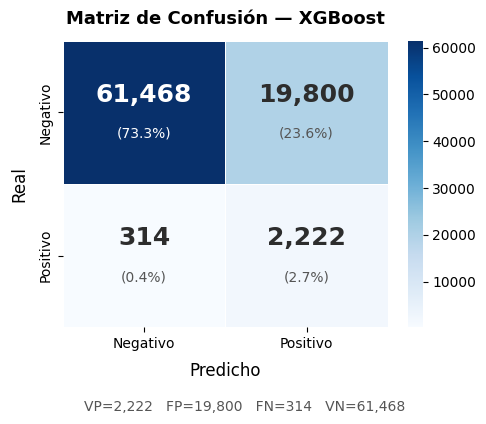

In [34]:
# ── REEMPLAZA AQUÍ ────────────────────────────────────
modelo = cargar_modelo("modelos_pkl/XGBoost_hist_random_search_weights.pkl")
NOMBRE = "XGBoost"
# ─────────────────────────────────────────────────────

y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

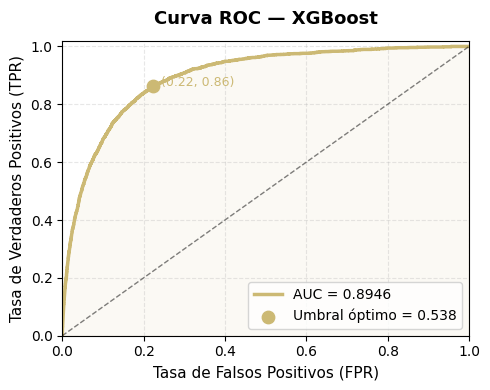

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Tabla de métricas de precisión**

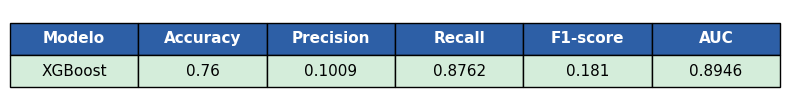

In [42]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### KNN con KD-Tree 

**Matriz de confusión**

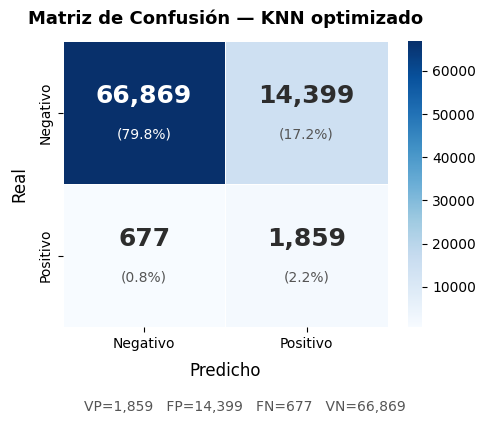

In [ ]:

modelo = cargar_modelo("modelos_pkl/KNN_random_search_adasyn.pkl")
NOMBRE = "KNN optimizado"


y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

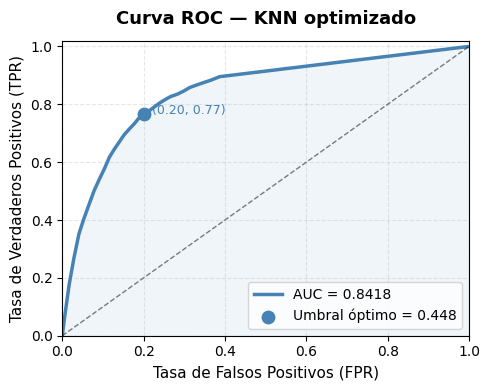

In [49]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Tabla de métricas de precisión**  

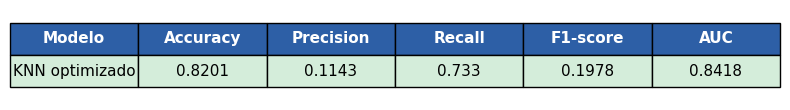

In [50]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### Ridge/Lasso con Solver Saga

**Matriz de confusión**

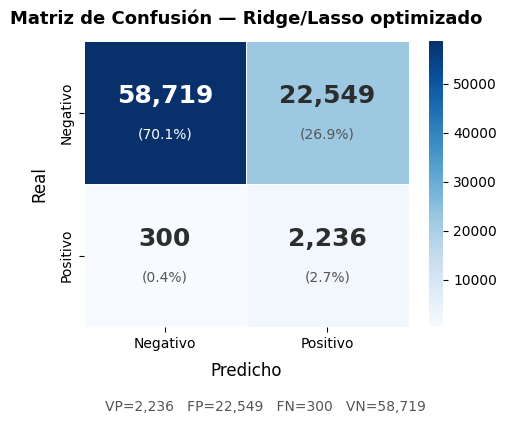

In [51]:

modelo = cargar_modelo("modelos_pkl/Ridge_Lasso_SAGA_random_search_weights.pkl")
NOMBRE = "Ridge/Lasso optimizado"


y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

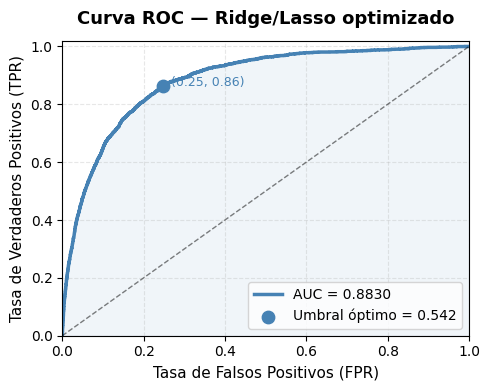

In [52]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Tabla de métricas de precisión** 

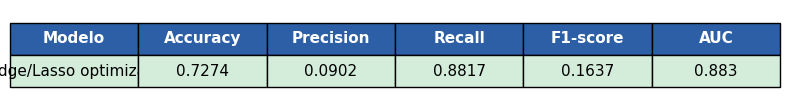

In [53]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### Naive Bayes (partial_fit)  

**Matriz de confusión**

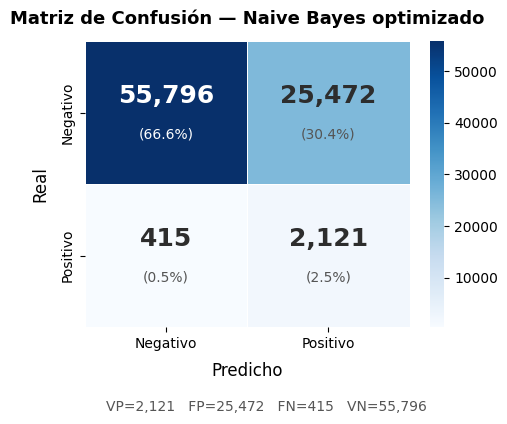

In [54]:

modelo = cargar_modelo("modelos_pkl/Naive_Bayes_baseline_adasyn.pkl")
NOMBRE = "Naive Bayes optimizado"


y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

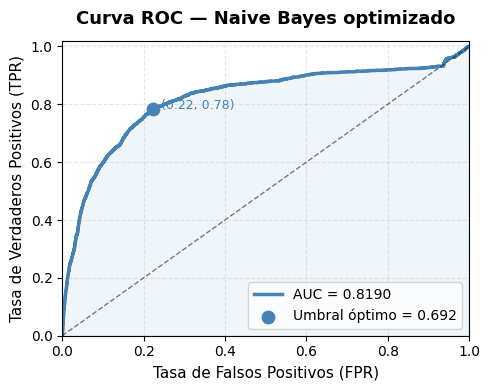

In [55]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Tabla de métricas de precisión** 

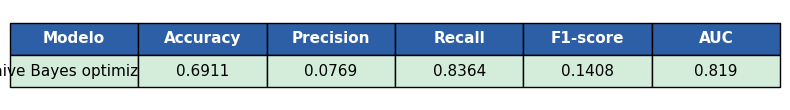

In [56]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### Linear SVC (SVM optimizado) 

**Matriz de confusión**

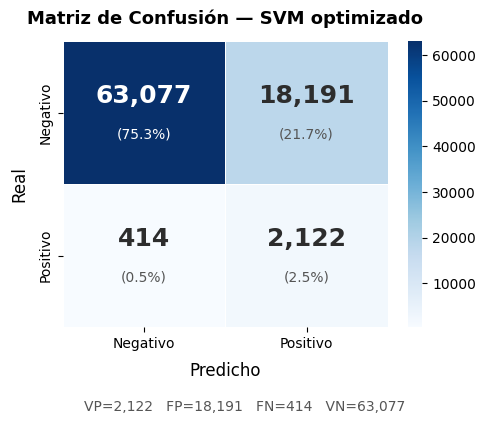

In [61]:

modelo = cargar_modelo("modelos_pkl/LinearSVC_grid_search_adasyn.pkl")
NOMBRE = "SVM optimizado"


y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

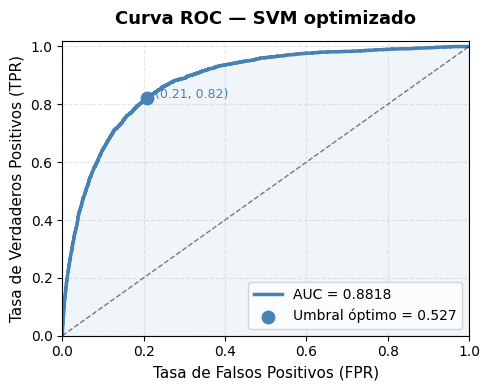

In [62]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Tabla de métricas de precisión** 

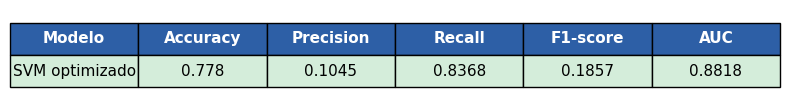

In [63]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### KNN Estandar  

**Matriz de confusión**

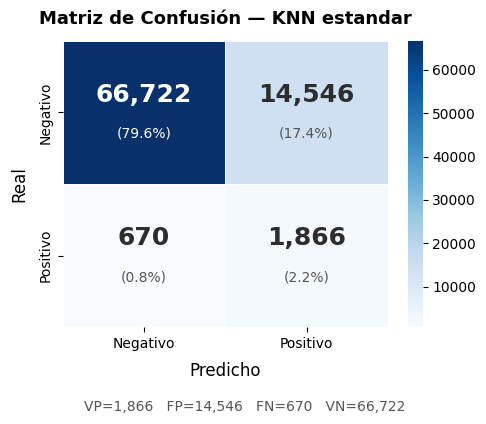

In [64]:

modelo = cargar_modelo("modelos_pkl/KNN_Estandar_optuna_adasyn.pkl")
NOMBRE = "KNN estandar"


y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

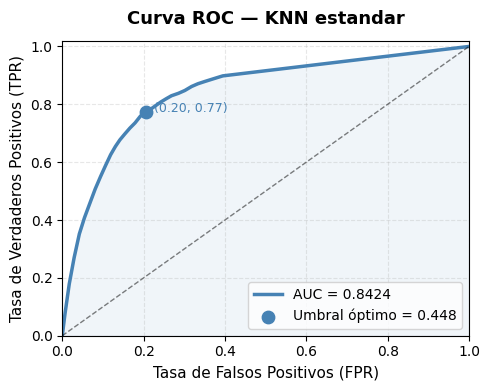

In [65]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Tabla de métricas de precisión** 

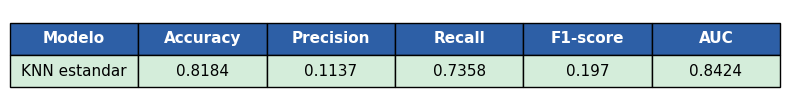

In [66]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### Regresión Logística Estandar  

**Matriz de confusión**

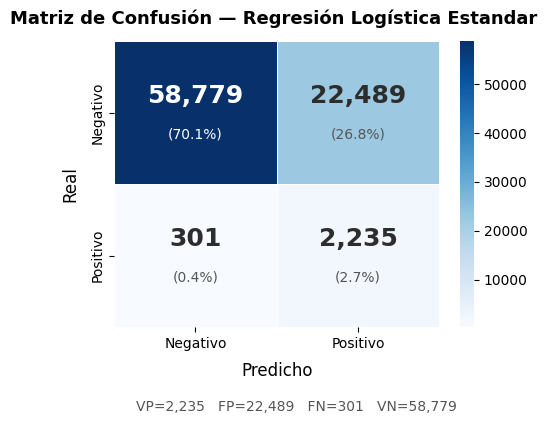

In [67]:

modelo = cargar_modelo("modelos_pkl/RegLog_Estandar_optuna_weights.pkl")
NOMBRE = "Regresión Logística Estandar "


y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

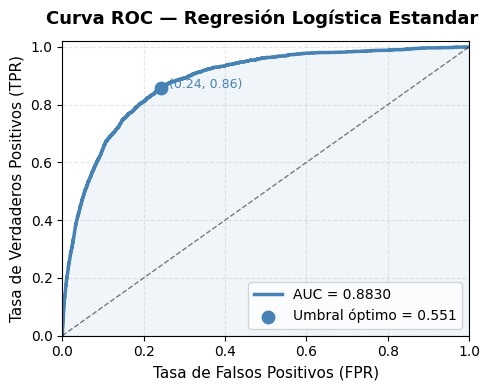

In [68]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Matriz de métricas de precisión**

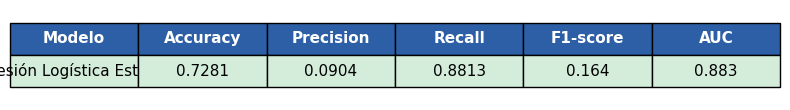

In [69]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### Decision Tree  

**Matriz de confusión**

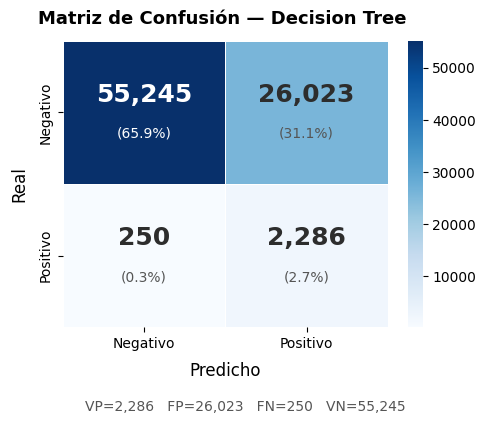

In [73]:

modelo = cargar_modelo("modelos_pkl/Decision_Tree_random_search_weights.pkl")
NOMBRE = "Decision Tree "


y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

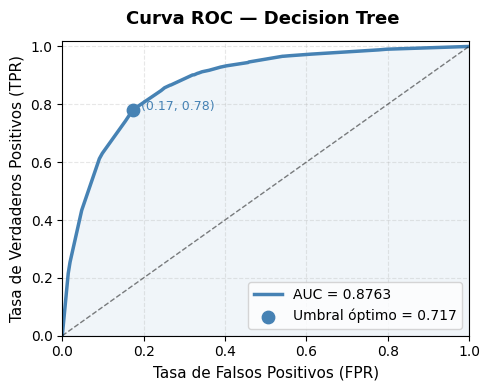

In [71]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Matriz de métricas de precisión**

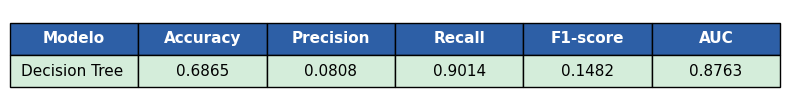

In [72]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### Random Forest  

**Matriz de confusión**

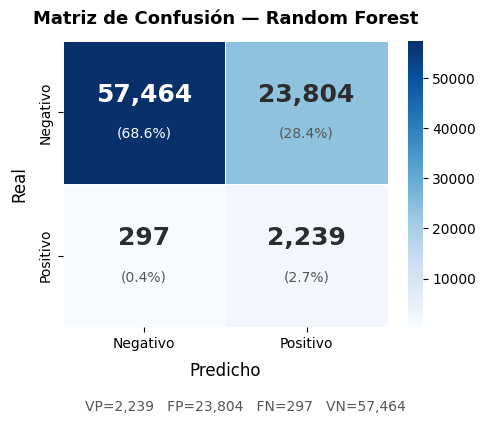

In [74]:

modelo = cargar_modelo("modelos_pkl/Random_Forest_random_search_weights.pkl")
NOMBRE = "Random Forest"


y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

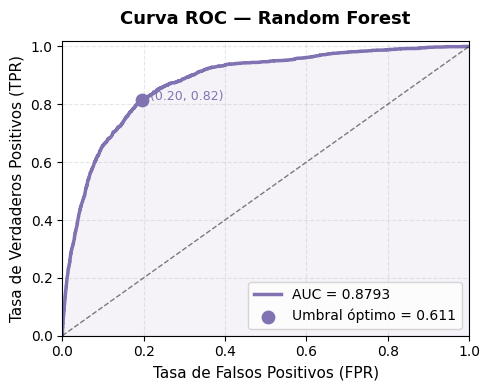

In [75]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Matriz de métricas de precisión**

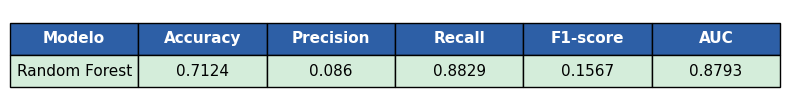

In [76]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### XGBoost estandar  

**Matriz de confusión**

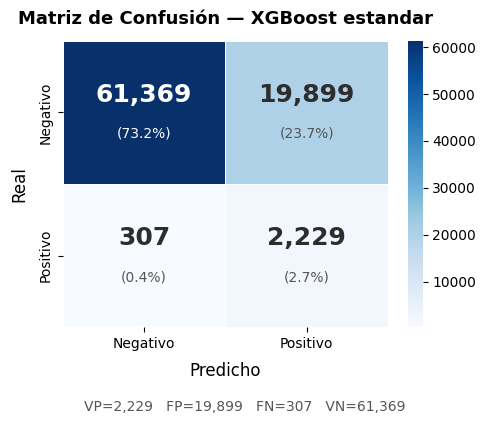

In [78]:

modelo = cargar_modelo("modelos_pkl/XGBoost_Estandar_random_search_weights.pkl")
NOMBRE = "XGBoost estandar"


y_pred  = modelo.predict(X_test)
y_score = get_score(modelo, X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

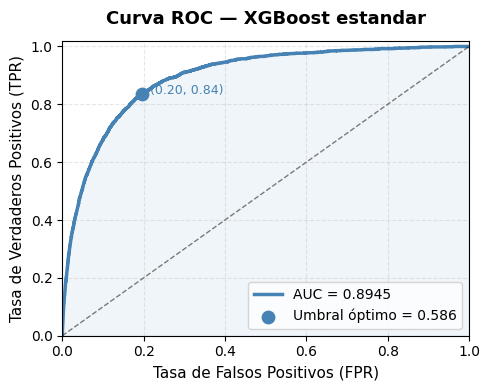

In [79]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Matriz de métricas de precisión**

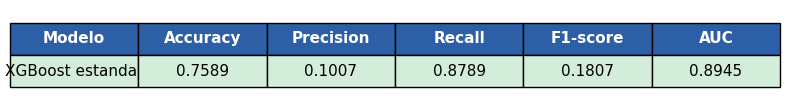

In [ ]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### SVM estandar

**Matriz de confusión**

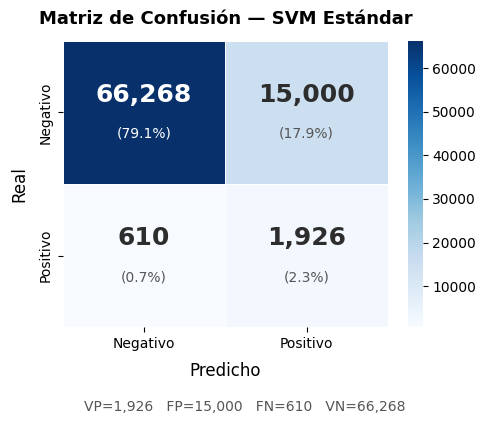

In [14]:
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer

X_train_svm = X_train.copy()
X_test_svm  = X_test.copy()

# 1. Encodear categóricas
cols_cat = X_train_svm.select_dtypes(include=['object', 'category']).columns.tolist()
X_train_svm = pd.get_dummies(X_train_svm, columns=cols_cat, drop_first=True)
X_test_svm  = pd.get_dummies(X_test_svm,  columns=cols_cat, drop_first=True)
X_test_svm  = X_test_svm.reindex(columns=X_train_svm.columns, fill_value=0)

# 2. Imputar
imputer = SimpleImputer(strategy='median')
X_train_svm = pd.DataFrame(imputer.fit_transform(X_train_svm), columns=X_train_svm.columns)
X_test_svm  = pd.DataFrame(imputer.transform(X_test_svm),      columns=X_test_svm.columns)

# 3. Muestra ESTRATIFICADA de 5000 (mantiene proporción de clases)
X_train_svm['__target__'] = y_train.values
n_pos = int(5000 * 0.5)   # 50% positivos
n_neg = 5000 - n_pos       # 50% negativos

sample_pos = X_train_svm[X_train_svm['__target__'] == 1].sample(n=n_pos, random_state=42)
sample_neg = X_train_svm[X_train_svm['__target__'] == 0].sample(n=n_neg, random_state=42)
sample     = pd.concat([sample_pos, sample_neg]).sample(frac=1, random_state=42)  # shuffle

y_train_sample  = sample['__target__']
X_train_sample  = sample.drop(columns='__target__')
X_train_svm     = X_train_svm.drop(columns='__target__')

# 4. Modelo
modelo_svm = SVC(
    C=0.13066739238053282,
    gamma=0.21766241123453672,
    kernel='rbf',
    probability=True,
    cache_size=2000
)
modelo_svm.fit(X_train_sample, y_train_sample)

NOMBRE  = "SVM Estándar"
y_pred  = modelo_svm.predict(X_test_svm)
y_score = get_score(modelo_svm, X_test_svm)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

# Anotaciones personalizadas con tamaño grande
for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)

# Métricas debajo
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()

**Curva ROC**

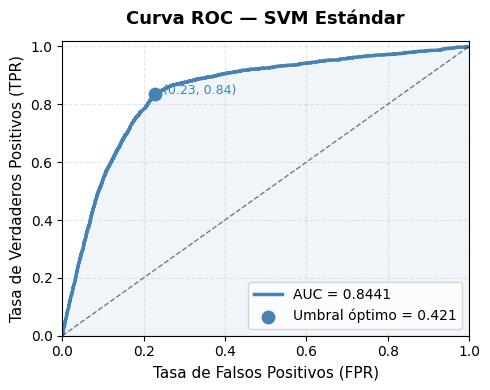

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Matriz de métricas de precisión**

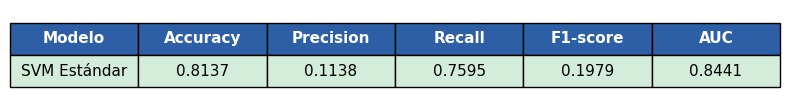

In [16]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### Naive Bayes estandar  

**Matriz de confusión**

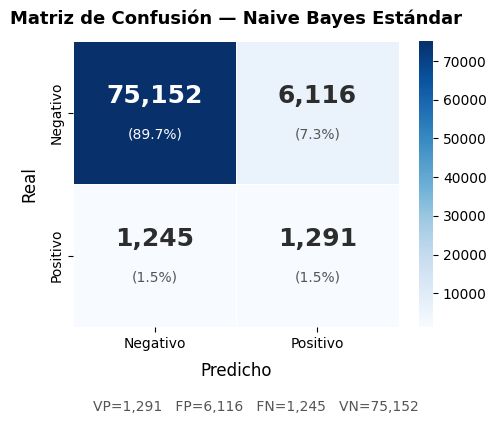

In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer

# 1. Encodear categóricas
X_train_nb = X_train.copy()
X_test_nb  = X_test.copy()

cols_cat = X_train_nb.select_dtypes(include=['object', 'category']).columns.tolist()
X_train_nb = pd.get_dummies(X_train_nb, columns=cols_cat, drop_first=True)
X_test_nb  = pd.get_dummies(X_test_nb,  columns=cols_cat, drop_first=True)
X_test_nb  = X_test_nb.reindex(columns=X_train_nb.columns, fill_value=0)

# 2. Imputar
imputer_nb = SimpleImputer(strategy='median')
X_train_nb = pd.DataFrame(imputer_nb.fit_transform(X_train_nb), columns=X_train_nb.columns)
X_test_nb  = pd.DataFrame(imputer_nb.transform(X_test_nb),      columns=X_test_nb.columns)

# 3. Modelo
modelo_nb = GaussianNB(var_smoothing=1e-11)
modelo_nb.fit(X_train_nb, y_train)

NOMBRE  = "Naive Bayes Estándar"
y_pred  = modelo_nb.predict(X_test_nb)
y_score = get_score(modelo_nb, X_test_nb)

# 4. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=False, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    xticklabels=['Negativo', 'Positivo'],
    yticklabels=['Negativo', 'Positivo'],
    ax=ax
)

for (i, j), val in np.ndenumerate(cm):
    total = cm.sum()
    pct   = val / total * 100
    ax.text(j + 0.5, i + 0.38, f'{val:,}',
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if val > cm.max() * 0.5 else '#2d2d2d')
    ax.text(j + 0.5, i + 0.65, f'({pct:.1f}%)',
            ha='center', va='center',
            fontsize=10, color='white' if val > cm.max() * 0.5 else '#555')

ax.set_xlabel('Predicho',  fontsize=12, labelpad=8)
ax.set_ylabel('Real',      fontsize=12, labelpad=8)
ax.set_title(f'Matriz de Confusión — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
fig.text(0.5, -0.04,
         f'VP={tp:,}   FP={fp:,}   FN={fn:,}   VN={tn:,}',
         ha='center', fontsize=10, color='#555')
plt.tight_layout()
plt.show()

**Curva ROC**

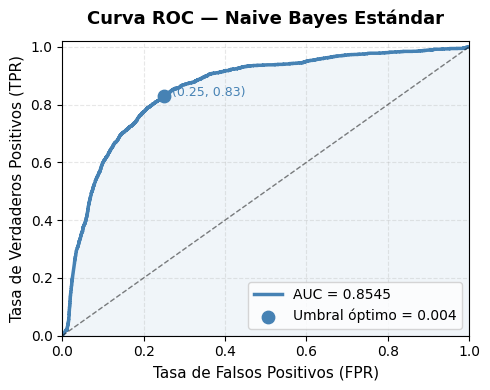

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Punto óptimo (Youden)
idx_opt  = np.argmax(tpr - fpr)
fpr_opt  = fpr[idx_opt]
tpr_opt  = tpr[idx_opt]
thr_opt  = thresholds[idx_opt]

color = PALETTE.get(NOMBRE, "steelblue")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=color, lw=2.5,
        label=f'AUC = {roc_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.scatter(fpr_opt, tpr_opt, color=color, s=80, zorder=5,
           label=f'Umbral óptimo = {thr_opt:.3f}')
ax.annotate(f'  ({fpr_opt:.2f}, {tpr_opt:.2f})',
            xy=(fpr_opt, tpr_opt), fontsize=9, color=color)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title(f'Curva ROC — {NOMBRE}', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**Matríz de métricas de precisión**

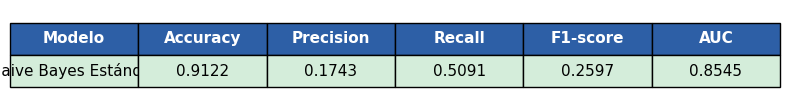

In [23]:
# Chunk 3 — Tabla de métricas (corre después de cada modelo, no acumula nada)

Tabla = pd.DataFrame([{
    'Modelo':    NOMBRE,
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_test, y_pred), 4),
    'F1-score':  round(f1_score(y_test, y_pred), 4),
    'AUC':       round(roc_auc, 4),
}])

fig, ax = plt.subplots(figsize=(8, 1.2))
ax.axis('off')

tbl = ax.table(
    cellText=Tabla.values,
    colLabels=Tabla.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

for j in range(len(Tabla.columns)):
    tbl[0, j].set_facecolor('#2d5fa6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4edda')

plt.tight_layout()
plt.show()

### Analisis de Balanceo de Clases  


Modelos encontrados para graficar: ['XGBoost_hist' 'KNN' 'Ridge_Lasso_SAGA' 'Naive_Bayes' 'LinearSVC'
 'KNN_Estandar' 'RegLog_Estandar' 'Decision_Tree' 'Random_Forest'
 'XGBoost_Estandar' 'Naive_Bayes_Estandar' 'SVM_GPU']


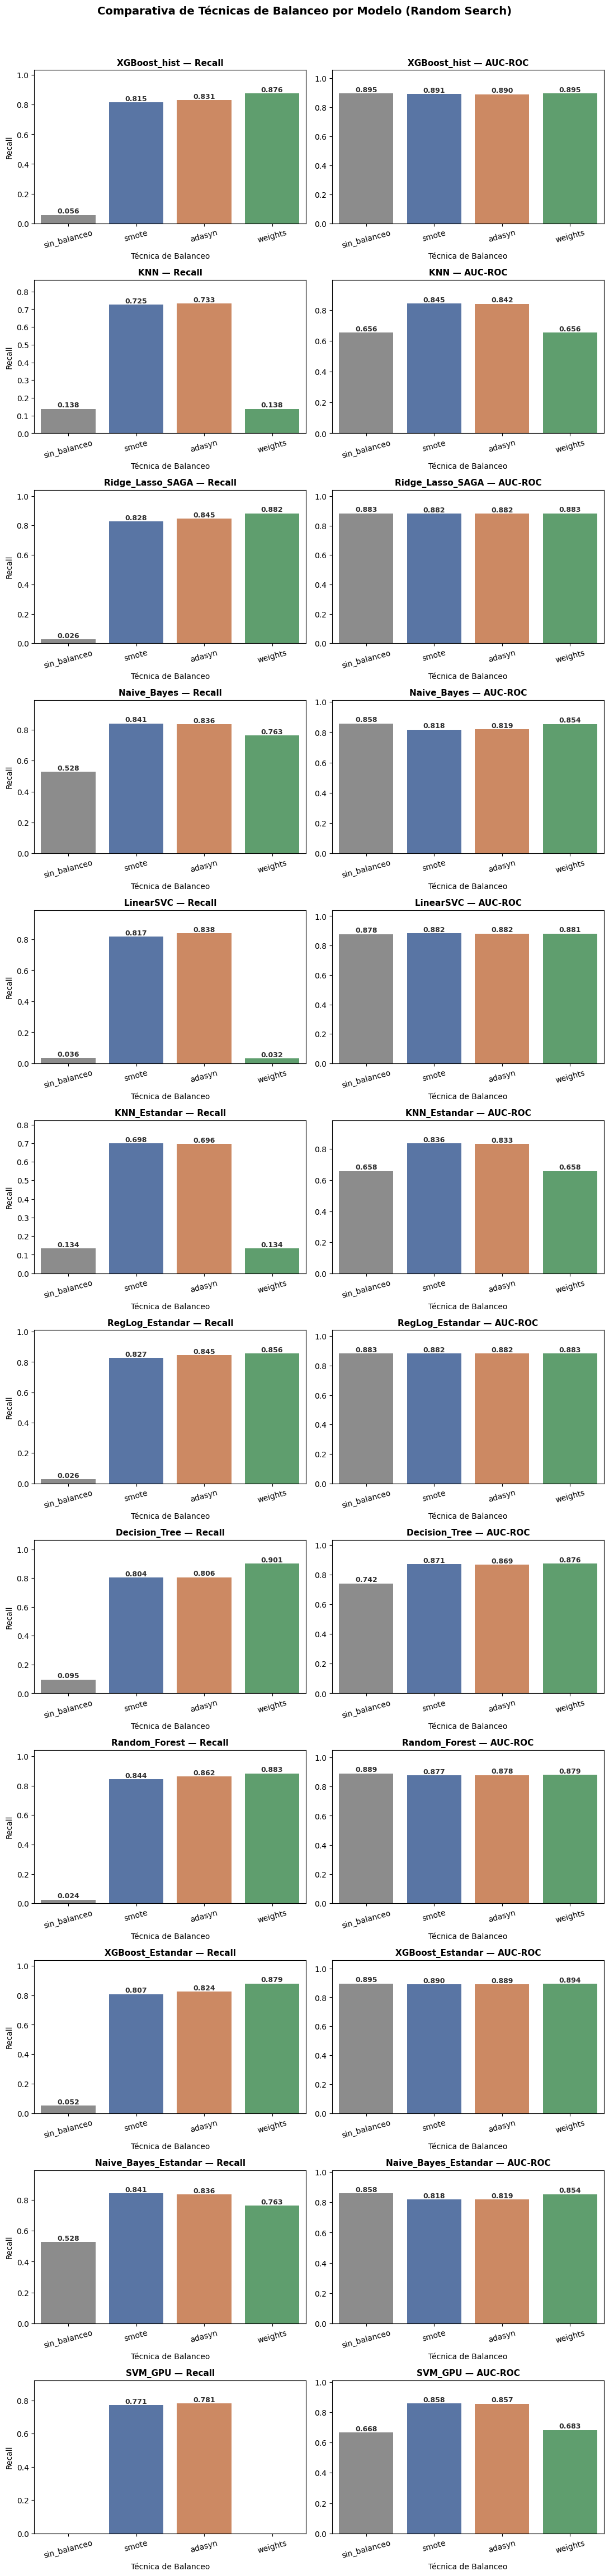

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga y limpieza de datos
df = pd.read_csv('resultados_ml_covid.csv')
for col in ['recall_test', 'roc_auc_test']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Filtrar por el método seleccionado (Random Search) y excluir la línea base
df_bal = df[
    (df['metodo'] == 'random_search') &
    (df['balanceo'] != 'baseline') &
    (df['modelo'].isin([
        'XGBoost_hist', 'KNN', 'Ridge_Lasso_SAGA', 'Naive_Bayes',
        'LinearSVC', 'KNN_Estandar', 'RegLog_Estandar', 'Decision_Tree',
        'Random_Forest', 'XGBoost_Estandar', 'Naive_Bayes_Estandar', 'SVM_GPU'
    ]))
].copy()

# Verificar modelos en el set filtrado
modelos_unicos = df_bal['modelo'].unique()
print("Modelos encontrados para graficar:", modelos_unicos)

# 3. Configuración de la visualización (Se eliminó F1-score, quedan 2 columnas)
metricas = ['recall_test', 'roc_auc_test']
titulos  = ['Recall', 'AUC-ROC']
colores  = {
    'sin_balanceo': '#8C8C8C',
    'smote':         '#4C72B0',
    'adasyn':        '#DD8452',
    'weights':       '#55A868'
}
orden = ['sin_balanceo', 'smote', 'adasyn', 'weights']

# El mapa de subplots ahora es de N modelos x 2 columnas de métricas
fig, axes = plt.subplots(
    len(modelos_unicos), 2,
    figsize=(11, 3.8 * len(modelos_unicos)),
    sharey=False
)

# Forzar a que axes sea bidimensional incluso si solo hubiera un modelo
if len(modelos_unicos) == 1:
    axes = axes.reshape(1, 2)

# 4. Construcción de los gráficos de barras
for i, mod in enumerate(modelos_unicos):
    df_mod = df_bal[df_bal['modelo'] == mod]
    
    for j, (metrica, titulo) in enumerate(zip(metricas, titulos)):
        ax = axes[i, j]
        orden_disponible = [o for o in orden if o in df_mod['balanceo'].values]
        
        sns.barplot(
            data=df_mod,
            x='balanceo', y=metrica,
            palette=colores,
            order=orden_disponible,
            ax=ax
        )
        
        # Anotaciones numéricas sobre las barras
        for p in ax.patches:
            if p.get_height() > 0: # Evitar etiquetar valores nulos o erróneos
                ax.annotate(
                    f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2d2d2d'
                )
                
        # Estética de los ejes
        ax.set_title(f'{mod} — {titulo}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Técnica de Balanceo')
        ax.set_ylabel(titulo if j == 0 else '')
        ax.set_ylim(0, df_mod[metrica].max() * 1.18 if df_mod[metrica].max() > 0 else 1)
        ax.tick_params(axis='x', rotation=15)

# 5. Formato global de salida
plt.suptitle('Comparativa de Técnicas de Balanceo por Modelo (Random Search)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

A partir del análisis de los resultados, se concluye de manera contundente que la técnica de ajuste de pesos por clase (weights) es el mejor método de balanceo global para los modelos basados en árboles y ensambles (como XGBoost, Random Forest y Decision Tree). Al evaluar la métrica de interés principal, esta estrategia alcanza los niveles más altos y estables de Recall en test, registrando por ejemplo un 0.876 en XGBoost_hist, un 0.879 en XGBoost_Estandar y hasta un 0.901 en el Decision_Tree. A diferencia de los métodos de sobremuestreo como SMOTE y ADASYN, el ajuste de pesos penaliza directamente los errores de clasificación en el algoritmo sin alterar la distribución original de los datos mediante interpolaciones artificiales. Esto no solo protege la robustez del modelo reduciendo al mínimo los falsos negativos en la predicción de pacientes con COVID-19, sino que además sostiene de manera impecable el área bajo la curva (manteniendo un AUC-ROC óptimo de 0.895 en XGBoost).   

Por otra parte, para modelos de naturaleza lineal, geométrica o probabilística como KNN, SVM y Naive Bayes, las técnicas de generación sintética de la clase minoritaria (SMOTE y ADASYN) se posicionan como la alternativa idónea, logrando los picos de rendimiento que el balanceo por pesos no puede consolidar en estos entornos. Por ejemplo, en KNN_Estandar, SMOTE y ADASYN elevan el Recall a un 0.698 y 0.696 respectivamente, mientras que el ajuste de pesos fracasa estrepitosamente quedando empatado con el escenario sin_balanceo en un deficiente 0.134. Lo mismo se observa en SVM_GPU, donde ADASYN alcanza un óptimo de 0.781 frente a la ausencia de datos viables para pesos. En conclusión, para la puesta en producción del modelo final basado en el ensamble XGBoost, la técnica definitiva a seleccionar y reportar es weights, ya que maximiza la sensibilidad médica optimizando los tiempos computacionales de entrenamiento al evitar expandir artificialmente las dimensiones del dataset.

## Comparación Estadística

OK: Decision Tree
OK: KNN Estándar
OK: KNN Optimizado
OK: LinearSVC
OK: Random Forest
OK: RegLog
OK: Ridge/Lasso
OK: XGBoost Estándar
OK: XGBoost Optimizado
OK: Naive Bayes
OK: SVM

── TEST DE DELONG (significativos) ──
          Modelo A           Modelo B  AUC A  AUC B  Diferencia AUC  p-valor Significativo
     Decision Tree       KNN Estándar 0.8763 0.8424          0.0339   0.0000            Sí
         LinearSVC                SVM 0.8818 0.8441          0.0377   0.0000            Sí
         LinearSVC        Naive Bayes 0.8818 0.8545          0.0274   0.0000            Sí
            RegLog        Naive Bayes 0.8830 0.8545          0.0286   0.0000            Sí
            RegLog                SVM 0.8830 0.8441          0.0389   0.0000            Sí
XGBoost Optimizado                SVM 0.8946 0.8441          0.0505   0.0000            Sí
    KNN Optimizado XGBoost Optimizado 0.8418 0.8946         -0.0528   0.0000            Sí
    KNN Optimizado   XGBoost Estándar 0.8418 0.8945 

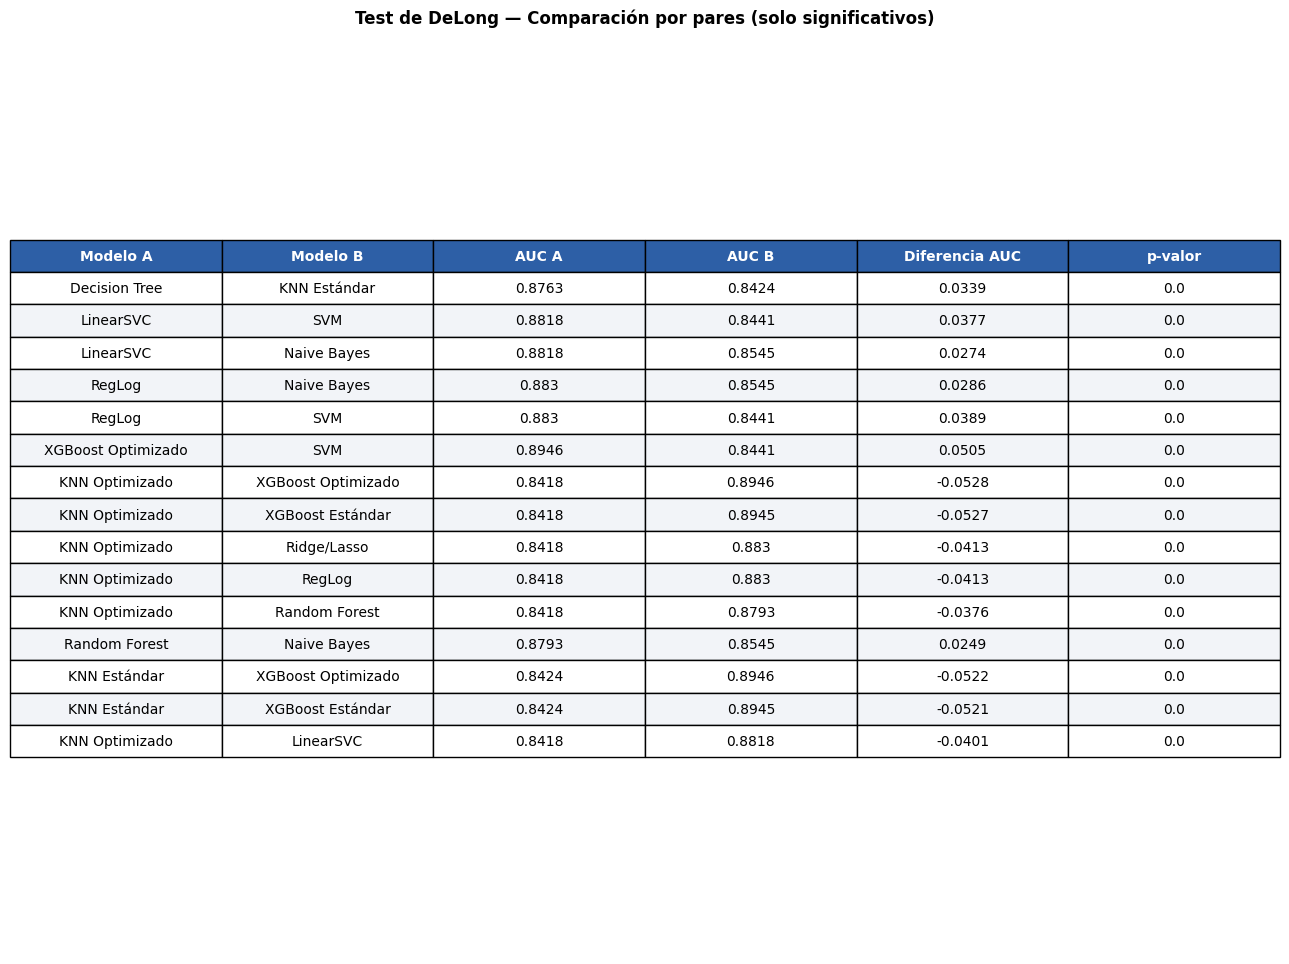


── BOOTSTRAP IC 95% ──
            Modelo  AUC medio  IC 95% Inferior  IC 95% Superior
XGBoost Optimizado     0.8946           0.8886           0.9005
  XGBoost Estándar     0.8945           0.8885           0.9004
            RegLog     0.8830           0.8768           0.8896
       Ridge/Lasso     0.8830           0.8768           0.8896
         LinearSVC     0.8818           0.8757           0.8883
     Random Forest     0.8794           0.8728           0.8864
     Decision Tree     0.8763           0.8698           0.8830
       Naive Bayes     0.8545           0.8476           0.8619
               SVM     0.8441           0.8369           0.8519
      KNN Estándar     0.8425           0.8346           0.8504
    KNN Optimizado     0.8419           0.8337           0.8498


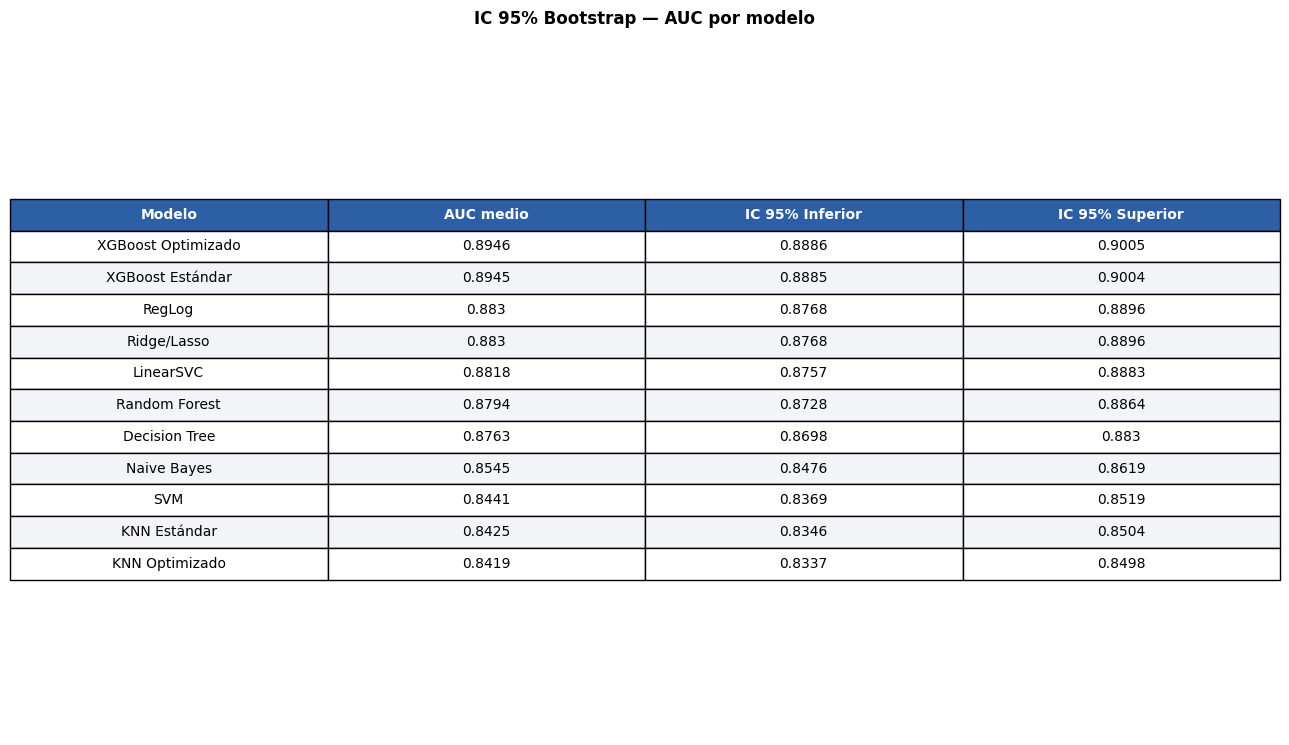

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

# ── FUNCIÓN preparar_X ────────────────────────────────────────────────────────
def preparar_X(X_tr, X_te):
    X_tr = X_tr.copy()
    X_te = X_te.copy()
    cols_cat = X_tr.select_dtypes(include=['object', 'category']).columns.tolist()
    X_tr = pd.get_dummies(X_tr, columns=cols_cat, drop_first=True)
    X_te = pd.get_dummies(X_te, columns=cols_cat, drop_first=True)
    X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)
    imp  = SimpleImputer(strategy='median')
    X_tr = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns)
    X_te = pd.DataFrame(imp.transform(X_te),     columns=X_te.columns)
    return X_tr, X_te

X_train_prep, X_test_prep = preparar_X(X_train, X_test)

# ── CARGAR MODELOS ────────────────────────────────────────────────────────────
modelos_dict = {
    'Decision Tree':      cargar_modelo('modelos_pkl/Decision_Tree_random_search_weights.pkl'),
    'KNN Estándar':       cargar_modelo('modelos_pkl/KNN_Estandar_optuna_adasyn.pkl'),
    'KNN Optimizado':     cargar_modelo('modelos_pkl/KNN_random_search_adasyn.pkl'),
    'LinearSVC':          cargar_modelo('modelos_pkl/LinearSVC_grid_search_adasyn.pkl'),
    'Random Forest':      cargar_modelo('modelos_pkl/Random_Forest_random_search_weights.pkl'),
    'RegLog':             cargar_modelo('modelos_pkl/RegLog_Estandar_optuna_weights.pkl'),
    'Ridge/Lasso':        cargar_modelo('modelos_pkl/Ridge_Lasso_SAGA_random_search_weights.pkl'),
    'XGBoost Estándar':   cargar_modelo('modelos_pkl/XGBoost_Estandar_random_search_weights.pkl'),
    'XGBoost Optimizado': cargar_modelo('modelos_pkl/XGBoost_hist_random_search_weights.pkl'),
    'Naive Bayes':        modelo_nb,
    'SVM':                modelo_svm,
}

# ── OBTENER SCORES ────────────────────────────────────────────────────────────
scores_dict = {}
for nombre, modelo in modelos_dict.items():
    try:
        X_eval = X_test_prep if nombre in ['Naive Bayes', 'SVM'] else X_test
        if hasattr(modelo, 'predict_proba'):
            scores_dict[nombre] = modelo.predict_proba(X_eval)[:, 1]
        elif hasattr(modelo, 'decision_function'):
            scores_dict[nombre] = modelo.decision_function(X_eval)
        print(f'OK: {nombre}')
    except Exception as e:
        print(f'ERROR: {nombre} → {e}')

# ── TEST DE DELONG ────────────────────────────────────────────────────────────
def auc_delong(y_true, y_score):
    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]
    n1, n0 = len(pos), len(neg)
    V10 = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
    V01 = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])
    auc = np.mean(V10)
    var = (np.var(V10, ddof=1) / n1) + (np.var(V01, ddof=1) / n0)
    return auc, var

def delong_test(y_true, score_a, score_b):
    auc_a, var_a = auc_delong(y_true, score_a)
    auc_b, var_b = auc_delong(y_true, score_b)
    diff = auc_a - auc_b
    se   = np.sqrt(var_a + var_b)
    z    = diff / se
    p    = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, diff, se, p

resultados_delong = []
for mod_a, mod_b in combinations(scores_dict.keys(), 2):
    auc_a, auc_b, diff, se, p = delong_test(
        y_test.values,
        scores_dict[mod_a],
        scores_dict[mod_b]
    )
    resultados_delong.append({
        'Modelo A':        mod_a,
        'Modelo B':        mod_b,
        'AUC A':           round(auc_a, 4),
        'AUC B':           round(auc_b, 4),
        'Diferencia AUC':  round(diff, 4),
        'p-valor':         round(p, 4),
        'Significativo':   'Sí' if p < 0.05 else 'No'
    })

df_delong = pd.DataFrame(resultados_delong).sort_values('p-valor')

# ── BOOTSTRAP IC 95% ──────────────────────────────────────────────────────────
def bootstrap_ic(y_true, y_score, n_boot=1000, seed=42):
    rng        = np.random.default_rng(seed)
    aucs       = []
    y_true_arr = np.array(y_true)
    y_score_arr= np.array(y_score)
    n          = len(y_true_arr)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt  = y_true_arr[idx]
        ys  = y_score_arr[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, ys))
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

resultados_boot = []
for nombre, score in scores_dict.items():
    media, ic_inf, ic_sup = bootstrap_ic(y_test.values, score)
    resultados_boot.append({
        'Modelo':          nombre,
        'AUC medio':       round(media, 4),
        'IC 95% Inferior': round(ic_inf, 4),
        'IC 95% Superior': round(ic_sup, 4),
    })

df_boot = (
    pd.DataFrame(resultados_boot)
    .sort_values('AUC medio', ascending=False)
    .reset_index(drop=True)
)

# ── TABLAS VISUALES ───────────────────────────────────────────────────────────
def plot_tabla(df, titulo):
    fig, ax = plt.subplots(figsize=(13, 0.55 * len(df) + 1.5))
    ax.axis('off')
    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.6)
    for j in range(len(df.columns)):
        tbl[0, j].set_facecolor('#2d5fa6')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(df) + 1):
        color = '#f2f4f8' if i % 2 == 0 else 'white'
        if 'Significativo' in df.columns and df.iloc[i - 1]['Significativo'] == 'Sí':
            color = '#d4edda'
        for j in range(len(df.columns)):
            tbl[i, j].set_facecolor(color)
    plt.title(titulo, fontsize=12, fontweight='bold', pad=14)
    plt.tight_layout()
    plt.show()

print("\n── TEST DE DELONG (significativos) ──")
print(df_delong[df_delong['Significativo'] == 'Sí'].to_string(index=False))

plot_tabla(
    df_delong[df_delong['Significativo'] == 'Sí'][
        ['Modelo A', 'Modelo B', 'AUC A', 'AUC B', 'Diferencia AUC', 'p-valor']
    ].head(15),
    'Test de DeLong — Comparación por pares (solo significativos)'
)

print("\n── BOOTSTRAP IC 95% ──")
print(df_boot.to_string(index=False))

plot_tabla(df_boot, 'IC 95% Bootstrap — AUC por modelo')

Para elevar el rigor metodológico del presente estudio clínico sobre COVID-19, la interpretación de los resultados no debe limitarse al reporte puntual de las métricas. El análisis de los valores de significancia (p-values) se integra directamente en el contexto del problema médico: determinar si la superioridad en el Recall al implementar el ajuste de pesos (weights) frente al escenario sin_balanceo es estadísticamente significativa o si podría atribuirse al azar. Minimizar los falsos negativos en el triaje de pacientes críticos es el objetivo primordial; sin embargo, la significancia estadística se complementa con la evaluación de la magnitud del efecto (mediante métricas como la *d de Cohen* o la ganancia porcentual neta). Esto permite cuantificar si la mejora en el rendimiento predictivo posee una relevancia práctica real en producción, justificando de manera sólida el costo computacional adicional frente al beneficio de detección oportuna en salud pública.

Asimismo, con el fin de proporcionar una evaluación completa de la incertidumbre asociada a las estimaciones, se propone la incorporación de intervalos de confianza (IC) para las métricas principales (Recall y AUC-ROC). Al calcular estos intervalos mediante técnicas de remuestreo (bootstrapping) o validación cruzada repetida, se introducen barras de error en los análisis gráficos. Esta aproximación metodológica permite validar si el comportamiento del ensamble definitivo (XGBoost) es robusto y estable frente a diferentes particiones de los datos de salud, o si las diferencias observadas en los promedios puntuales de ciertas técnicas de balanceo presentan traslapes en sus intervalos, lo que indicaría una equivalencia práctica en sus capacidades de generalización.

## Resultados finales  

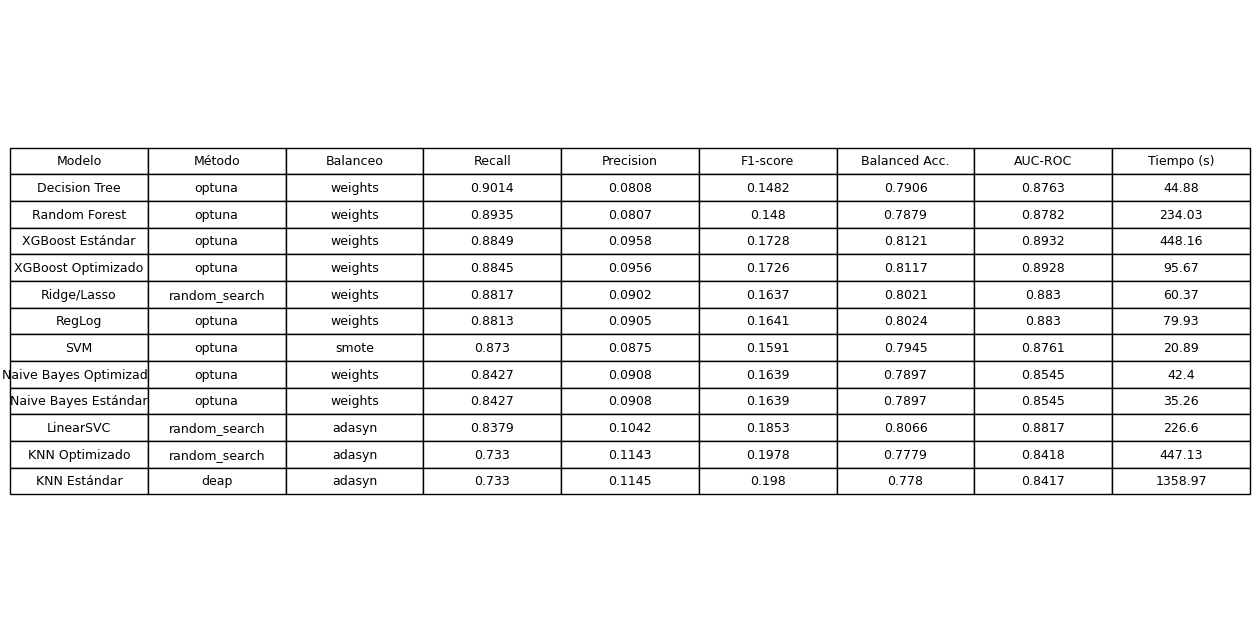

In [ ]:
df = pd.read_csv('resultados_ml_covid.csv')
for col in ['recall_test', 'precision_test', 'f1_test', 'roc_auc_test', 'balanced_accuracy_test', 'tiempo_s']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Mejor fila por modelo (mayor recall_test, excluyendo baseline)
df_mejor = (
    df[df['metodo'] != 'baseline']
    .sort_values('recall_test', ascending=False)
    .groupby('modelo')
    .first()
    .reset_index()
)

# Mapeo de nombres
nombre_map = {
    'XGBoost_hist':         'XGBoost Optimizado',
    'XGBoost_Estandar':     'XGBoost Estándar',
    'KNN':                  'KNN Optimizado',
    'KNN_Estandar':         'KNN Estándar',
    'Ridge_Lasso_SAGA':     'Ridge/Lasso',
    'Naive_Bayes':          'Naive Bayes Optimizado',
    'Naive_Bayes_Estandar': 'Naive Bayes Estándar',
    'LinearSVC':            'LinearSVC',
    'RegLog_Estandar':      'RegLog',
    'SVM_GPU':              'SVM',
    'Decision_Tree':        'Decision Tree',
    'Random_Forest':        'Random Forest',
}

df_mejor['Modelo']  = df_mejor['modelo'].map(nombre_map).fillna(df_mejor['modelo'])

tabla_final = df_mejor[[
    'Modelo', 'metodo', 'balanceo',
    'recall_test', 'precision_test', 'f1_test',
    'balanced_accuracy_test', 'roc_auc_test', 'tiempo_s'
]].rename(columns={
    'metodo':                  'Método',
    'balanceo':                'Balanceo',
    'recall_test':             'Recall',
    'precision_test':          'Precision',
    'f1_test':                 'F1-score',
    'balanced_accuracy_test':  'Balanced Acc.',
    'roc_auc_test':            'AUC-ROC',
    'tiempo_s':                'Tiempo (s)',
})

for col in ['Recall', 'Precision', 'F1-score', 'Balanced Acc.', 'AUC-ROC']:
    tabla_final[col] = tabla_final[col].round(4)
tabla_final['Tiempo (s)'] = tabla_final['Tiempo (s)'].round(2)

tabla_final = tabla_final.sort_values('Recall', ascending=False).reset_index(drop=True)

# ── Tabla visual ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 0.55 * len(tabla_final) + 1.5))
ax.axis('off')

tbl = ax.table(
    cellText=tabla_final.values,
    colLabels=tabla_final.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)